# Definitions

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, platform, os
os.environ['OMP_NUM_THREADS'] = '8'
import matplotlib
import math
from matplotlib import pyplot as plt
import numpy as np
import euclidemu2
import scipy
import cosmolike_lsst_y1_interface as ci
from getdist import IniFile
import itertools
import iminuit
import functools
from scipy.interpolate import interp1d
print(sys.version)
print(os.getcwd())

# GENERAL PLOT OPTIONS
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 'medium'
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.format'] = 'pdf'

# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# BE CAREFUL: you need texlive-latex-base texlive-latex-extra texlive-fonts-recommended dvipng ghostscript cm-super
matplotlib.rcParams['text.usetex'] = True
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------

# Jupyter Notebook Display options
import IPython
IPython.display.display(IPython.display.HTML("<style>:root { --jp-notebook-max-width: 85% !important; }</style>"))
IPython.display.display(IPython.display.HTML("<style>div.output_scroll { height: 54em; }</style>"))


Classy could not be found in your system.
Here are some suggestions:

	 -Download the Class from class-code.net and install it
	  together with its wrapper classy (type 'make' instead of
	  'make class'
	 -If you know that Class is installed on your system
	  and yet classy could not be installed, try re-compiling
	  Class with just ''make'' instead of ''make class''
NOTICE: Even without classy you can still use EuclidEmulator2
        to emulate boost factors. You won't be able to compute
        full power spectra, though.
3.11.12 | packaged by conda-forge | (main, Apr 10 2025, 22:18:52) [Clang 18.1.8 ]
/Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/projects/lsst_y1


In [2]:
# IMPORT CAMB
sys.path.insert(0, os.environ['ROOTDIR']+'/external_modules/code/CAMB/build/lib.linux-x86_64-'+os.environ['PYTHON_VERSION'])
import camb
from camb import model
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))

# IMPORT SHARED NOTEBOOK UTILITIES (cosmolike_core)
sys.path.insert(0, os.environ['ROOTDIR']+'/external_modules/code/cosmolike_core')
import cosmolike_notebook_utils as cnu
print('Using cosmolike_notebook_utils installed at %s'%(os.path.dirname(cnu.__file__)))


# IMPORT THE PROJECT'S NOTEBOOK WRAPPERS (projects/lsst_y1/interface):
# the probe, chi2, Fisher, and bfmt wrappers every notebook of this
# project shares
import cosmolike_lsst_y1_notebook_wrappers as nw
print('Using notebook wrappers installed at %s'%(nw.__file__))

Using CAMB 1.6.7 installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/.local/lib/python3.11/site-packages/camb
Using cosmolike_notebook_utils installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/external_modules/code/cosmolike_core/cosmolike_notebook_utils


In [3]:
CAMBAccuracyBoost = 1.0
non_linear_emul = 2
CLprobe="xi"

path= "../../external_modules/data/lsst_y1"
data_file="lsst_y1_M1_GGL0.05.dataset"

IA_model = 0
IA_redshift_evolution = 3
IA_code = 0  # 0 = C FASTPT, 1 = Python FAST-PT (NLA always uses 0)

ntheta = 26 
theta_min_arcmin = 2.5 
theta_max_arcmin = 900

# hand this notebook's yaml-mirroring values to the shared wrappers
nw.configure(ntheta=ntheta,
             theta_min_arcmin=theta_min_arcmin,
             theta_max_arcmin=theta_max_arcmin,
             non_linear_emul=non_linear_emul)

In [ ]:
# The project fiducial point lives in the wrappers module
# (interface/cosmolike_lsst_y1_notebook_wrappers.py), shared by
# every notebook. The names are imported so the sweep cells below can
# build shifted vectors from them; override any value per call
# instead, e.g. nw.get_chi2(omegam=0.31).
from cosmolike_lsst_y1_notebook_wrappers import (
    As_1e9, ns, H0, omegab, omegam, mnu, w, w0pwa,
    LSST_A1_1, LSST_A1_2,
    LSST_DZ_S1, LSST_DZ_S2, LSST_DZ_S3, LSST_DZ_S4, LSST_DZ_S5,
    LSST_M1, LSST_M2, LSST_M3, LSST_M4, LSST_M5,
    LSST_DZ_L1, LSST_DZ_L2, LSST_DZ_L3, LSST_DZ_L4, LSST_DZ_L5,
    LSST_B1_1, LSST_B1_2, LSST_B1_3, LSST_B1_4, LSST_B1_5,
    LSST_PM_1, LSST_PM_2, LSST_PM_3, LSST_PM_4, LSST_PM_5)

In [5]:
# get_camb_cosmology lives in cosmolike_core, shared by every project's
# notebooks; call it as cnu.get_camb_cosmology (imported above). The
# shared version scales the chi(z) node count with the CAMB boost
# (this notebook's copy fixed it at 1250, identical at boost 1);
# this notebook's kmax choice of 5.0 is passed explicitly at the
# call sites that relied on the old default.


In [ ]:
# C_ss_tomo_limber lives in this project's interface/
# (cosmolike_lsst_y1_notebook_wrappers, imported above as nw),
# shared by every notebook of this project; call as
# nw.C_ss_tomo_limber.

In [ ]:
# xi lives in this project's interface/
# (cosmolike_lsst_y1_notebook_wrappers, imported above as nw),
# shared by every notebook of this project; call as
# nw.xi.

In [8]:
# plot_C_ss_tomo_limber lives in cosmolike_core (shared); call it as
# cnu.plot_C_ss_tomo_limber (imported above). The shared version also fixes the
# bottom-row x-label test (j == ntomo-1 instead of a hard-coded row).


In [9]:
# plot_xi lives in cosmolike_core (shared); call it as
# cnu.plot_xi (imported above). The shared version also fixes the
# bottom-row x-label test (j == ntomo-1 instead of a hard-coded row).


In [ ]:
# Init Cosmolike (the full sequence lives in nw.init_cosmolike)
ini = nw.init_cosmolike()

# Let's plot how cosmological and nuisance parameters affect $C_{\ell}^{EE}$

In [18]:
lmin = 100.
lmax = 4500.
ell = np.arange(25., 4500., 20.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = np.arange(0.2, 0.4, 0.02)     
C_ss = []
for x in param:
    (Cl, tmp) = nw.C_ss_tomo_limber(ell=ell, omegam=x)
    C_ss.append(Cl)

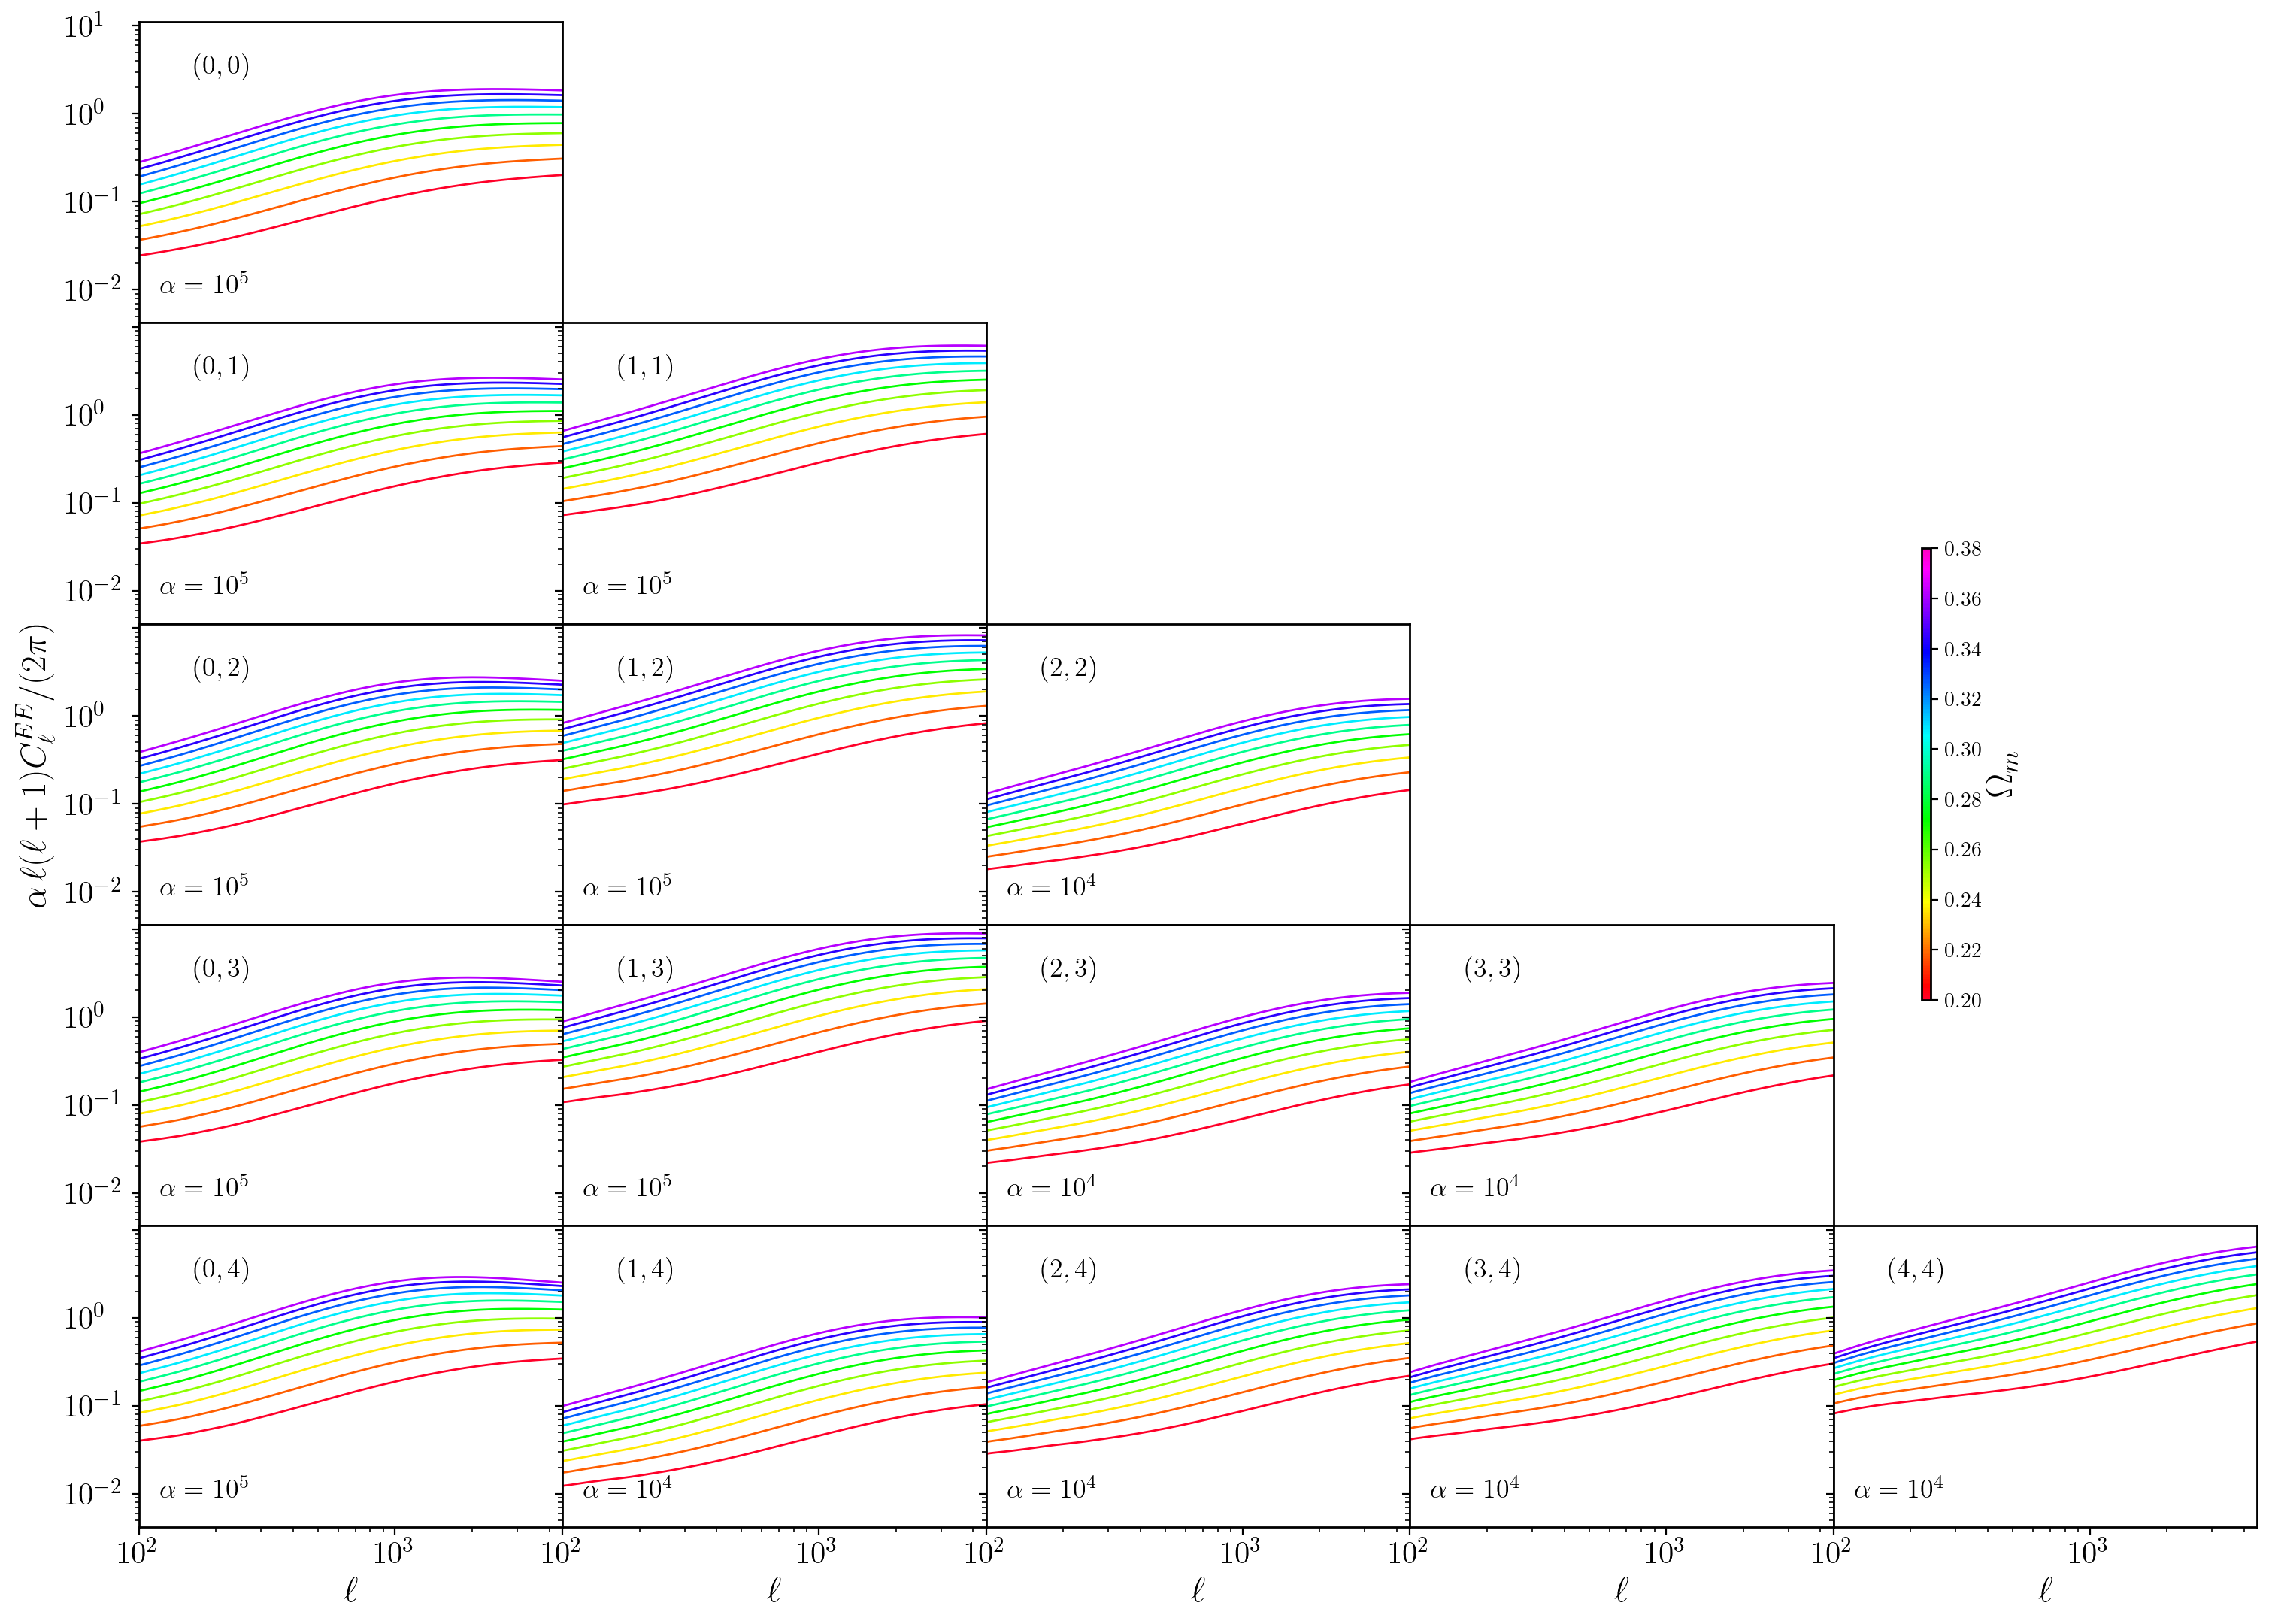

In [19]:
cnu.plot_C_ss_tomo_limber(ell=ell,
                          C_ss=C_ss,
                          param=param,
                          colorbarlabel="$\Omega_m$",
                          yaxislabelsize = 17,
                          xaxislabelsize = 17,
                          xaxisticklabelsize=15,
                          yaxisticklabelsize=15,
                          figsize = (18, 13),
                          lmin = lmin,
                          lmax = lmax,
                          wspace=0.4,
                          rescale=1,
                          ydecades=4)

In [20]:
lmin = 100.
lmax = 4500.
ell = np.arange(25., 4500., 20.) # Make sure arange are with float numbers (otherwise there are aliasing problems)
param = np.arange(0.85, 1.1, 0.02)
C_ss = []
for x in param:
    (Cl, tmp) = nw.C_ss_tomo_limber(ell=ell, ns=x)
    C_ss.append(Cl)

# Plot the Ratio over ref cosmology
(ref, tmp) = nw.C_ss_tomo_limber(ell=ell)

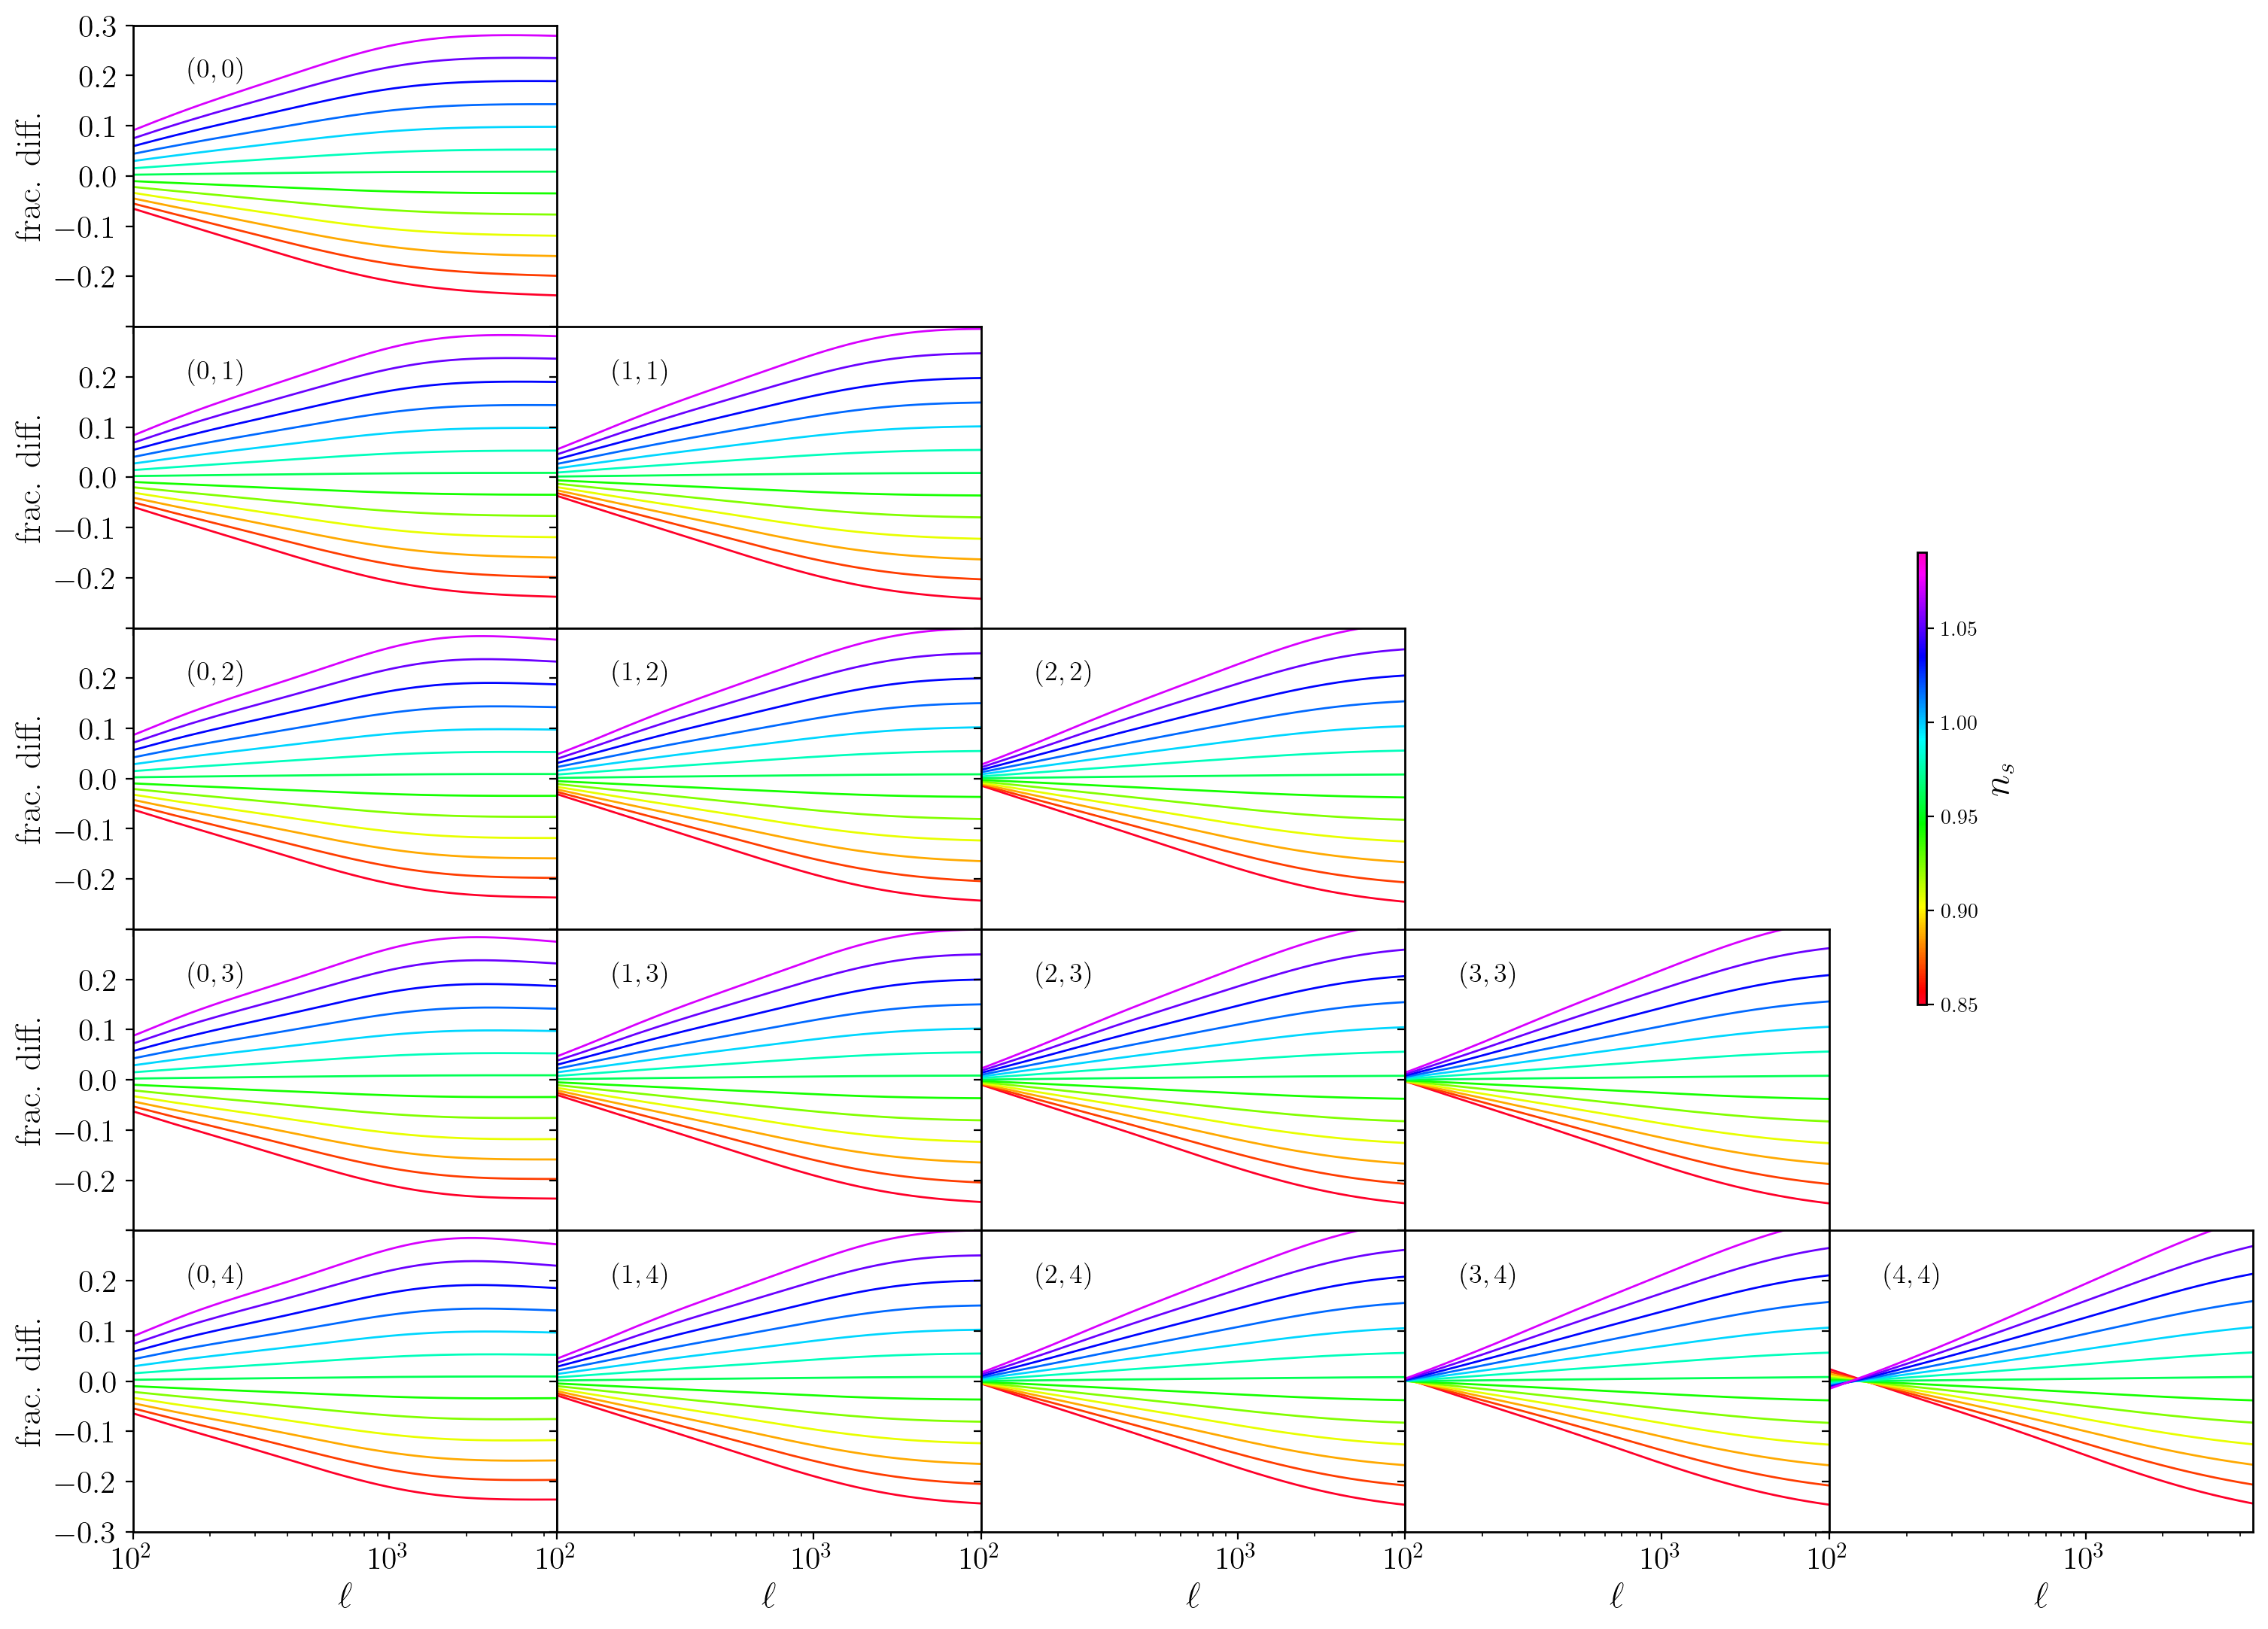

In [21]:
cnu.plot_C_ss_tomo_limber(ell=ell,
                          C_ss=C_ss,
                          C_ss_ref=ref,
                          param=param,
                          colorbarlabel="$n_s$",
                          figsize = (18, 13),
                          yaxislabelsize = 17,
                          xaxislabelsize = 17,
                          xaxisticklabelsize=15,
                          yaxisticklabelsize=15,
                          lmin = lmin,
                          lmax = lmax,
                          ylim = [0.7,1.3],
                          wspace=0.4)

# Let's plot how cosmological and nuisance parameters affect $\xi(\theta)$

In [22]:
param = np.arange(0.2, 0.4, 0.02)
        
xi_theta = []
for x in param:
    xi_theta.append(nw.xi(omegam = x))

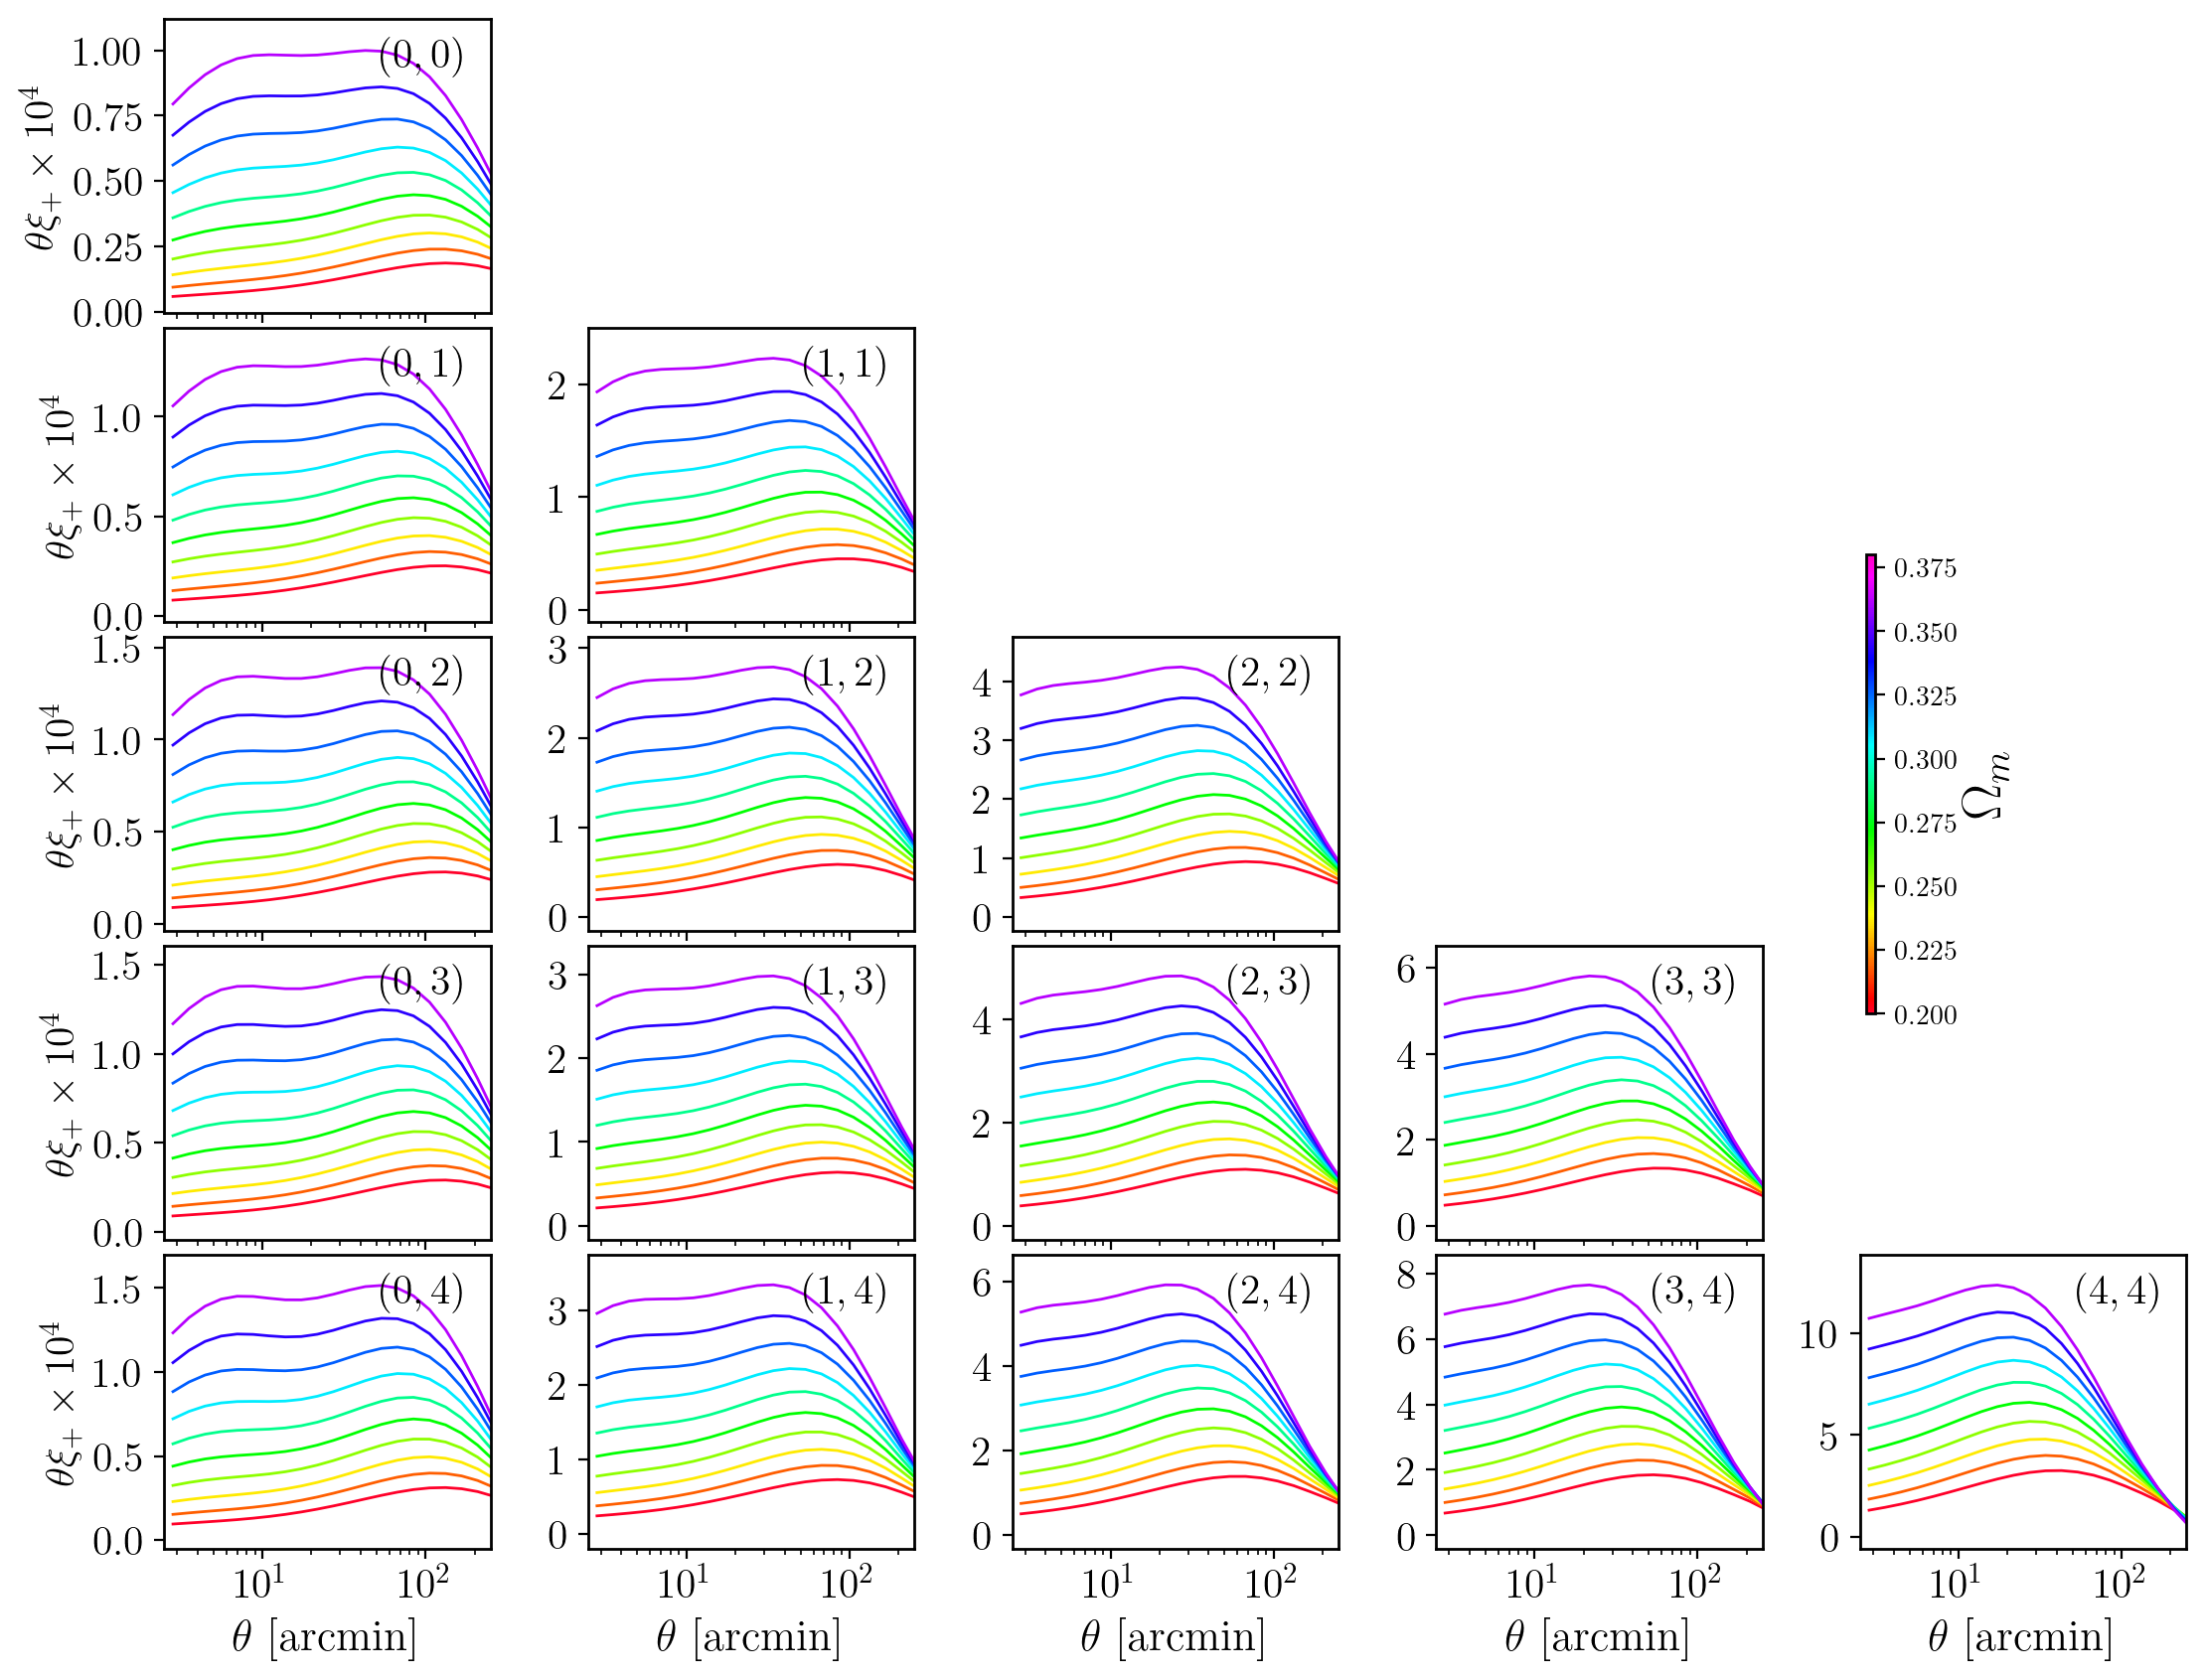

In [24]:
cnu.plot_xi(pm = 1,
            xi = xi_theta,
            param = param,
            colorbarlabel = "$\Omega_m$",
            yaxislabelsize = 15,
            xaxisticklabelsize=15,
            yaxisticklabelsize=15,
            figsize = (13, 10),
            thetashow=[2.5,250],
            wspace=0.3,
            rescale=None)

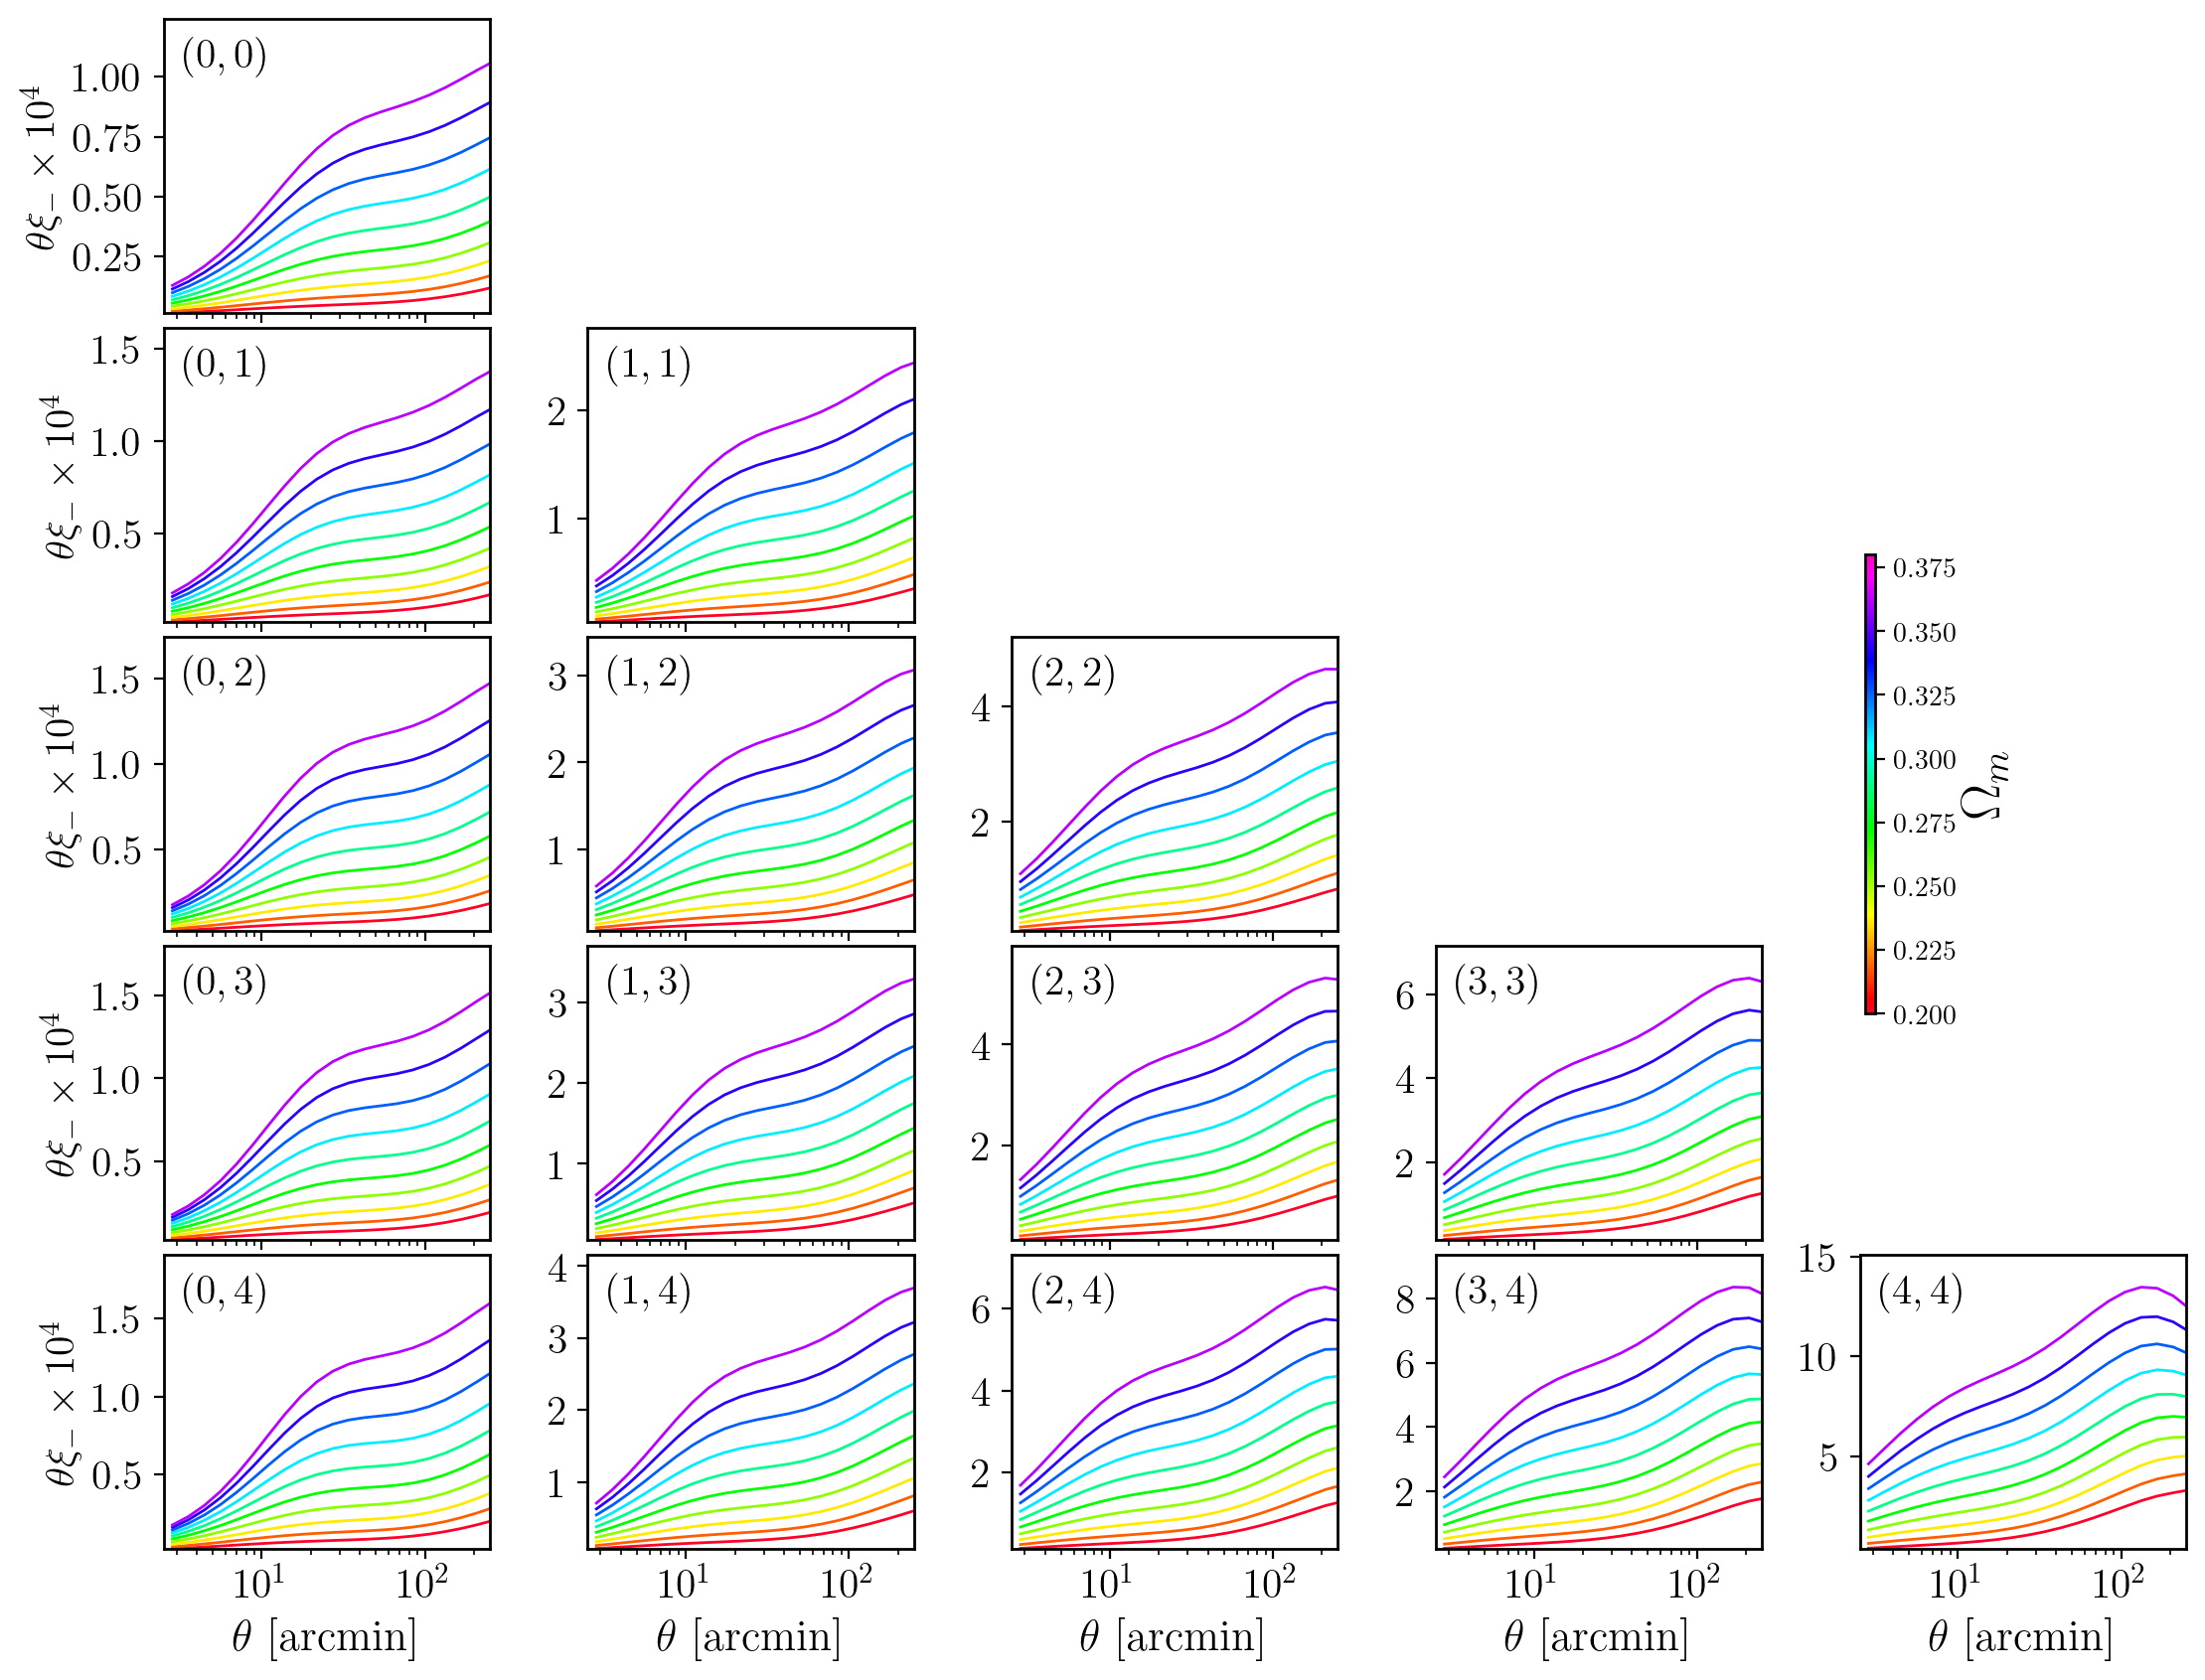

In [25]:
cnu.plot_xi(pm = -1,
            xi = xi_theta,
            param = param,
            colorbarlabel = "$\Omega_m$",
            yaxislabelsize = 15,
            xaxisticklabelsize=15,
            yaxisticklabelsize=15,
            figsize = (13, 10),
            thetashow=[2.5,250],
            wspace=0.3,
            rescale=None)

# Can we change the binning on $\xi(\theta)$ w/o restarting the kernel? Yes!
Why this is a nontrivial question? Because Cosmolike uses static variables to cache Glplus and Glminus

In [26]:
nthetas=[9, 12, 17, 44]

result = []
for x in nthetas:
    result.append(nw.xi(ntheta=x))

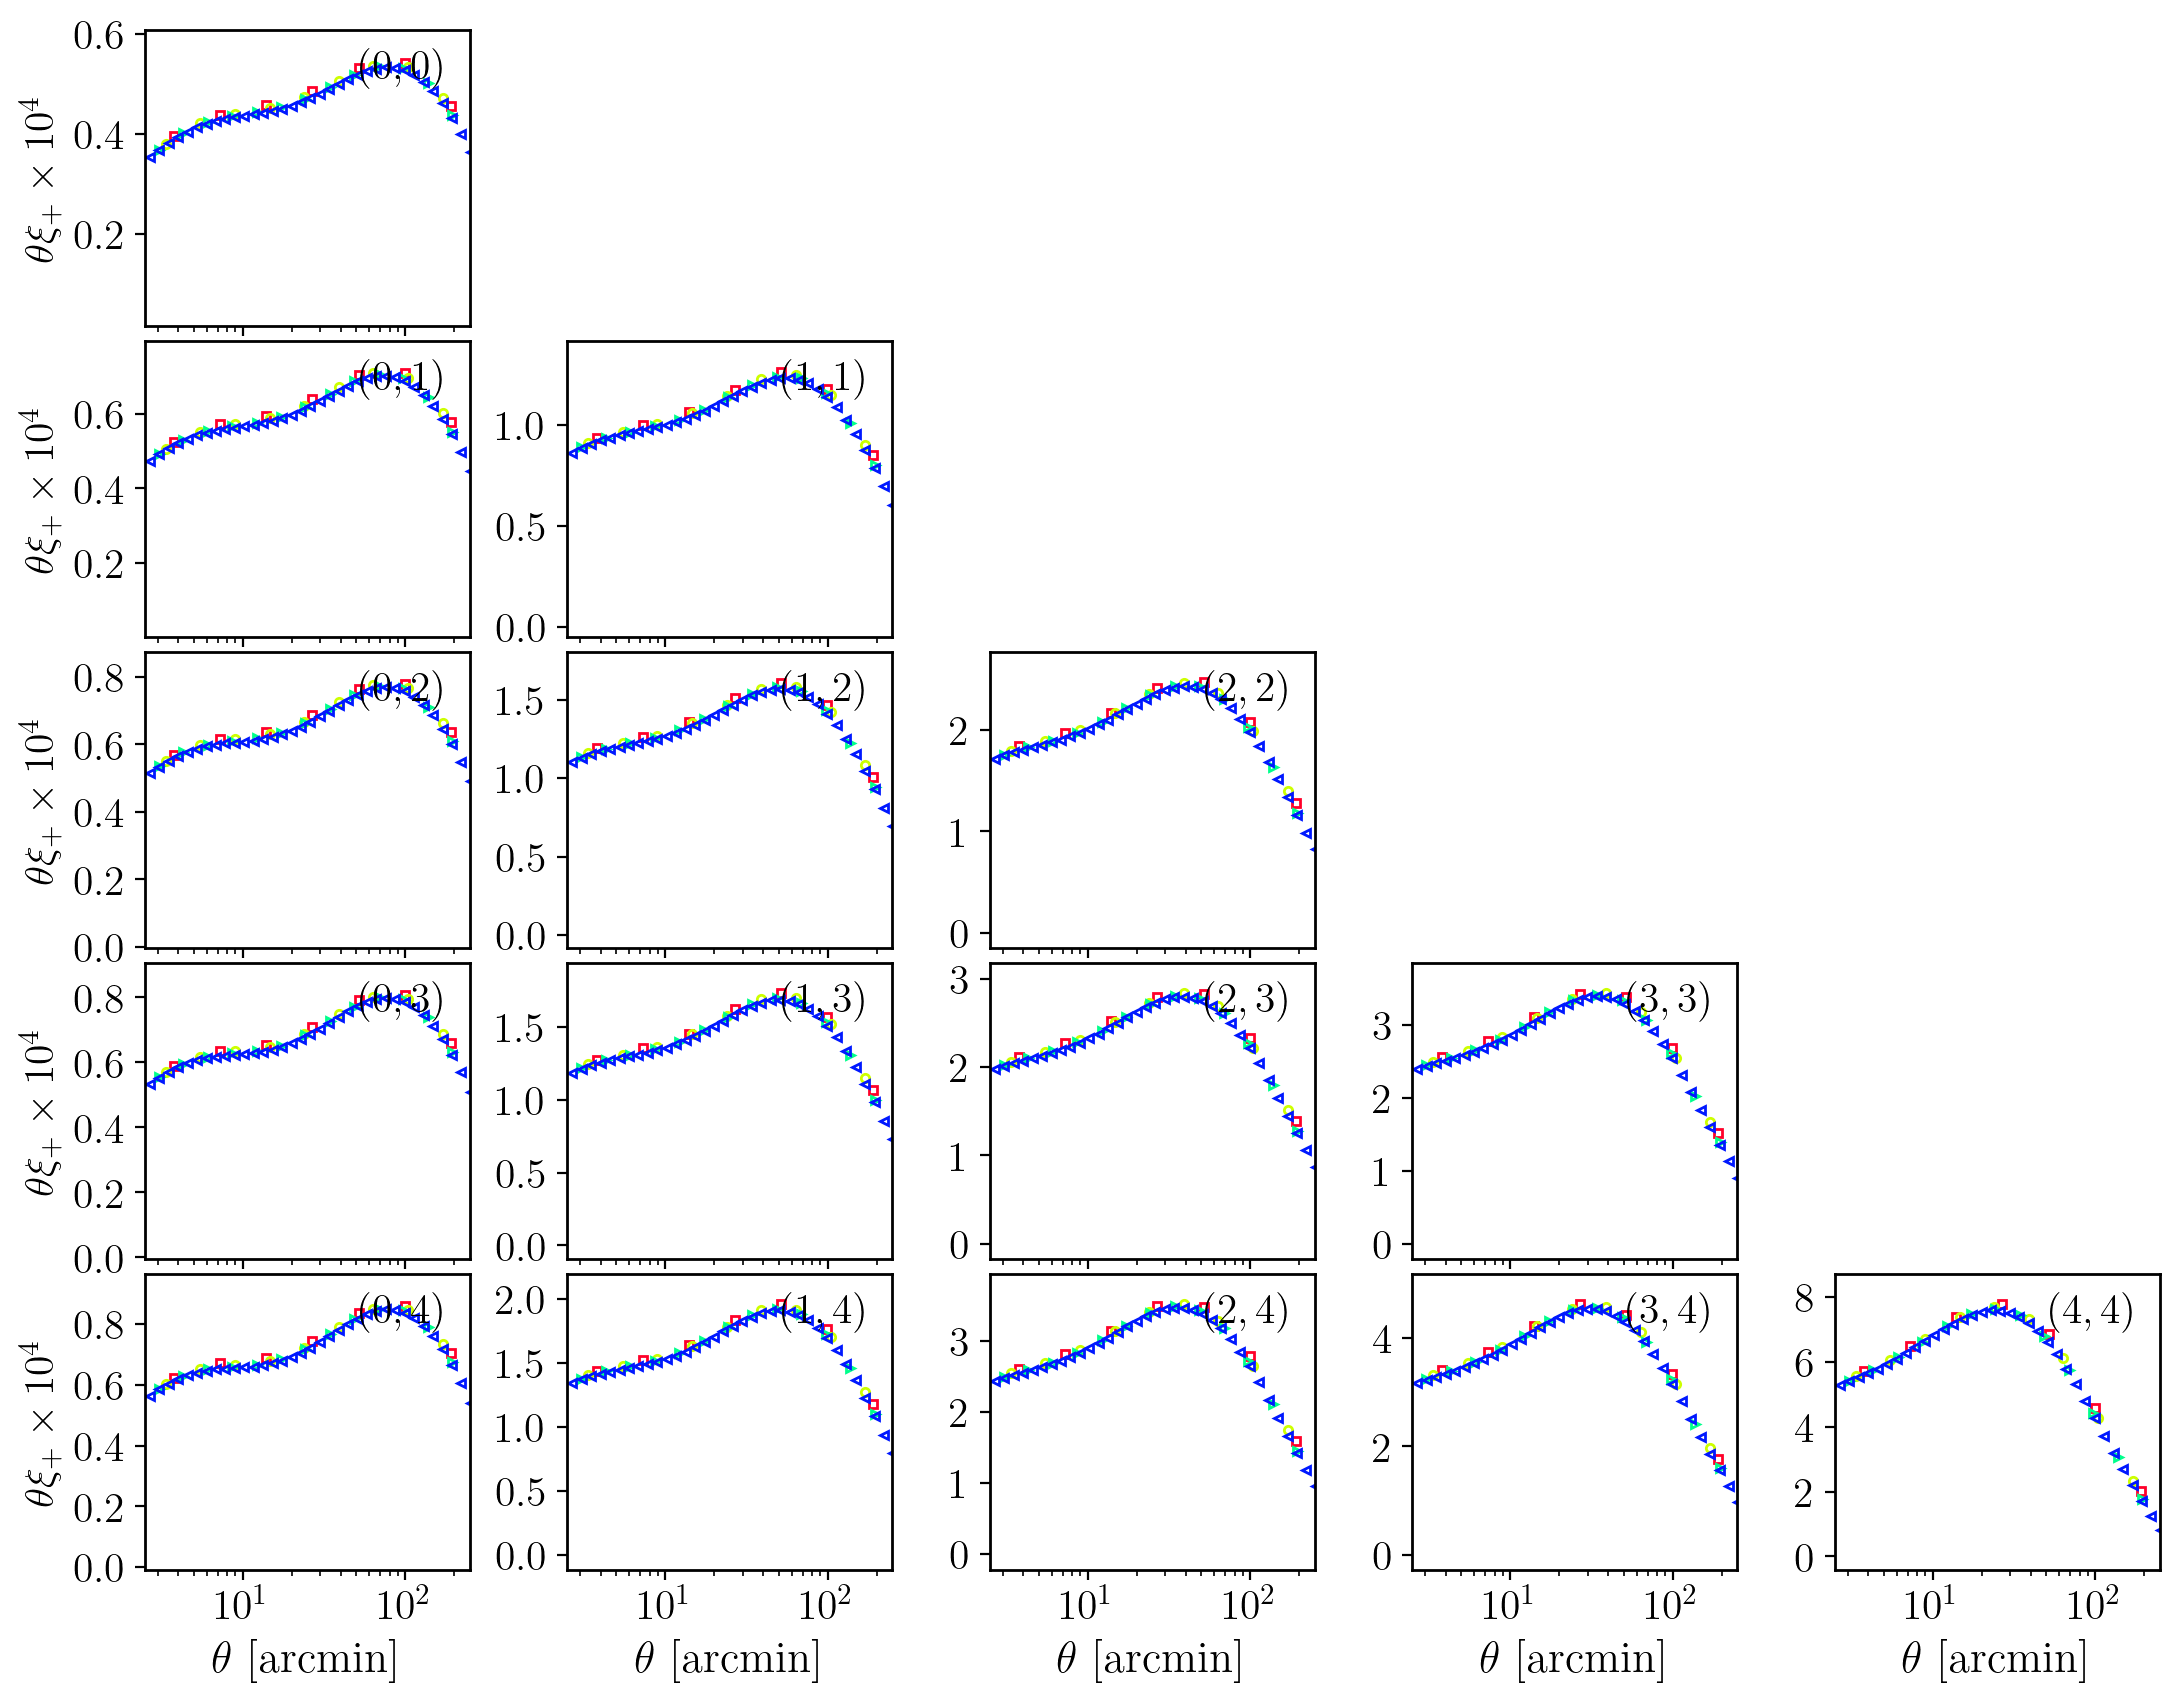

In [27]:
cnu.plot_xi(pm = 1,
            xi = result,
            marker=['s', 'o', ">", "<"],
            yaxislabelsize = 15,
            xaxisticklabelsize=15,
            yaxisticklabelsize=15,
            figsize = (13, 10),
            thetashow=[2.5,250],
            wspace=0.3,
            rescale=None)

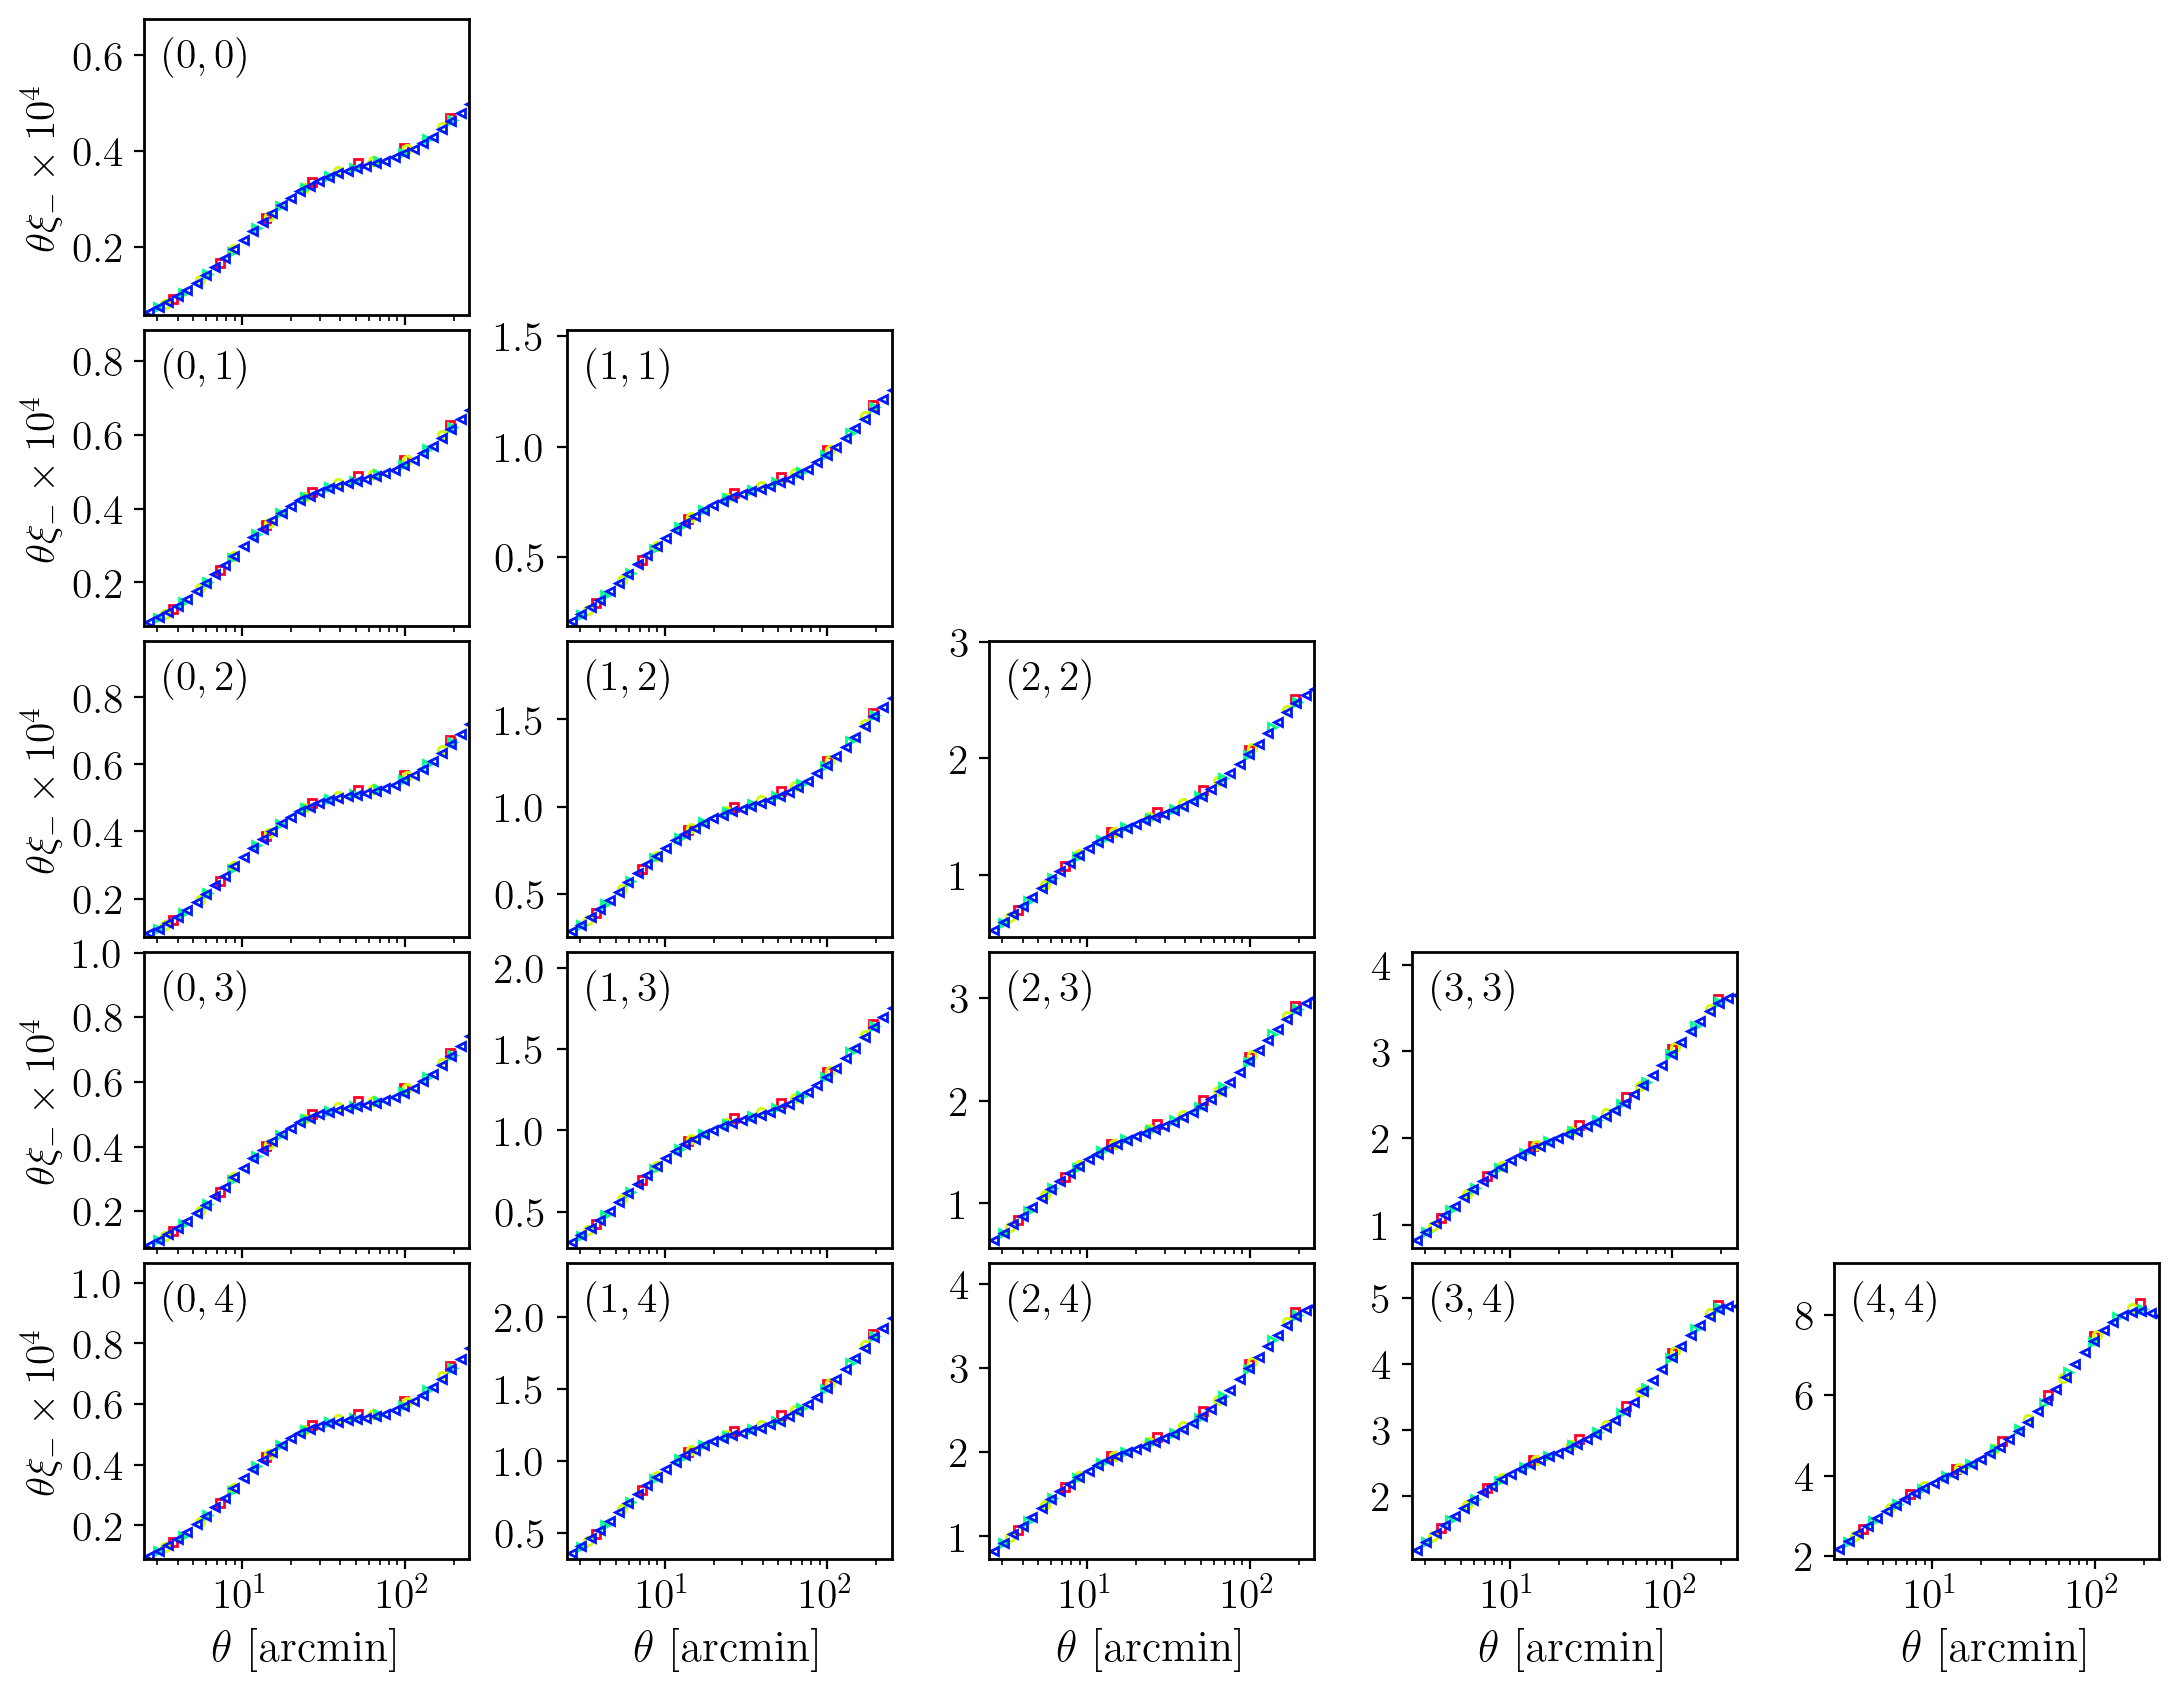

In [28]:
cnu.plot_xi(pm = -1,
            xi = result,
            marker=['s', 'o', ">", "<"],
            yaxislabelsize = 15,
            xaxisticklabelsize=15,
            yaxisticklabelsize=15,
            figsize = (13, 10),
            thetashow=[2.5,250],
            wspace=0.3,
            rescale=None)

# Add Baryon Contamination to $C_\ell^{\rm EE}$ and $\xi(\theta)$ data vectors

In [ ]:
ell = np.arange(3., 7500., 10.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = ("TNG100-1", "HzAGN-1", "mb2-1", "illustris-1", "eagle-1", "owls_AGN-1", "owls_AGN-2", "owls_AGN-3", "BAHAMAS-2")
        
C_ss = []
for x in param:
    (Cl, tmp) = nw.C_ss_tomo_limber(ell=ell, baryon_sims=x)
    C_ss.append(Cl)
    
# Plot the Ratio over ref cosmology
(C_ss_ref, tmp) = nw.C_ss_tomo_limber(ell=ell)

xi_theta = []
for x in param:
    xi_theta.append(nw.xi(baryon_sims=x, ntheta=40, AccuracyBoost=1.0))

xi_theta_ref = nw.xi(ntheta=40, AccuracyBoost=1.0)

In [ ]:
cnu.plot_C_ss_tomo_limber(ell=ell,
                          C_ss=C_ss,
                          C_ss_ref=C_ss_ref,
                          lmin=10,
                          lmax=5000,
                          cmap="twilight_shifted",
                          ylim=(0.6,1.3))

In [ ]:
matplotlib.rcParams['legend.fontsize'] = 17
 
cnu.plot_xi(pm = 1,
            param=None,
            xi=xi_theta,
            xi_ref=xi_theta_ref,
            cmap="twilight_shifted",
            ylim=(0.81,1.09),
            linewidth=[1.0, 1.3, 1.6, 1.9],
            linestyle = ['solid', 'dashed', 'dashdot', 'dotted'],
            legend = param,
            legendloc=(0.7,0.55),
            bintextpos = [[0.2, 0.875],[0.2,0.875]])

In [ ]:
cnu.plot_xi(pm = -1,
            param=None,
            xi=xi_theta,
            xi_ref=xi_theta_ref,
            cmap="twilight_shifted",
            ylim=(0.81,1.09),
            linewidth=[1.0, 1.3, 1.6, 1.9],
            linestyle = ['solid', 'dashed', 'dashdot', 'dotted'],
            legend = param,
            legendloc=(0.7,0.55),
            bintextpos = [[0.2, 0.875],[0.2,0.875]])

hum - need to investigate this peak on large scale

# Check how CAMB and Cosmolike Accuracy Boost affect $C_\ell^{\rm EE}$ and $\xi(\theta)$ data vectors (and $\chi^2)$

In [29]:
ell = np.arange(10., 8500., 30.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = np.arange(0.5, 6.0, 0.5)
C_ss = []
for x in param:
    # Change only Cosmolike Settings
    (Cl, tmp) = nw.C_ss_tomo_limber(ell=ell, AccuracyBoost=1,CAMBAccuracyBoost=1.,CLAccuracyBoost=1+x,CLIntegrationAccuracy=int(x))
    C_ss.append(Cl)
# Plot the Ratio over ref cosmology
(C_ss_ref, tmp) = nw.C_ss_tomo_limber(ell=ell,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=0)

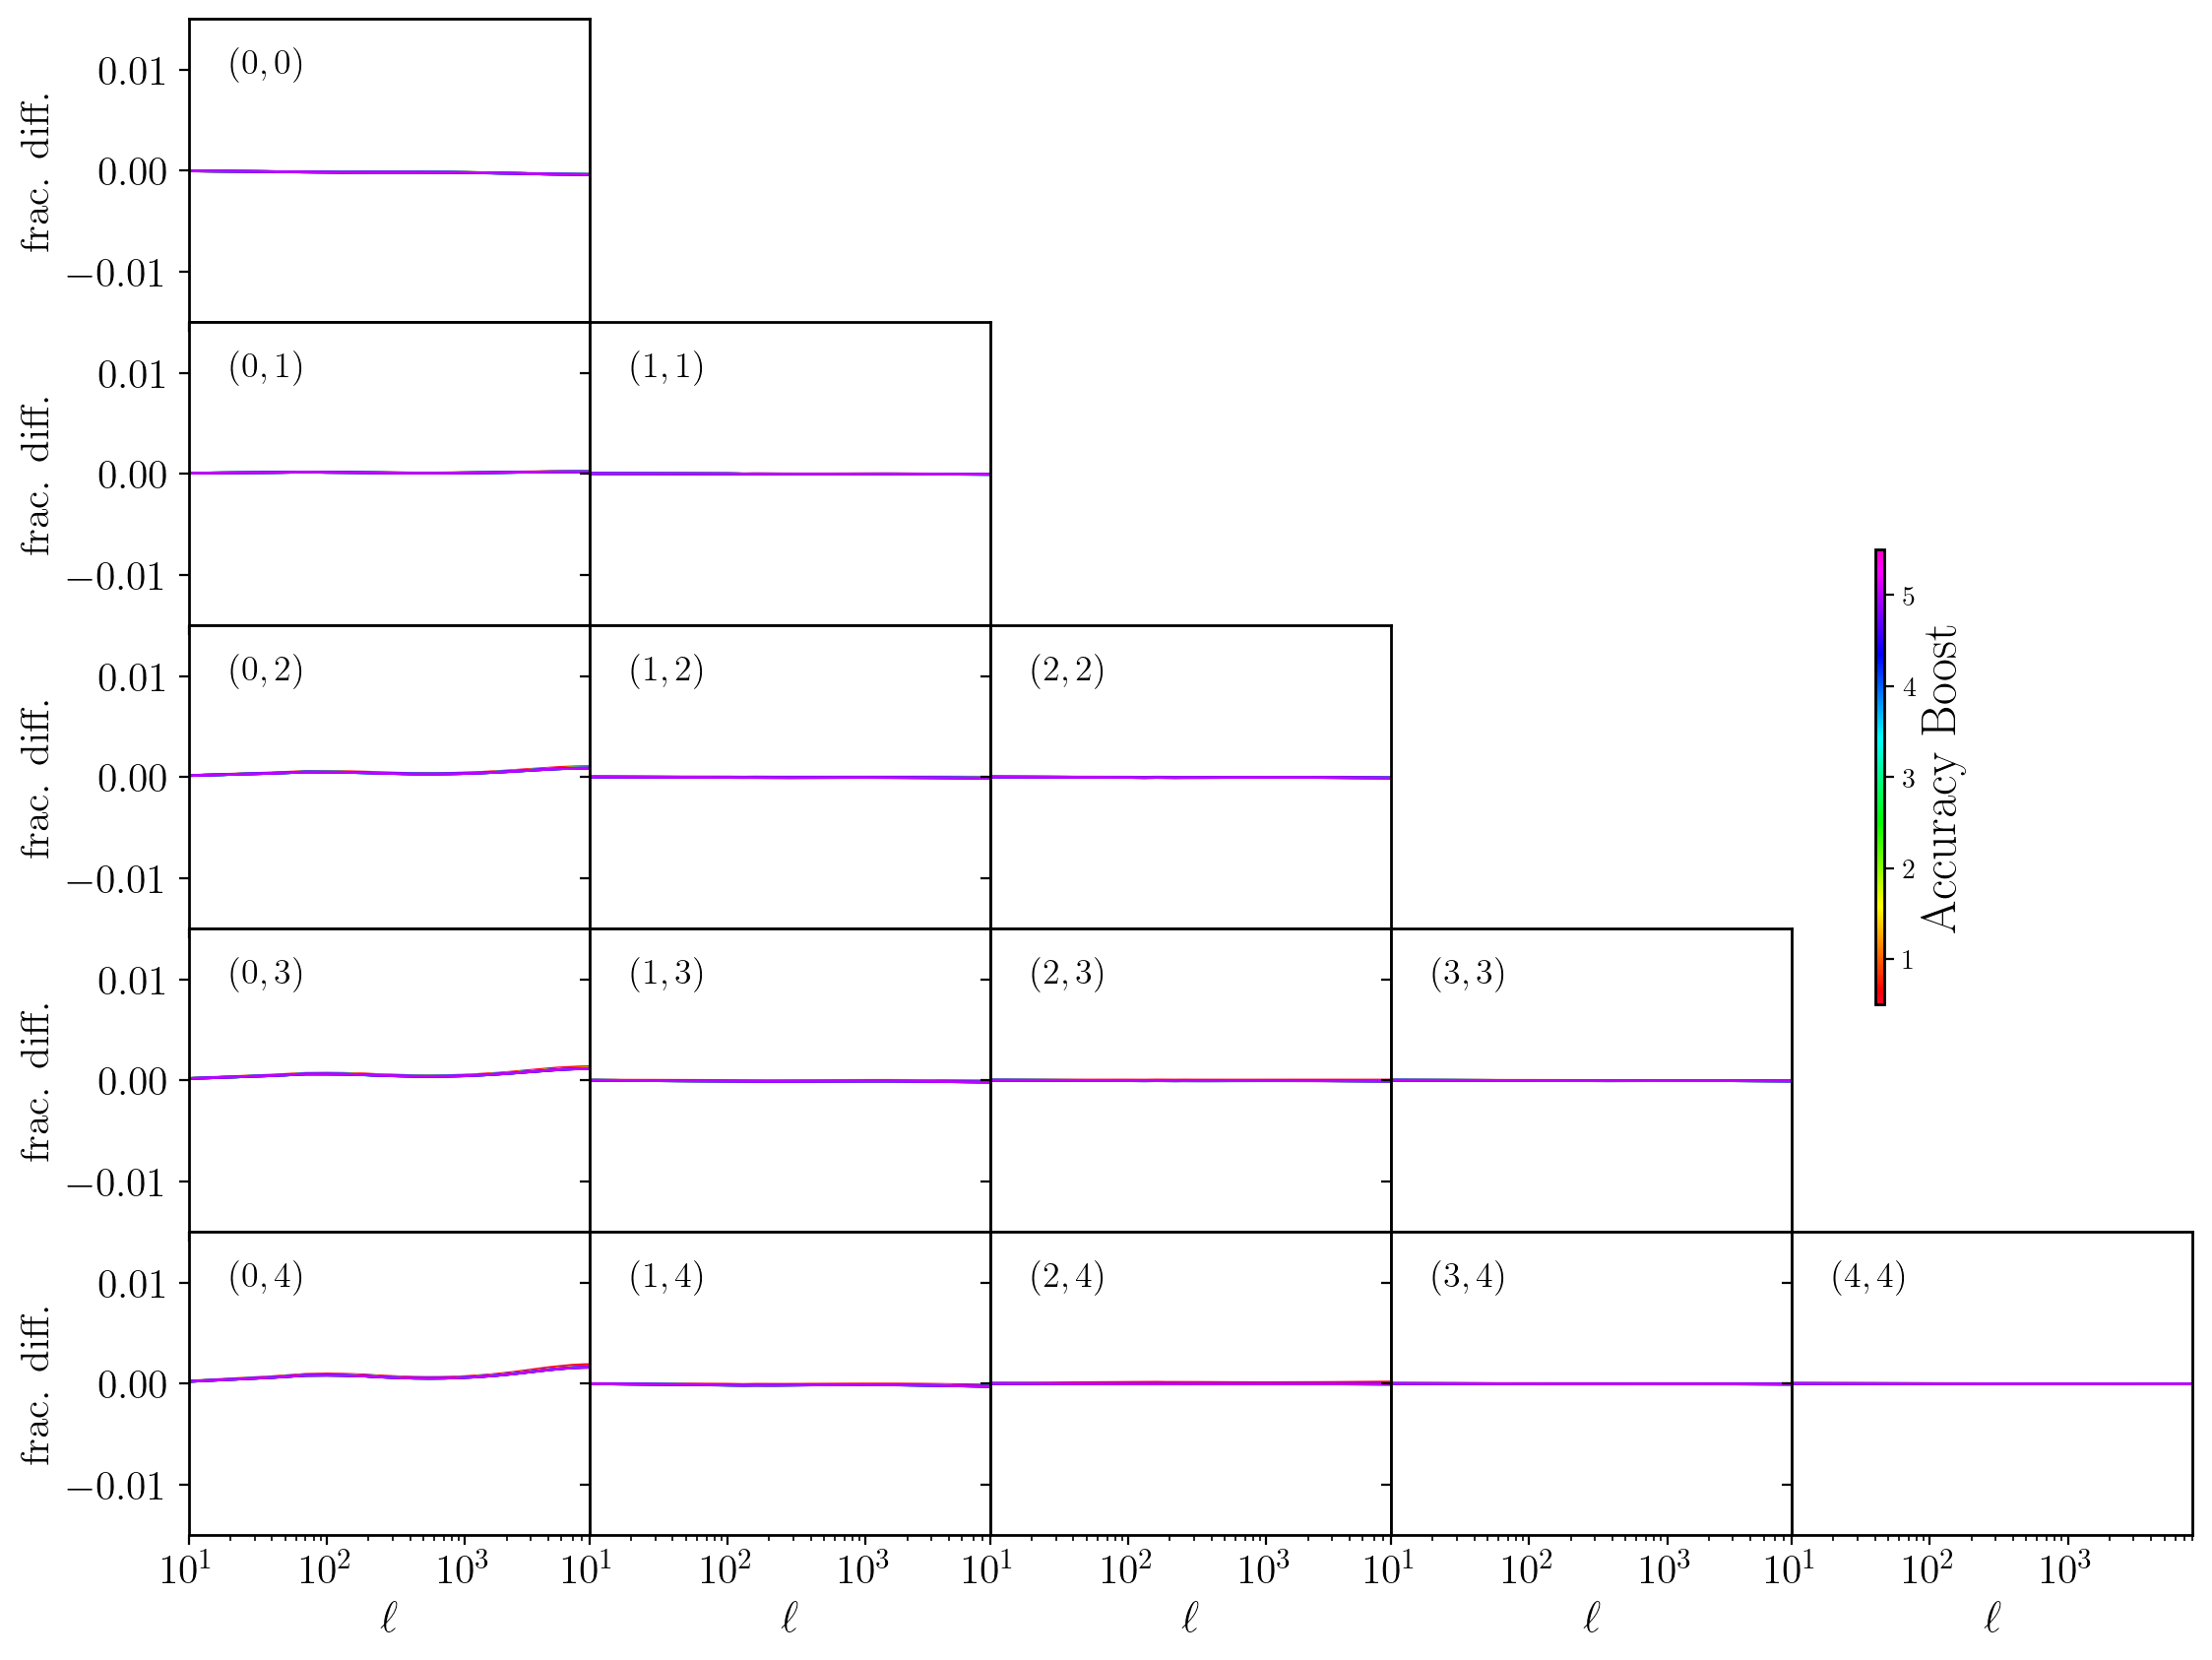

In [32]:
cnu.plot_C_ss_tomo_limber(ell=ell,
                          C_ss=C_ss,
                          C_ss_ref=C_ss_ref,
                          param=param,
                          lmin=10,
                          lmax=8000,
                          ylim=(0.985,1.015),
                          yaxislabelsize = 15,
                          xaxisticklabelsize=15,
                          yaxisticklabelsize=15,
                          colorbarlabel="Accuracy Boost",
                          figsize = (13, 10),
                          wspace=0.4)

In [33]:
ell = np.arange(10., 8500., 30.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = np.arange(1.,6.0,1)
C_ss = []
for x in param:
    # Change only CAMB Settings
    (Cl, tmp) = nw.C_ss_tomo_limber(ell=ell, AccuracyBoost=1,CAMBAccuracyBoost=1.+x/3,CLAccuracyBoost=1,CLIntegrationAccuracy=0)
    C_ss.append(Cl)
# Plot the Ratio over ref cosmology
(C_ss_ref, tmp) = nw.C_ss_tomo_limber(ell=ell,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=0)

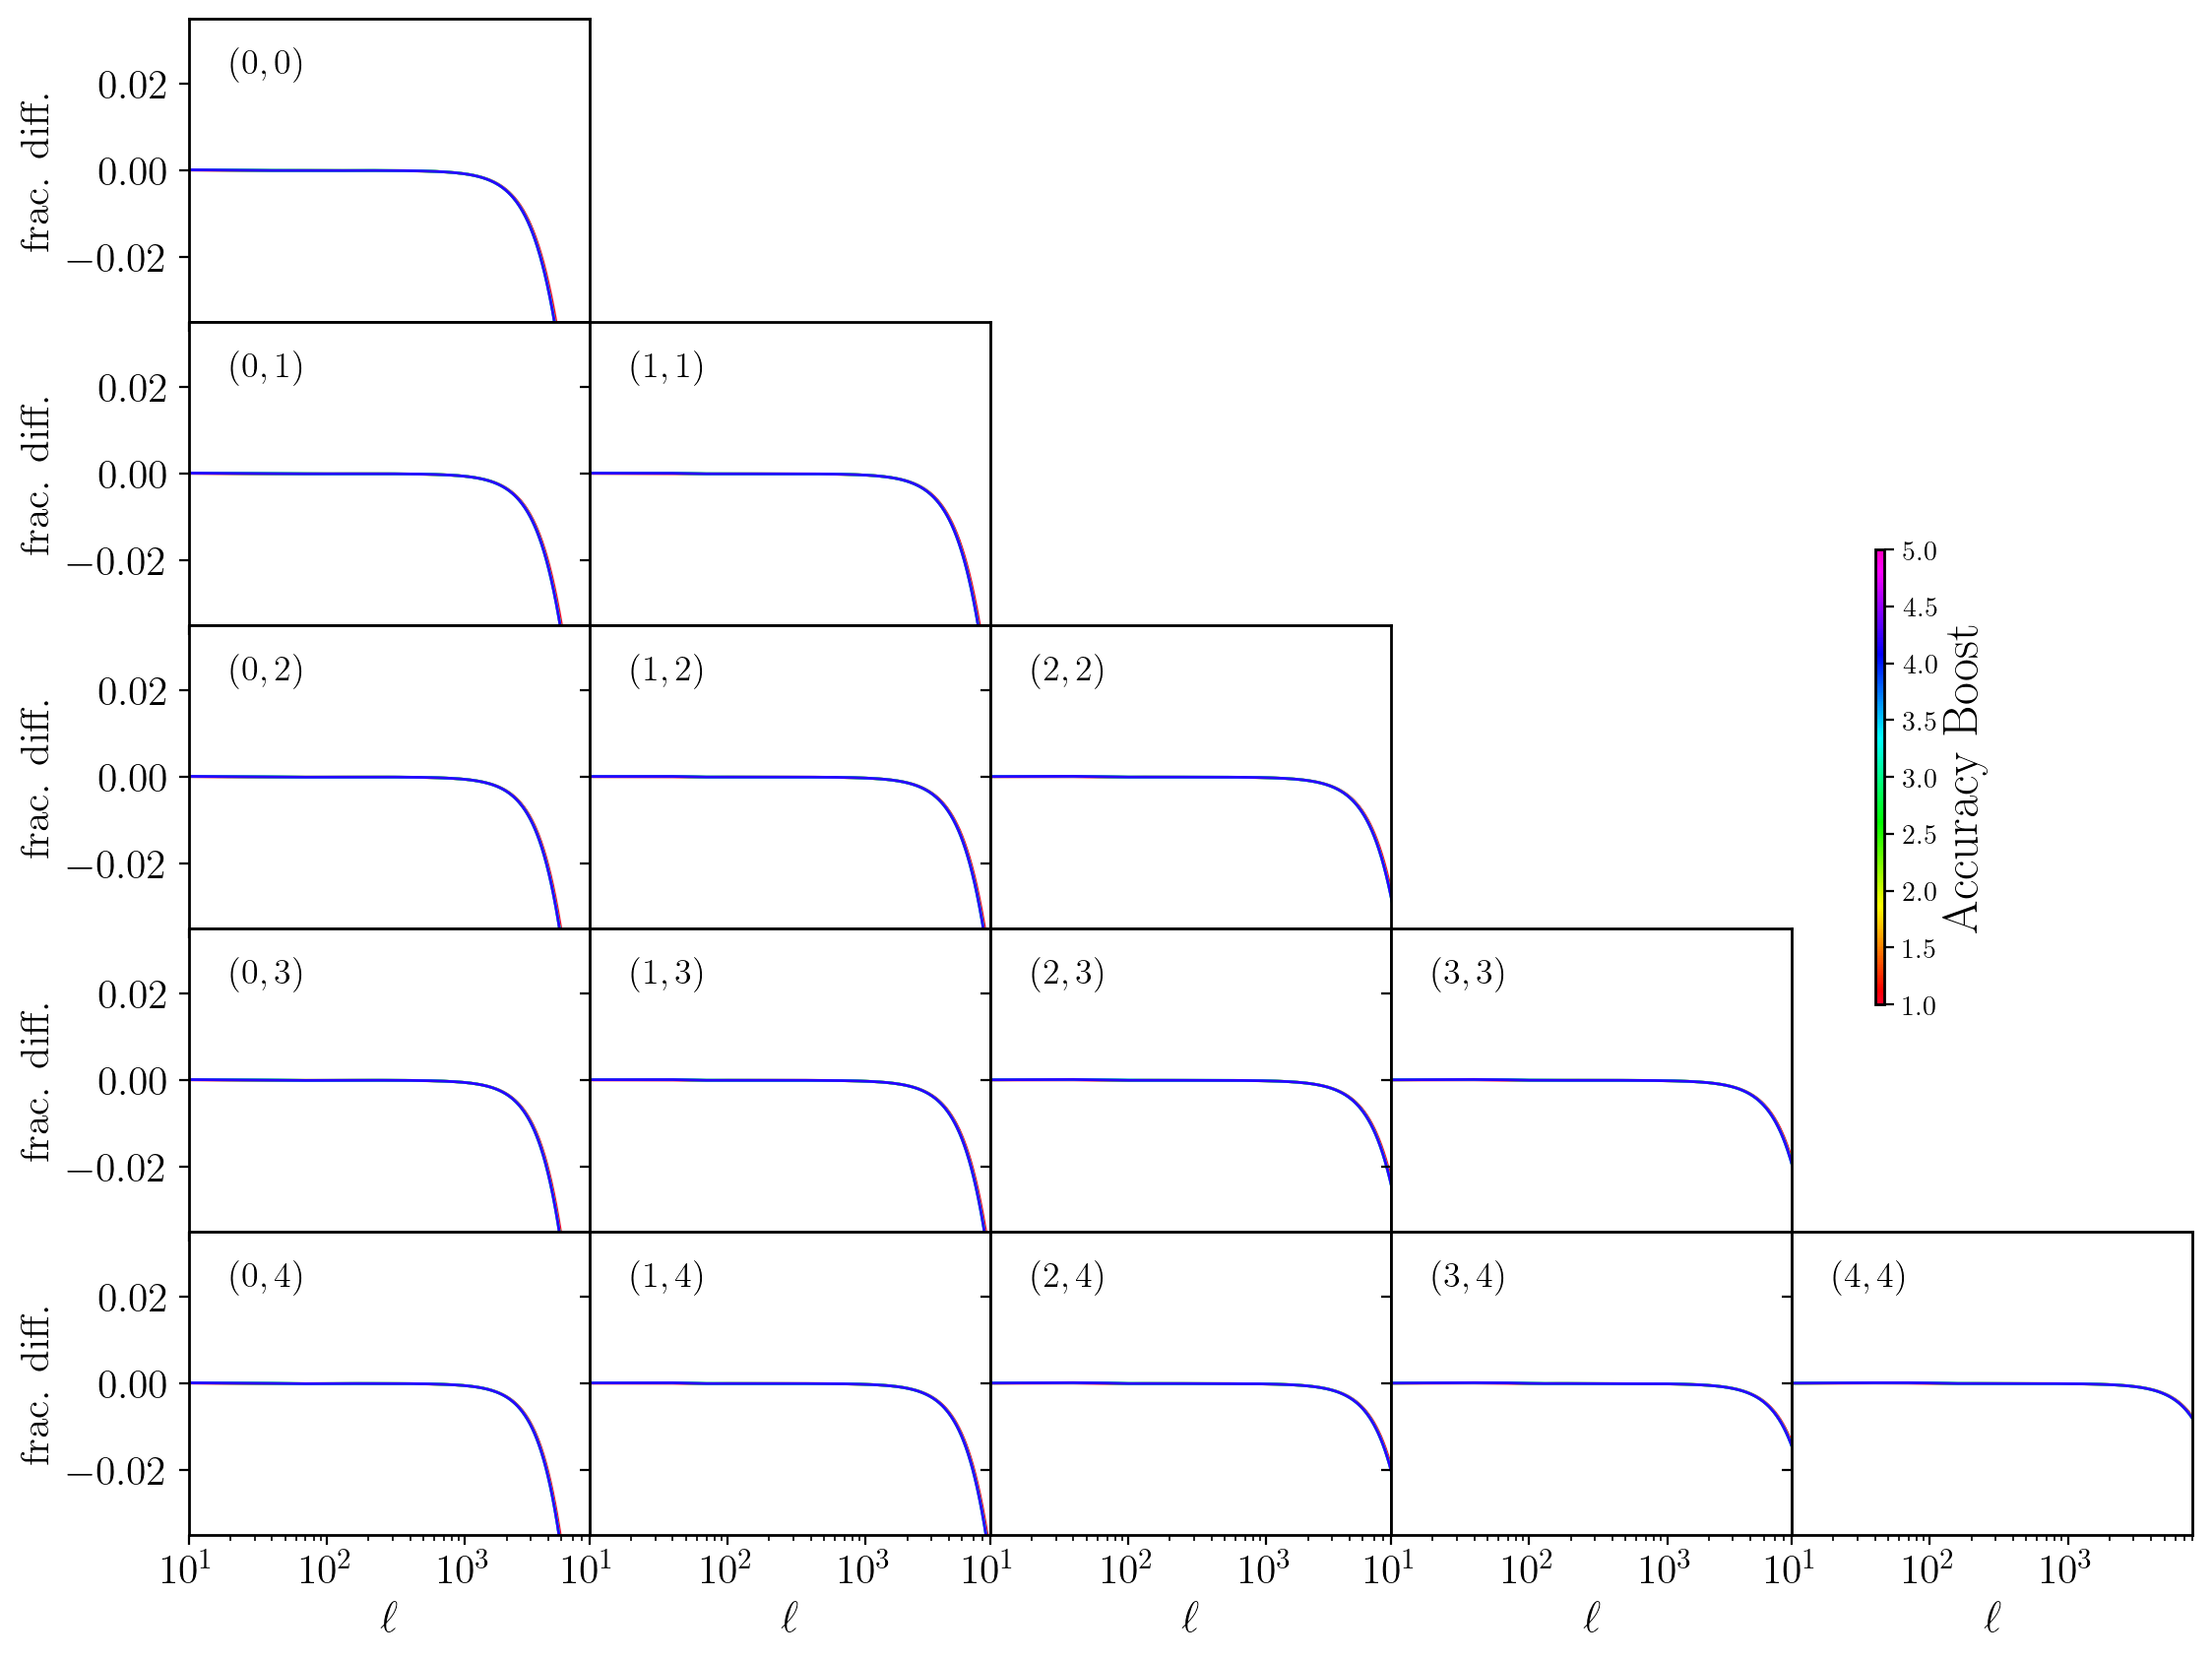

In [34]:
cnu.plot_C_ss_tomo_limber(ell=ell,
                          C_ss=C_ss,
                          C_ss_ref=C_ss_ref,
                          param=param,
                          lmin=10,
                          lmax=8000,
                          ylim=(0.965,1.035),
                          yaxislabelsize = 15,
                          xaxisticklabelsize=15,
                          yaxisticklabelsize=15,
                          figsize = (13, 10),
                          colorbarlabel="Accuracy Boost")

In [35]:
param = np.arange(0,6.0,0.5)
xi_theta_ref = nw.xi(ntheta=40,AccuracyBoost=1,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=0)
xi_theta = []
for x in param:
    xi_theta.append(nw.xi(ntheta=40,AccuracyBoost=1,CAMBAccuracyBoost=1+x/3,CLAccuracyBoost=1,CLIntegrationAccuracy=0))

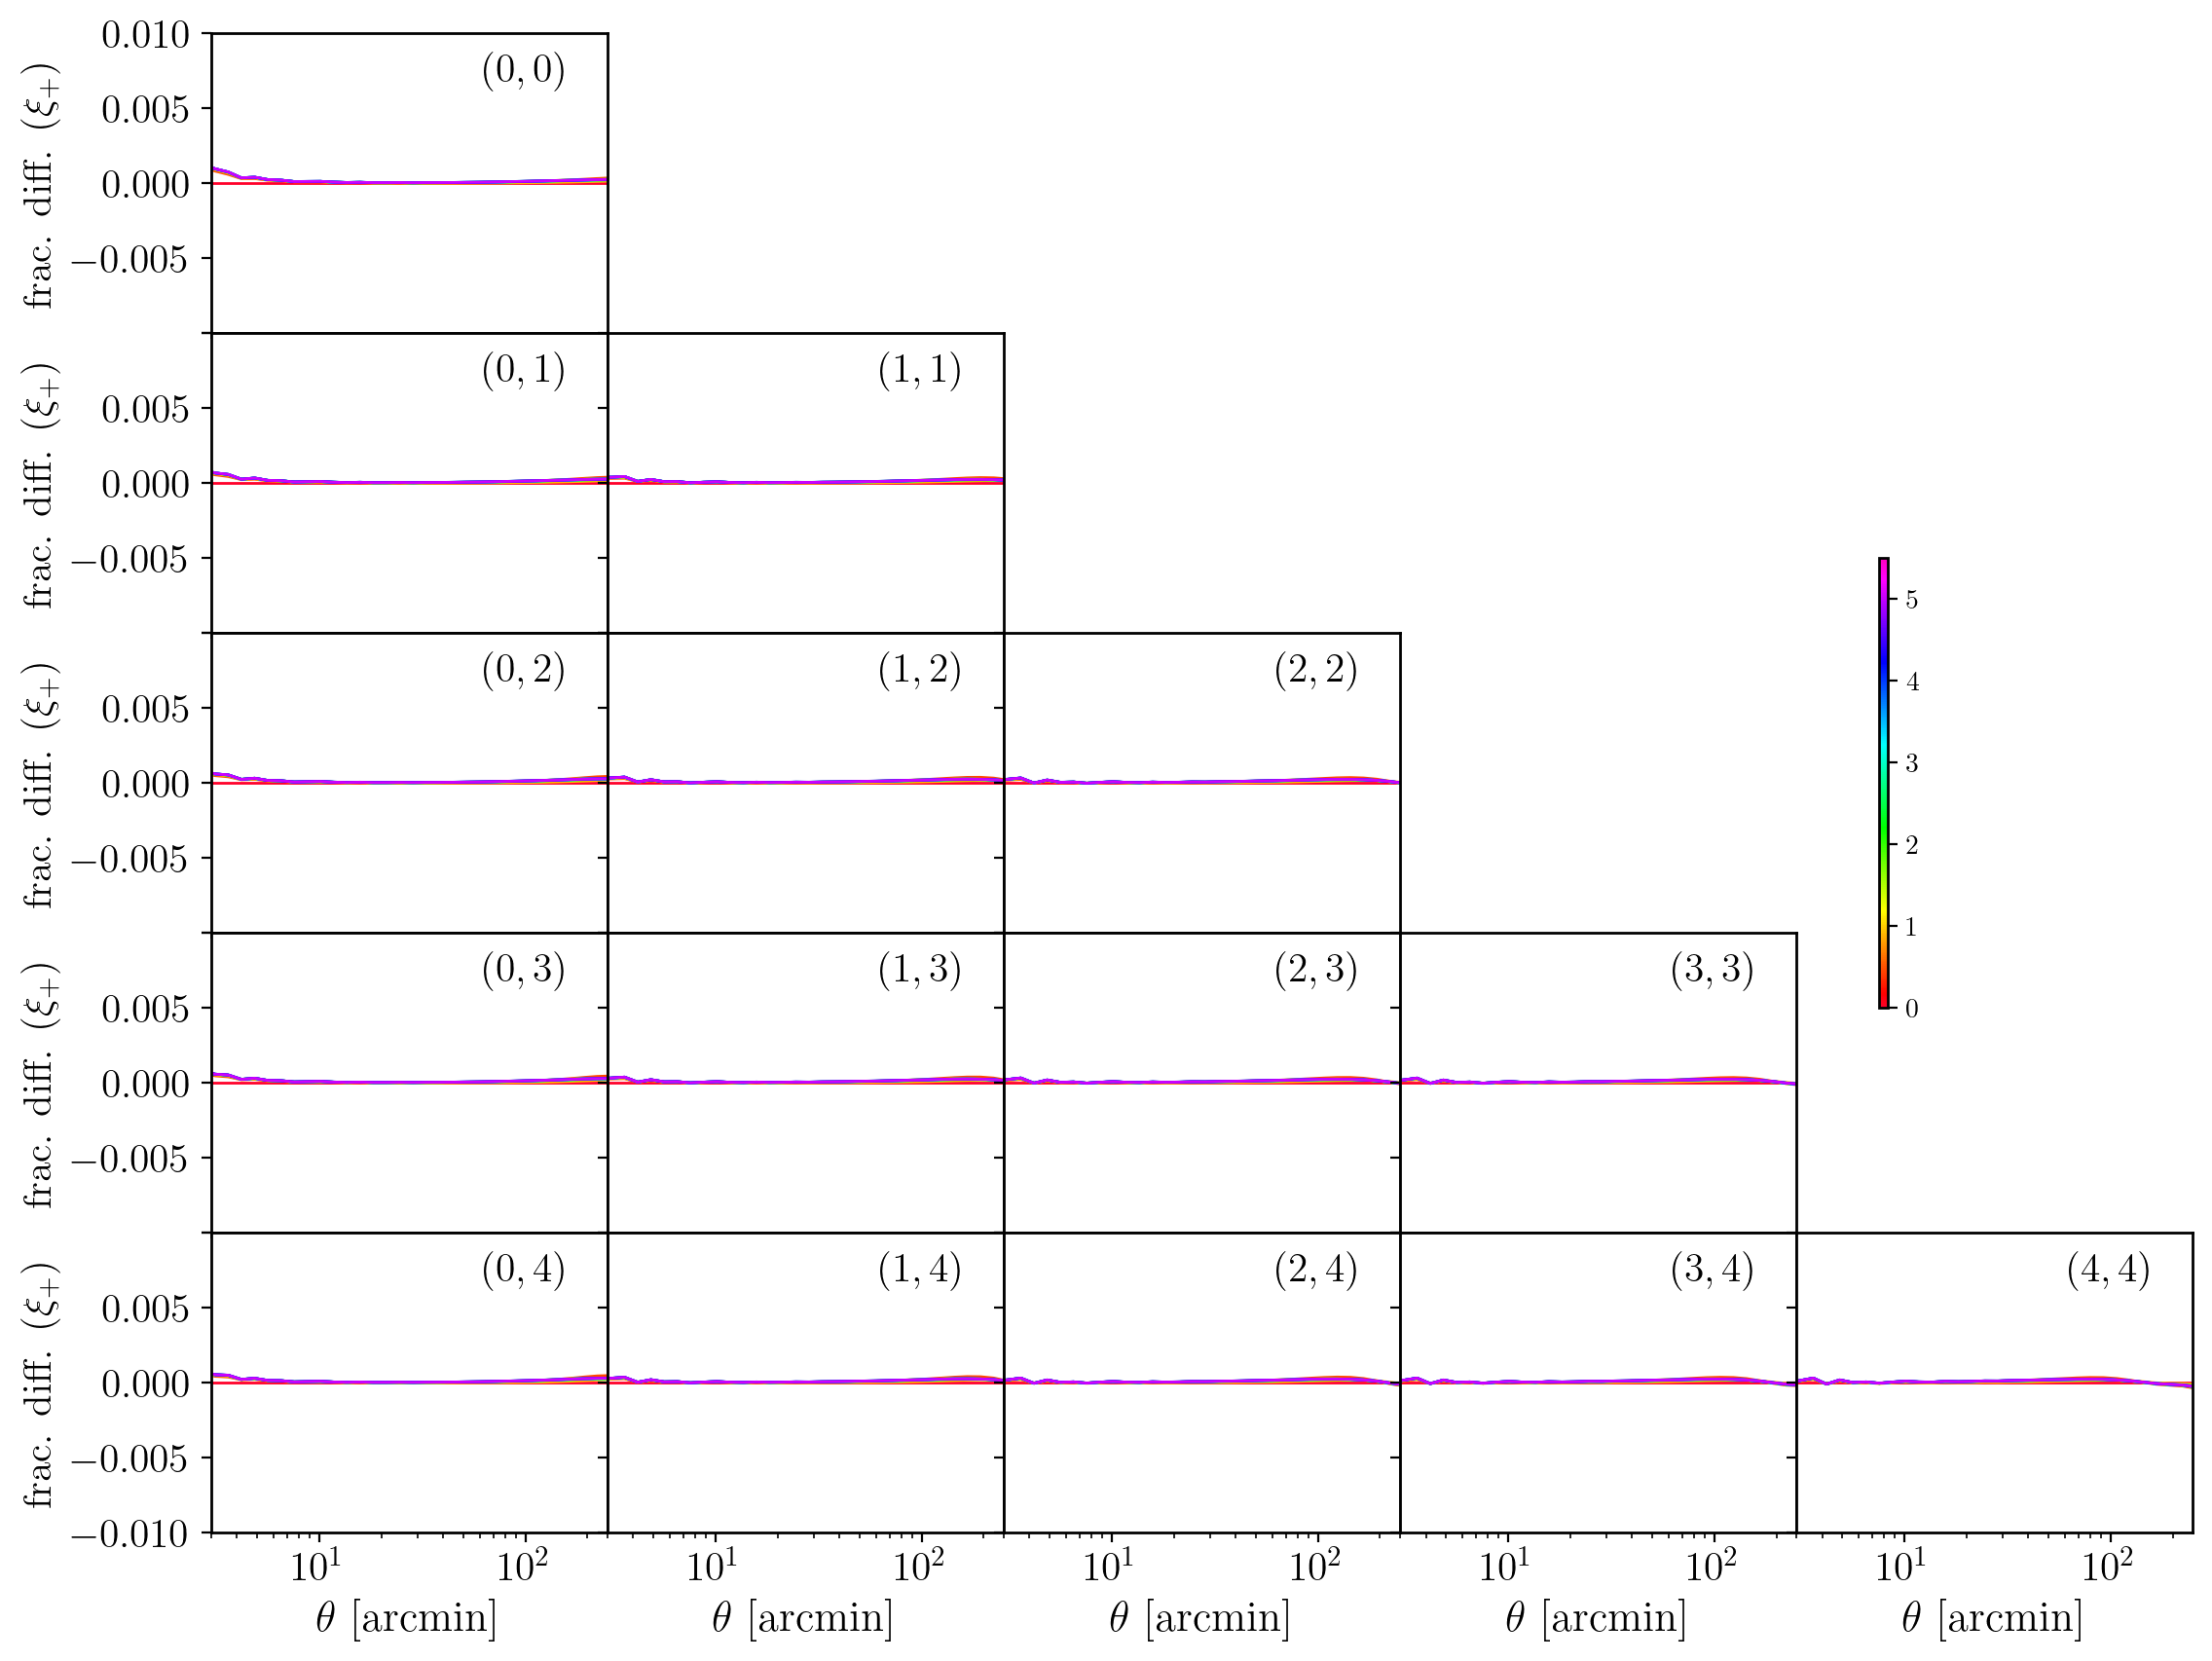

In [36]:
cnu.plot_xi(pm = 1,
            xi = xi_theta,
            xi_ref = xi_theta_ref,
            param=param,
            yaxislabelsize = 15,
            xaxisticklabelsize=15,
            yaxisticklabelsize=15,
            figsize = (13, 10),
            ylim=(0.99, 1.01))

In [37]:
param = np.arange(0,6.0,0.5)
xi_theta_ref = nw.xi(ntheta=40,AccuracyBoost=1,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=0)
xi_theta = []
for x in param:
    xi_theta.append(nw.xi(ntheta=40,AccuracyBoost=1,CAMBAccuracyBoost=1.,CLAccuracyBoost=1+x,CLIntegrationAccuracy=int(x)))

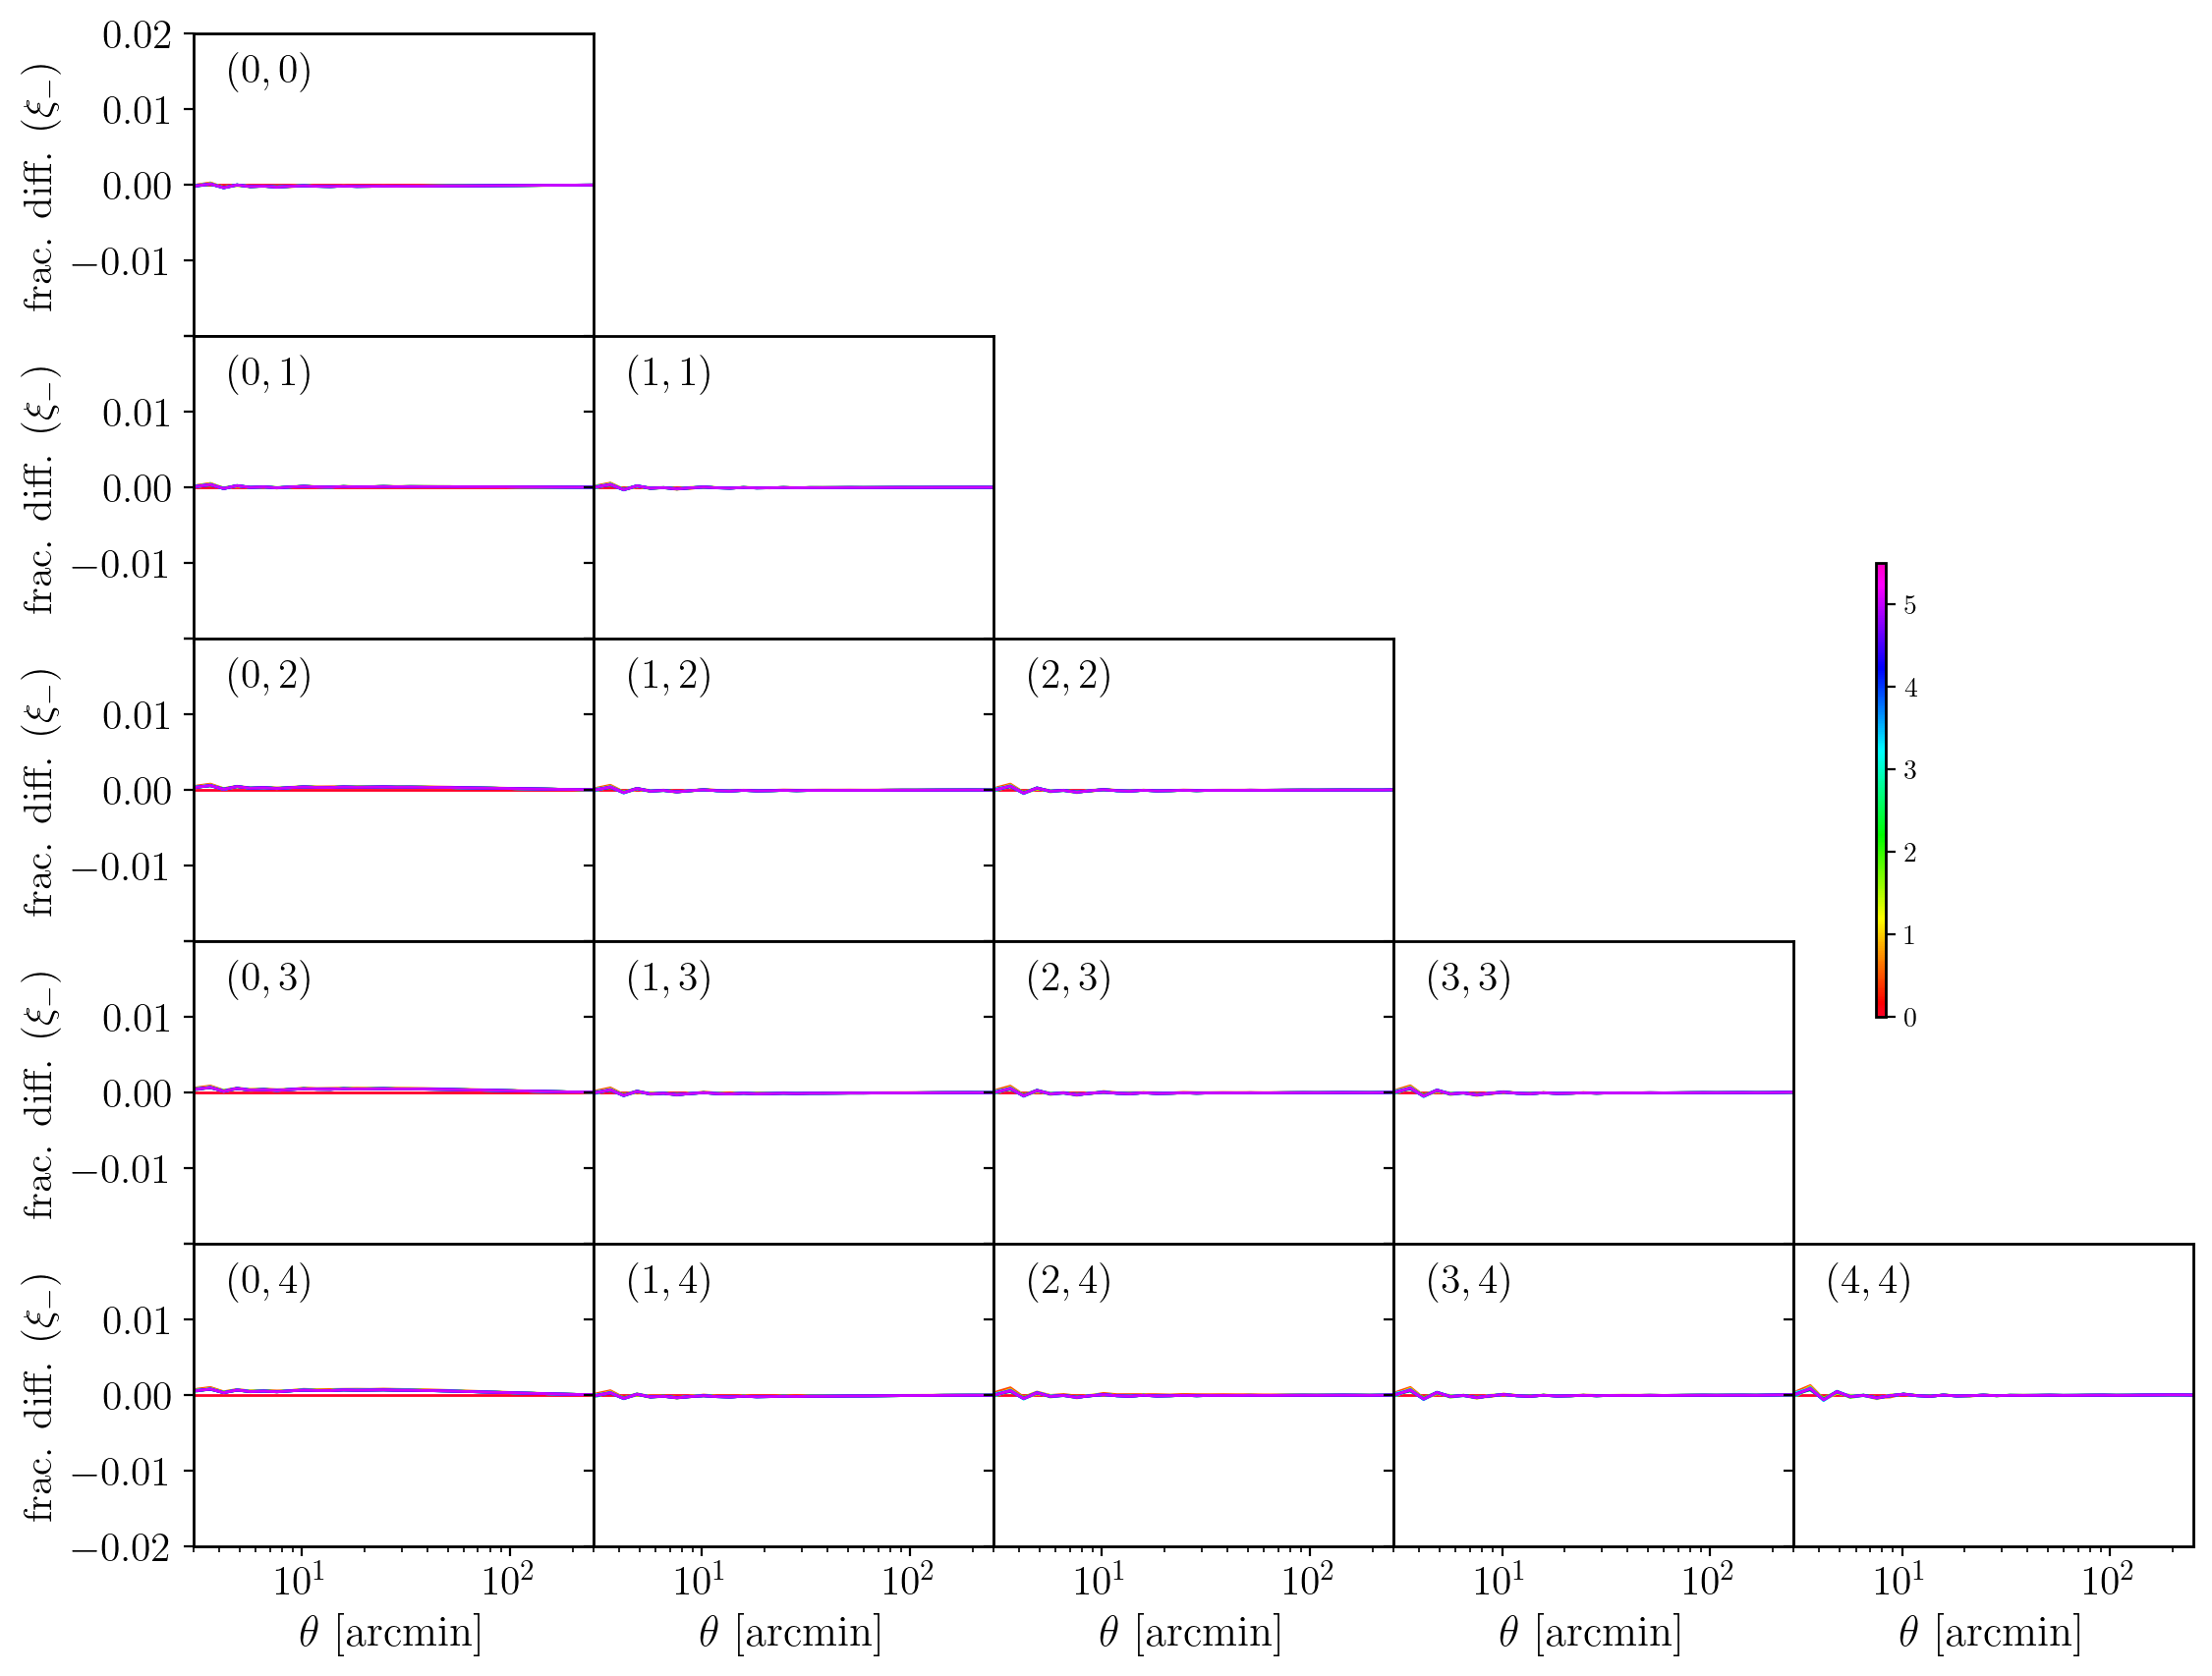

In [38]:
cnu.plot_xi(pm=0,
            xi=xi_theta,
            xi_ref=xi_theta_ref,
            param=param,
            yaxislabelsize = 15,
            xaxisticklabelsize=15,
            yaxisticklabelsize=15,
            figsize = (13, 10),
            ylim=(0.98,1.02))

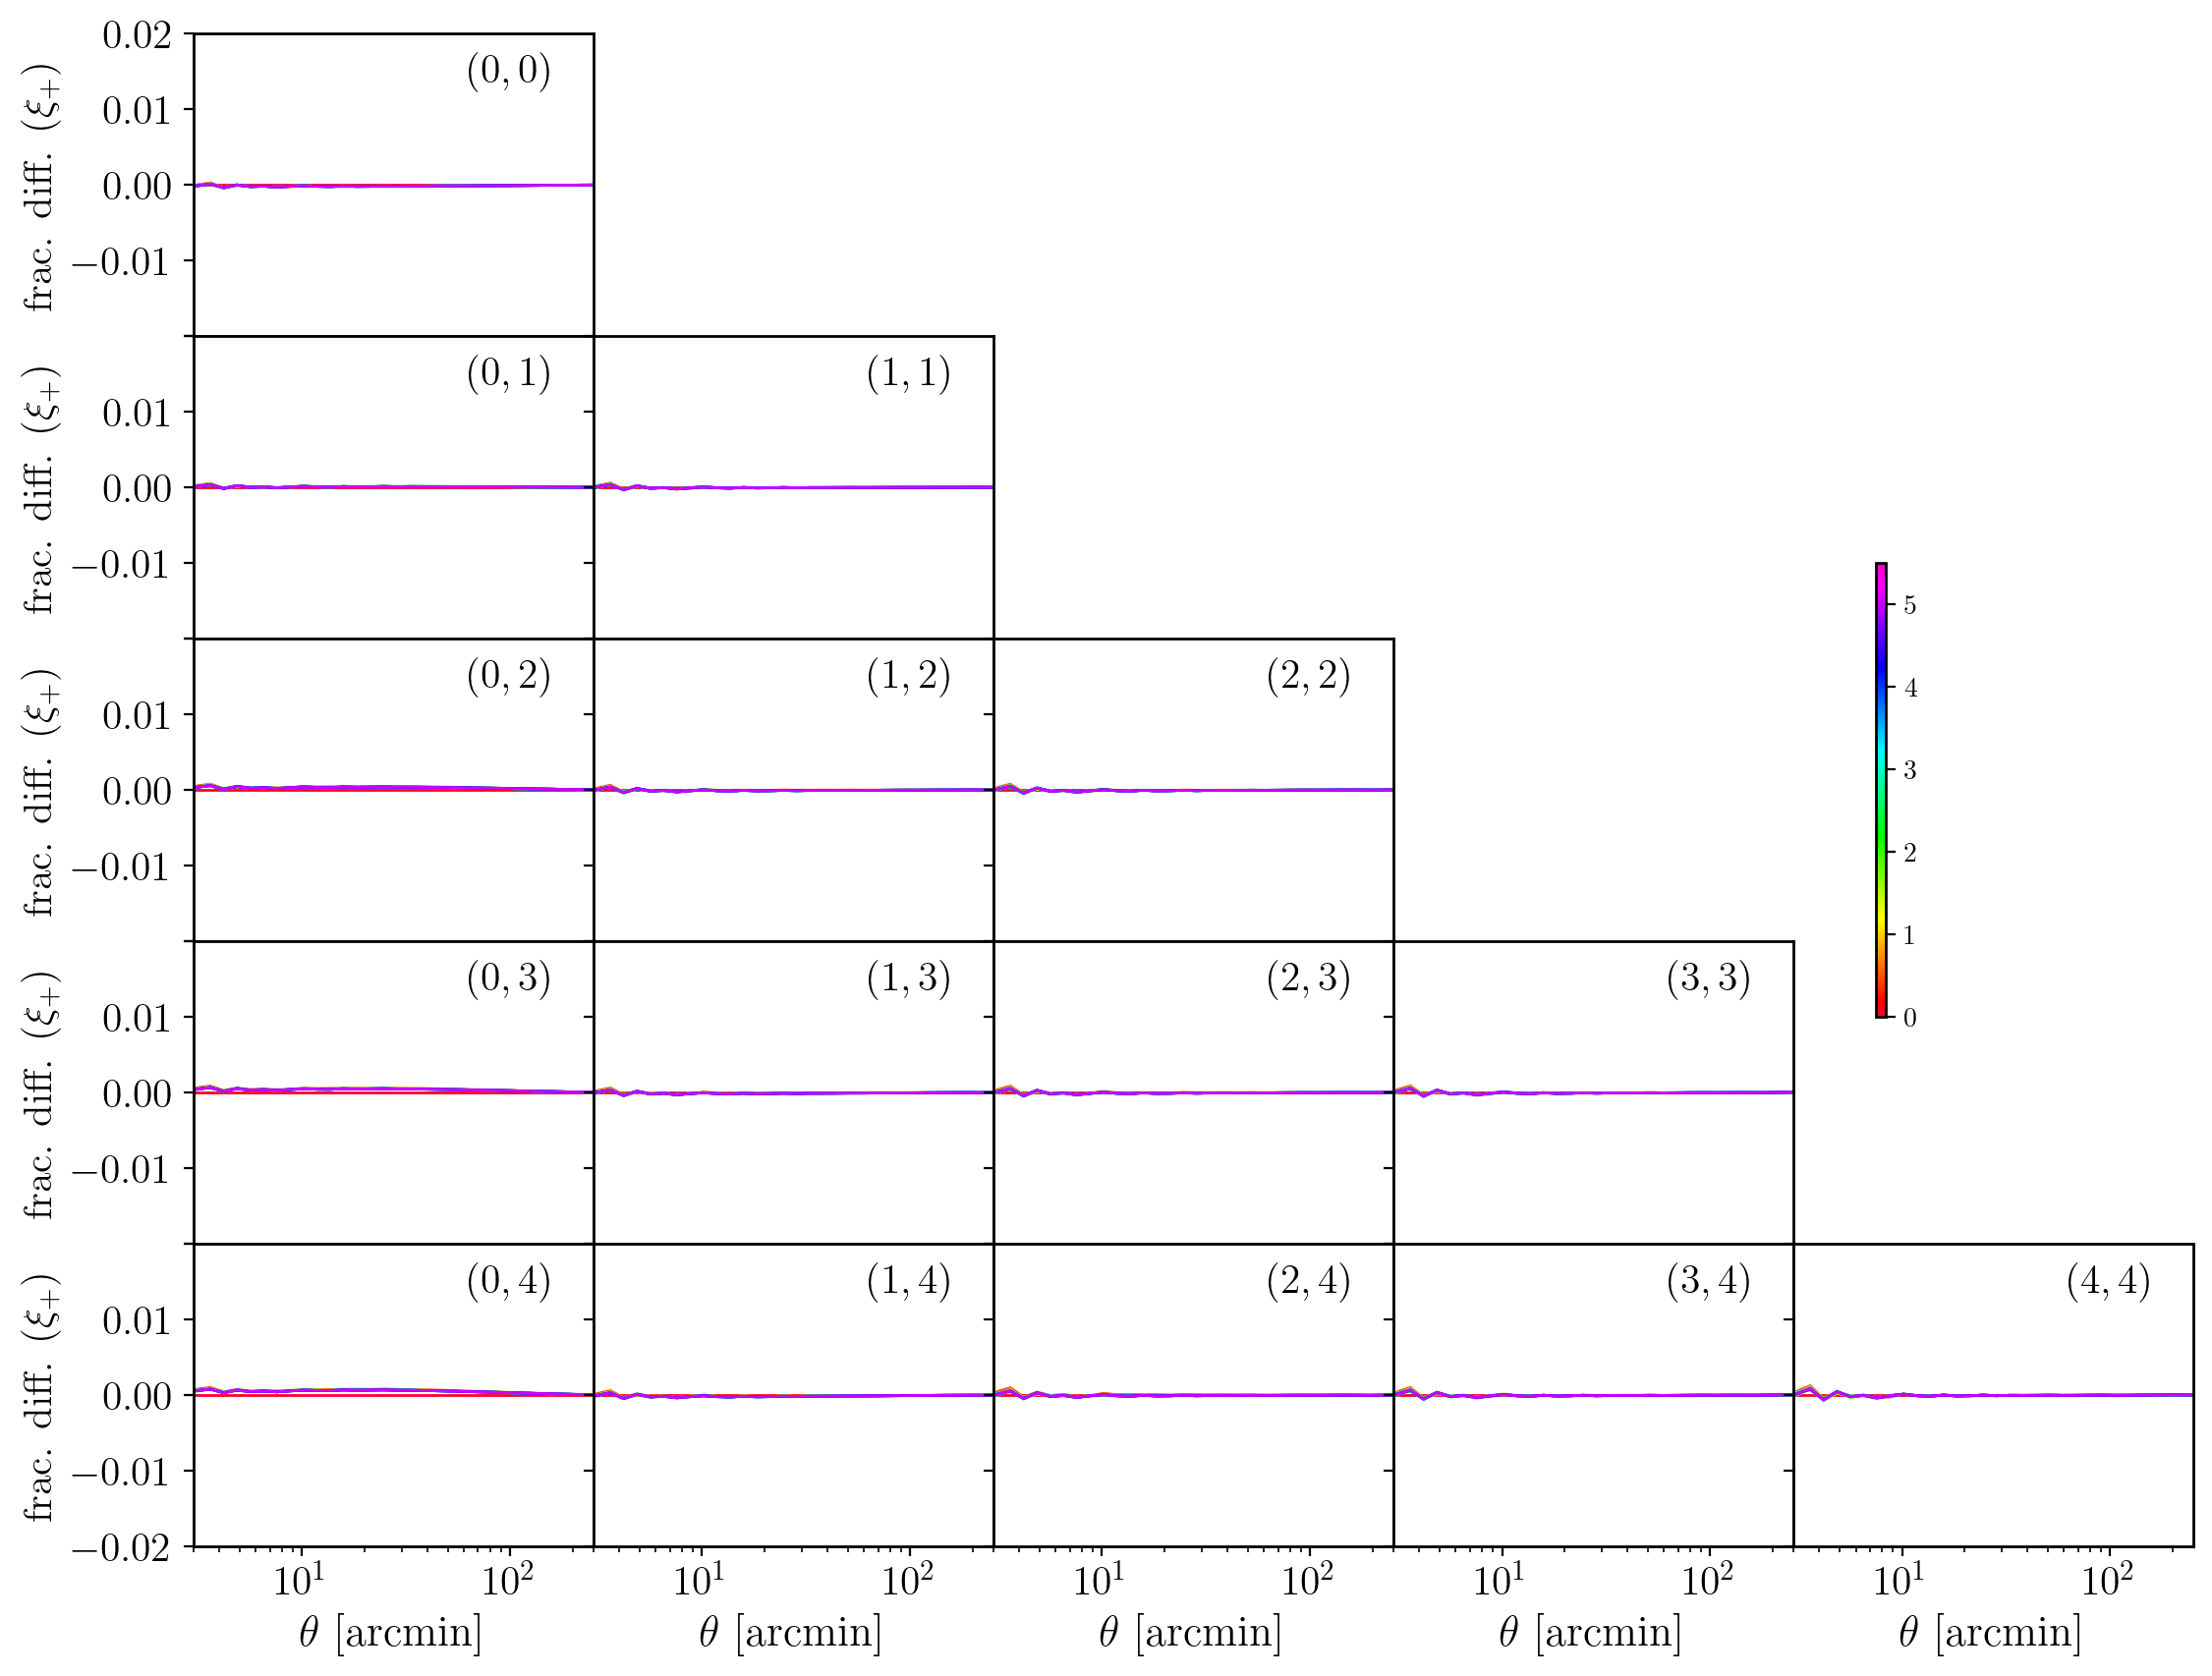

In [39]:
cnu.plot_xi(pm=1,
            xi=xi_theta,
            xi_ref=xi_theta_ref,
            param=param,
            yaxislabelsize = 15,
            xaxisticklabelsize=15,
            yaxisticklabelsize=15,
            figsize = (13, 10),
            ylim=(0.98,1.02))

# Let's compute $\chi^2_{\rm LSST}$ and reproduce the results shown on EXAMPLE_EVALUATE1.YAML

In [ ]:
# Re-init with the chi2 machinery: probes, covariance, mask, and
# data vector (nw.init_cosmolike holds the full sequence)
ini = nw.init_cosmolike(CLprobe="xi", with_data=True)

In [41]:
param = np.arange(0.295, 0.305, 0.001)      
chi2 = []
for x in param:
    chi2.append(nw.get_chi2(omegam = x))

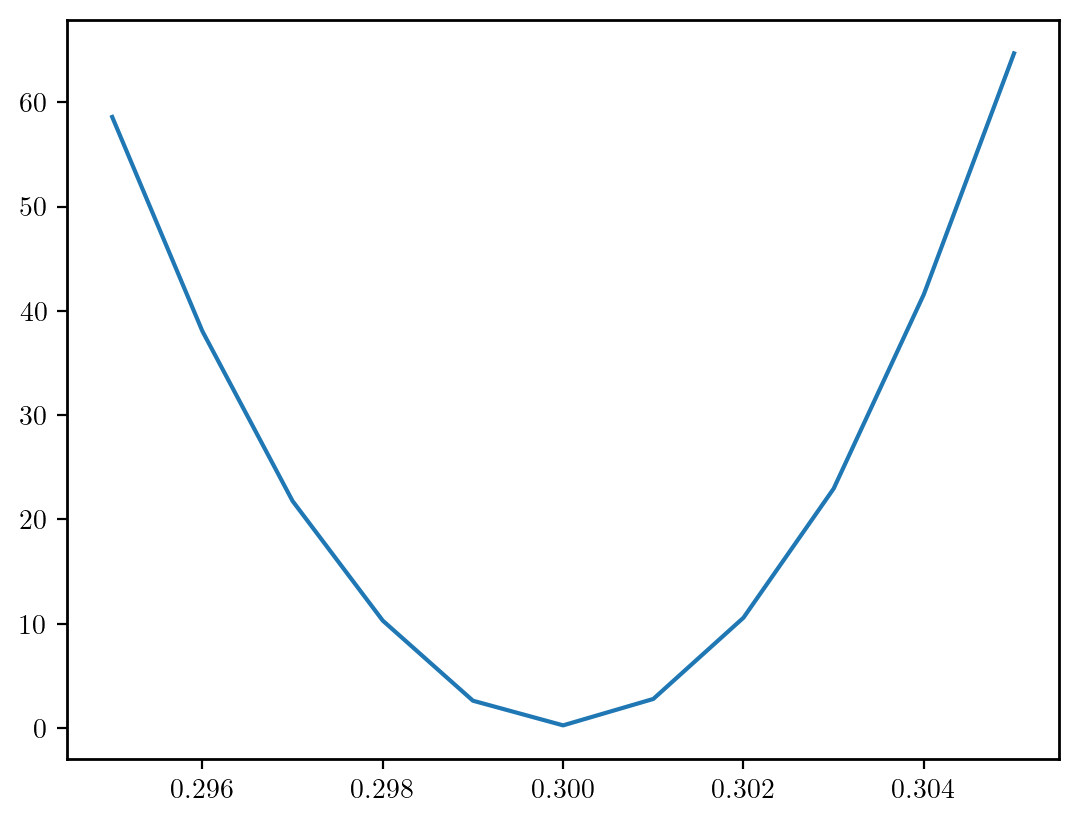

In [42]:
plt.plot(param, chi2)

# Let's compute $\chi^2_{\rm LSST}$ as function of CAMB+Cosmolike Integration Accuracy

In [26]:
param = np.arange(0., 6., 0.5)      
chi2 = []
for x in param:
    chi2.append(nw.get_chi2(AccuracyBoost = 1, CAMBAccuracyBoost = 1.+ x/3.0, CLAccuracyBoost = 1 + x, CLIntegrationAccuracy = 1))
chi2 = np.array(chi2)

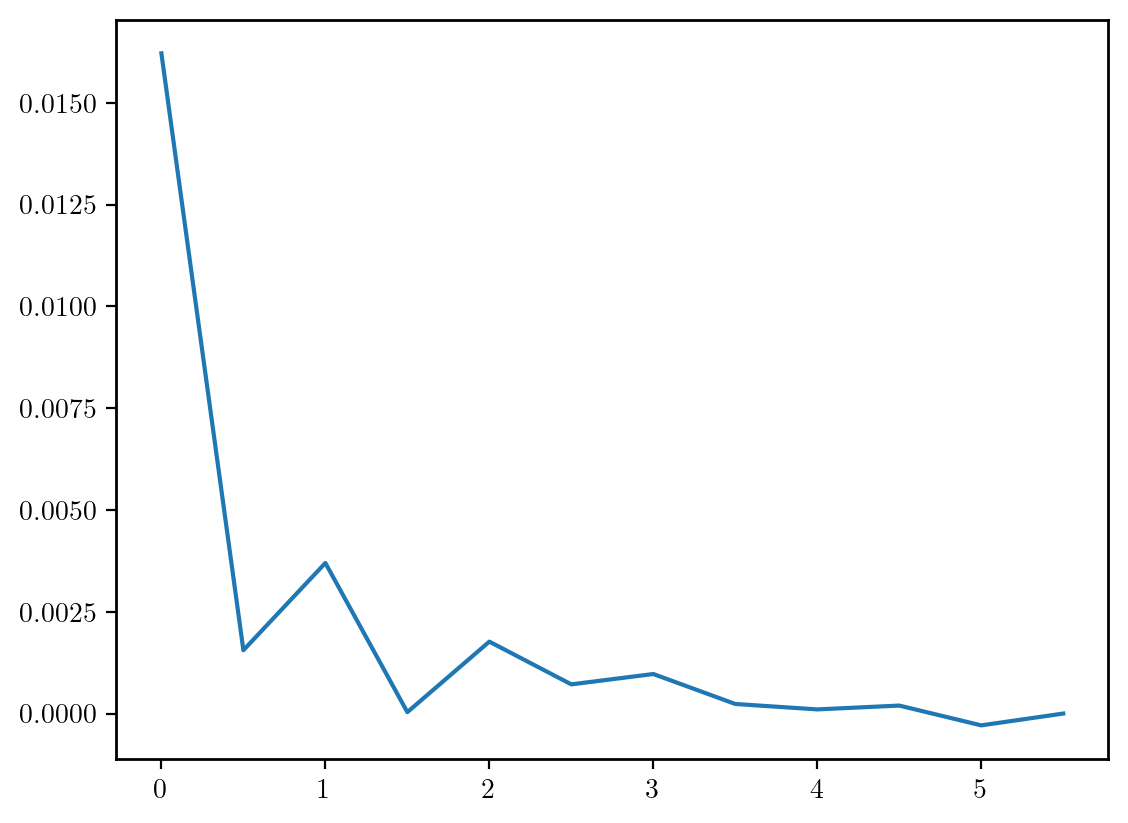

In [27]:
plt.plot(param, np.array(chi2 - chi2[-1]))

In [29]:
# Do we get the similar behaviour by just changing AccuracyBoost (which we design to change all parameters at once)
param = np.arange(0, 6, 0.5)      
chi2 = []
for x in param:
    chi2.append(nw.get_chi2(AccuracyBoost = 1 + x))
chi2 = np.array(chi2)

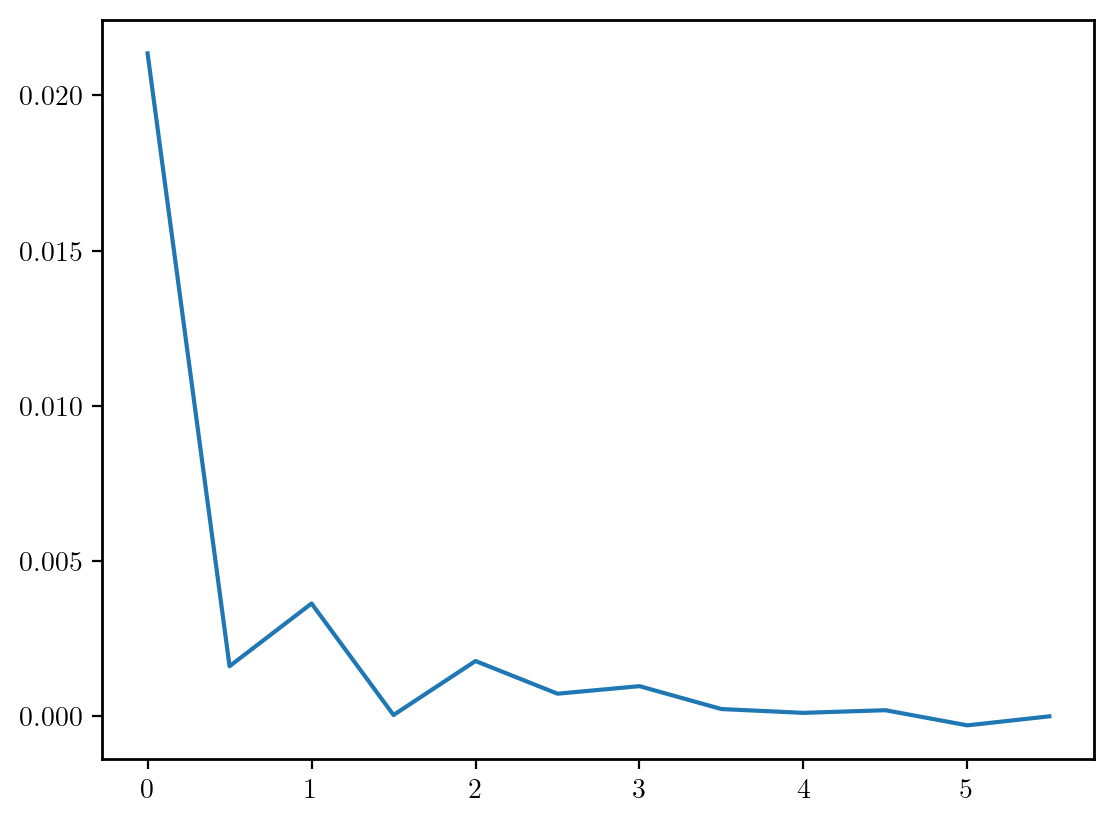

In [30]:
plt.plot(param, np.array(chi2 - chi2[-1]))

# Let's Plot HALOFIT VS EE2

In [28]:
print(rf"$\chi^2$={nw.get_chi2(non_linear_emul=1):3.3f}")
print(rf"$\chi^2$={nw.get_chi2(non_linear_emul=2):3.3f}")

$\chi^2$=12.279
$\chi^2$=0.238


In [48]:
ell = np.arange(10., 8500., 30.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = [1]
C_ss = []
for x in param:
    # Change only Cosmolike Settings
    (Cl, tmp) = nw.C_ss_tomo_limber(ell=ell, AccuracyBoost=1,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=0,non_linear_emul=2)
    C_ss.append(Cl)
(C_ss_ref, tmp) = nw.C_ss_tomo_limber(ell=ell,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=0,non_linear_emul=1)

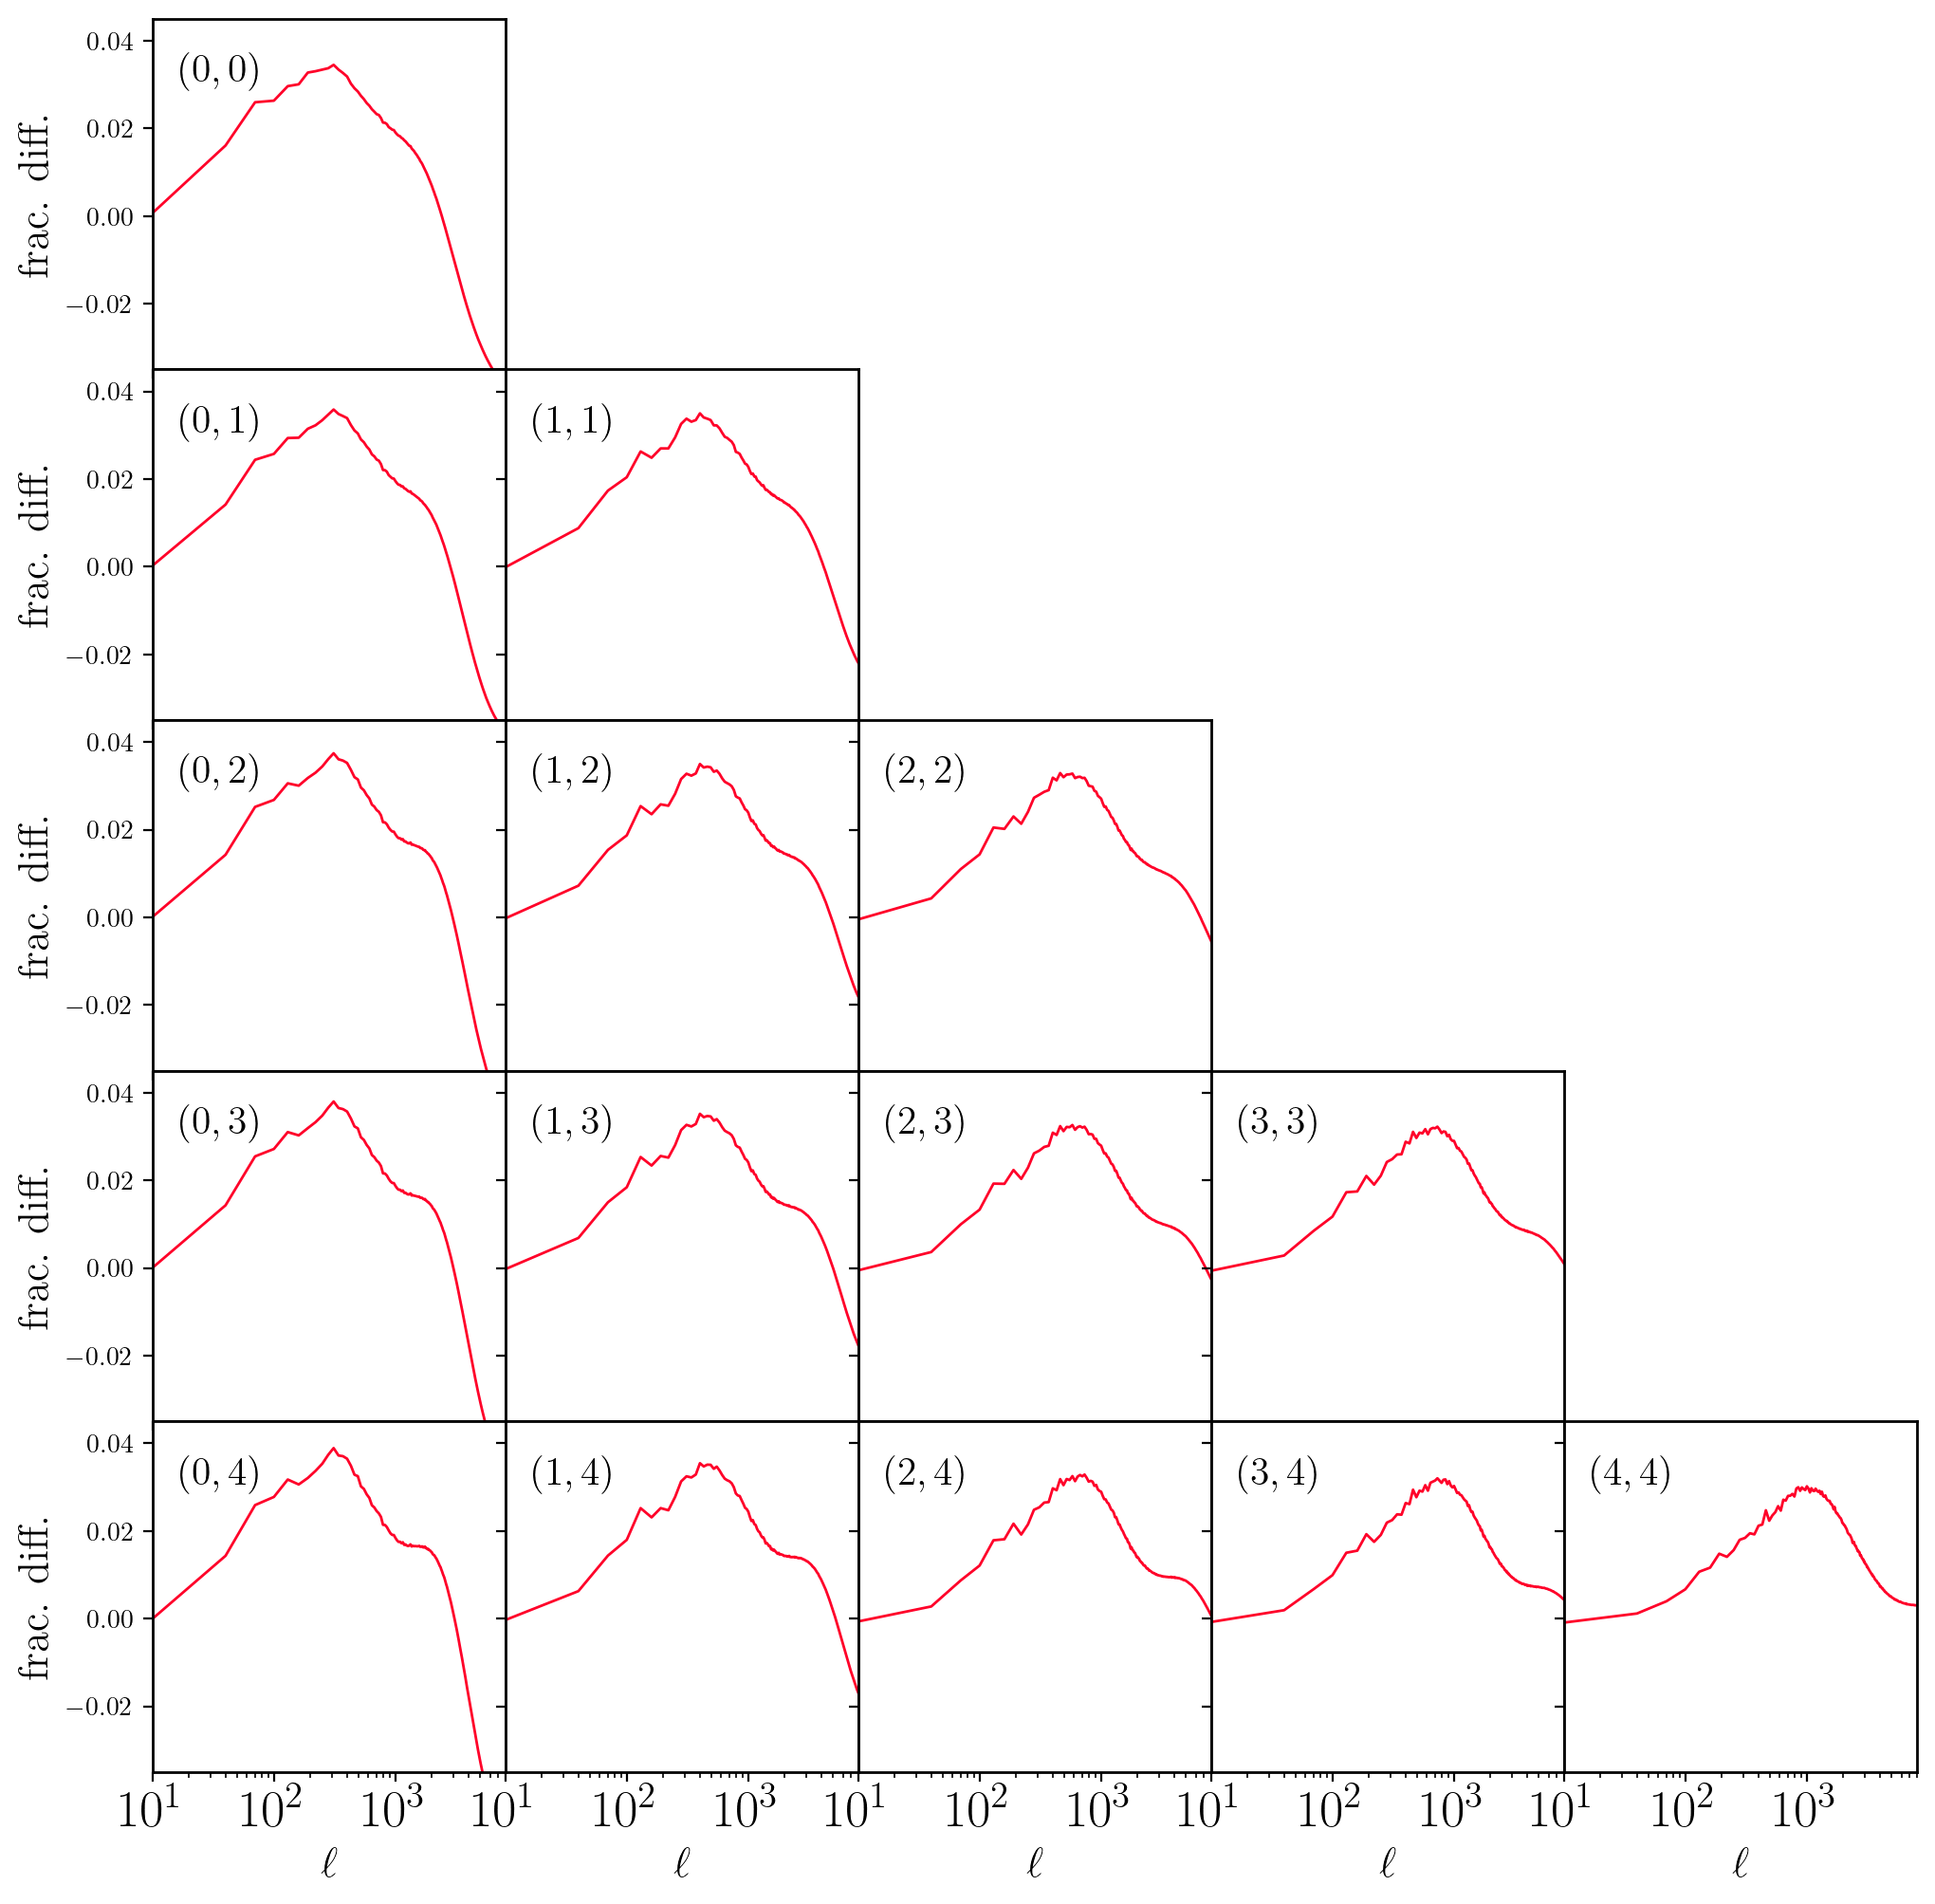

In [50]:
# Plot the Ratio over ref cosmology
cnu.plot_C_ss_tomo_limber(ell=ell,
                          C_ss=C_ss,
                          C_ss_ref=C_ss_ref,
                          param=param,
                          lmin=10,
                          lmax=8000,
                          ylim=(0.965,1.045),
                          colorbarlabel="Accuracy Boost",
                          colorbar=None)

In [38]:
param = [1]
xi_theta_ref = nw.xi(ntheta=40,AccuracyBoost=1,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=0,non_linear_emul=2)
xi_theta = []
for x in param:
    xi_theta.append(nw.xi(ntheta=40,AccuracyBoost=1,CAMBAccuracyBoost=1+x/3,CLAccuracyBoost=1,CLIntegrationAccuracy=0,non_linear_emul=1))

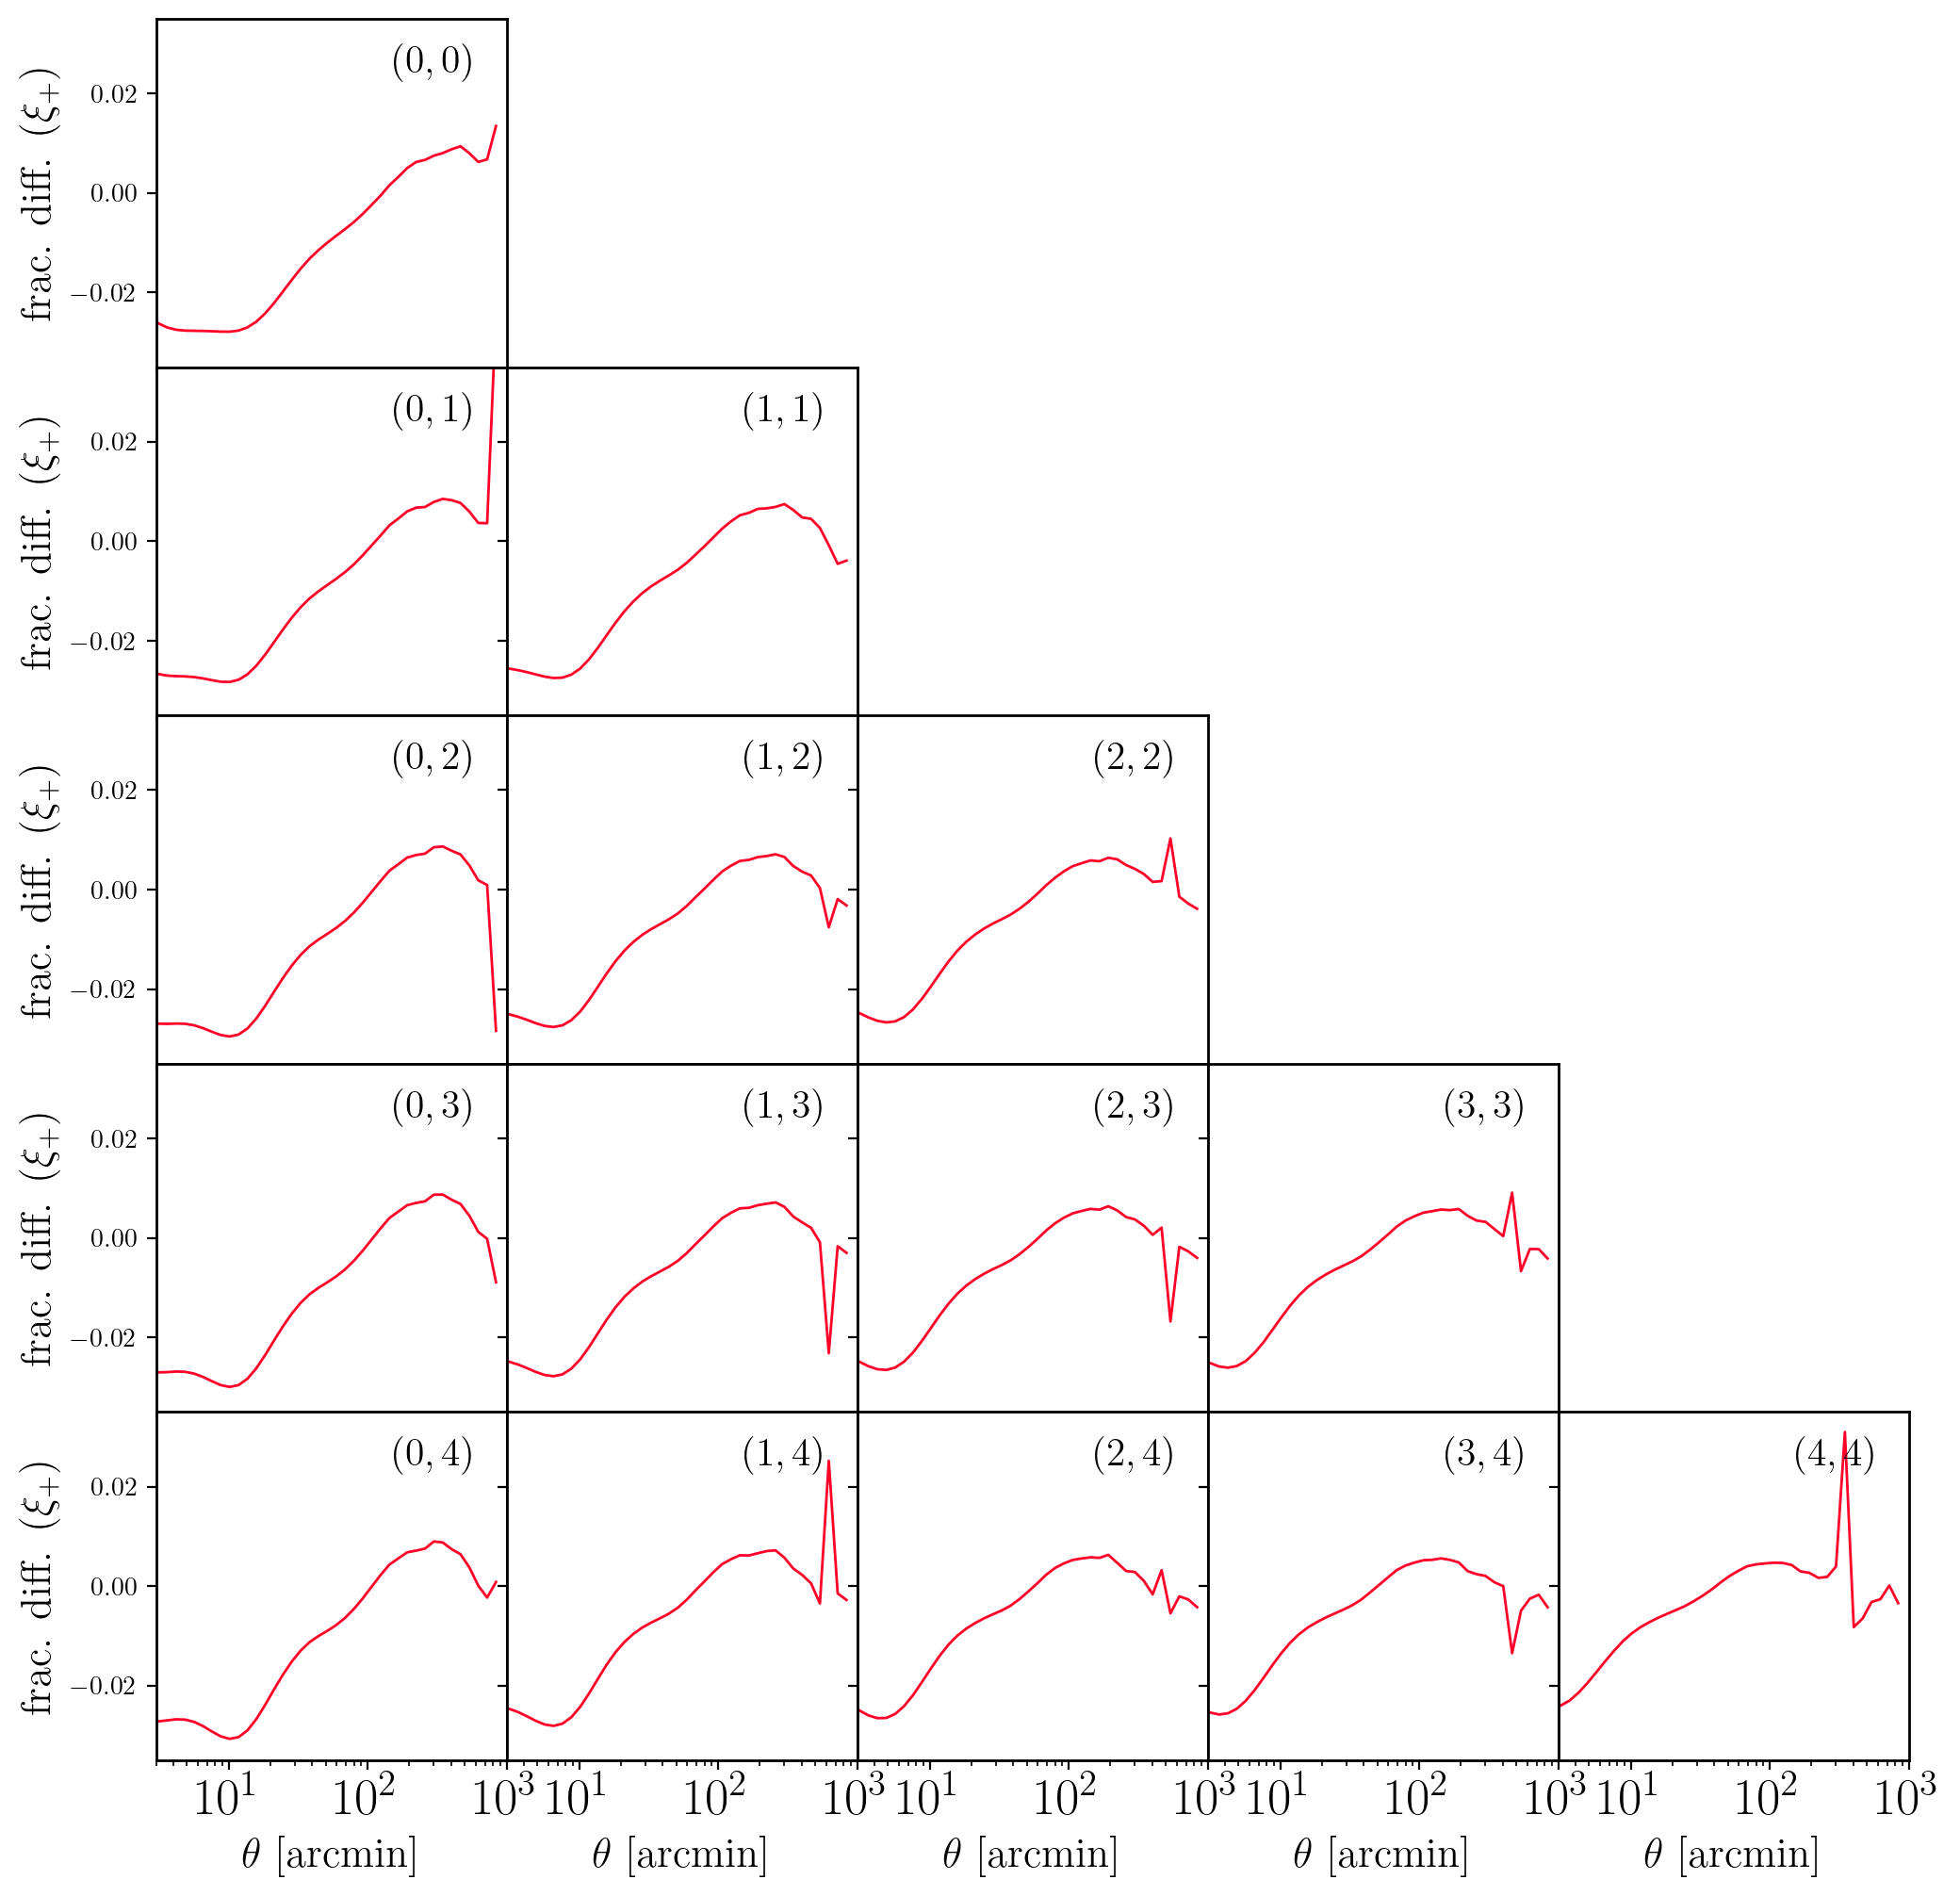

In [46]:
cnu.plot_xi(pm = 1,
            xi = xi_theta,
            xi_ref = xi_theta_ref,
            param=param,
            ylim=(0.965, 1.035),
            colorbar=None)

# Let's print LSSTY1 MASK, DATAVECTOR AND COVARIANCE MATRIX

In [29]:
# NEED TO START COSMOLIKE 

CLprobe="xi"

path= "../../external_modules/data/lsst_y1"
data_file="lsst_y1_M1_GGL0.05.dataset"

IA_model = 0
IA_redshift_evolution = 3
IA_code = 0

ini = IniFile(os.path.normpath(os.path.join(path, data_file)))

ci.initial_setup()
ci.init_accuracy_boost(1.0, int(1))
ci.init_cosmo_runmode(is_linear = False)

ci.init_redshift_distributions_from_files(
      lens_multihisto_file=ini.relativeFileName('nz_lens_file'),
      lens_ntomo=int(ini.int("lens_ntomo")), 
      source_multihisto_file=ini.relativeFileName('nz_source_file'),
      source_ntomo=int(ini.int("source_ntomo")))

ci.init_IA( ia_model = int(IA_model), 
            ia_redshift_evolution = int(IA_redshift_evolution),
            ia_code = int(IA_code))

# Init Cosmolike
ci.init_probes(possible_probes = CLprobe)

ci.init_binning(int(ini.int("n_theta")), 
                ini.float("theta_min_arcmin"), 
                ini.float("theta_max_arcmin"))

ci.init_data_real(ini.relativeFileName('cov_file'), 
                  ini.relativeFileName('mask_file'), 
                  ini.relativeFileName('data_file'))

In [30]:
ci.get_mask()

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


In [39]:
ci.get_dv_masked()

[1.32289262e-05,
 1.12448718e-05,
 9.41926456e-06,
 7.78240701e-06,
 6.35605685e-06,
 5.14854469e-06,
 4.15382148e-06,
 3.35307507e-06,
 2.71858186e-06,
 2.21867962e-06,
 1.82261123e-06,
 1.50377627e-06,
 1.24131016e-06,
 1.02019502e-06,
 8.30525548e-07,
 6.66313523e-07,
 5.24244162e-07,
 4.02569863e-07,
 3.00252793e-07,
 2.16374968e-07,
 1.49810246e-07,
 9.883602e-08,
 6.1701245e-08,
 3.63122248e-08,
 1.91953584e-08,
 8.09394874e-09,
 1.66114657e-05,
 1.40254156e-05,
 1.16674064e-05,
 9.57738457e-06,
 7.7806916e-06,
 6.28175049e-06,
 5.06423019e-06,
 4.09544521e-06,
 3.33337354e-06,
 2.73391075e-06,
 2.25679344e-06,
 1.86892428e-06,
 1.5455219e-06,
 1.2695763e-06,
 1.0304643e-06,
 8.22188044e-07,
 6.41708027e-07,
 4.87550093e-07,
 3.58773175e-07,
 2.54283964e-07,
 1.72359052e-07,
 1.10995049e-07,
 6.81799171e-08,
 3.87929669e-08,
 1.88183659e-08,
 6.55347616e-09,
 1.82420331e-05,
 1.53921258e-05,
 1.27817881e-05,
 1.04639474e-05,
 8.47340086e-06,
 6.81871241e-06,
 5.48234708e-06,
 4.4

In [40]:
ci.get_cov_masked()

array([[ 7.42940700e-12,  1.71353290e-13,  1.49035770e-13, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [ 1.71353290e-13,  4.75647120e-12,  1.35963440e-13, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [ 1.49035770e-13,  1.35963440e-13,  3.04803201e-12, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       ...,
       [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
         6.37372143e-10, -0.00000000e+00, -0.00000000e+00],
       [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
        -0.00000000e+00,  4.29793961e-10, -0.00000000e+00],
       [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
        -0.00000000e+00, -0.00000000e+00,  2.78631041e-10]])

In [41]:
ci.get_inv_cov_masked()

array([[ 1.37489923e+11, -9.26940866e+08, -1.15589371e+09, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-9.26940866e+08,  2.15971524e+11, -1.76079868e+09, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-1.15589371e+09, -1.76079868e+09,  3.39179576e+11, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00, -0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00, -0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -0.00000000e+00, -0.00000000e+00,  0.00000000e+00]])

# Let's investigate Fisher

## Fisher based on 5-stencil rule (Definitions)

In [ ]:
# The Fisher machinery is shared: the generic pieces live in
# cosmolike_core (cnu.fisher), and this project's data vector,
# fiducial vector, priors, and labels live in the wrappers module.
ini = nw.init_cosmolike(CLprobe="xi", with_data=True)
param = nw.fisher_fiducial_point()
param_names = nw.FISHER_PARAM_NAMES
param_labels = nw.FISHER_PARAM_LABELS
flat_priors = nw.FISHER_FLAT_PRIORS
gaussian_priors = nw.FISHER_GAUSSIAN_PRIORS
invcov = ci.get_inv_cov_masked()

### Fisher based on 5-stencil rule - Simple Test that the interface works

In [87]:
F = nw.get_Fisher(CV = param, h = 0.025, AccuracyBoost = 2.5)

In [88]:
print(cnu.get_FoM(0, 4, F))

169.7090304968826


Removed no burn in


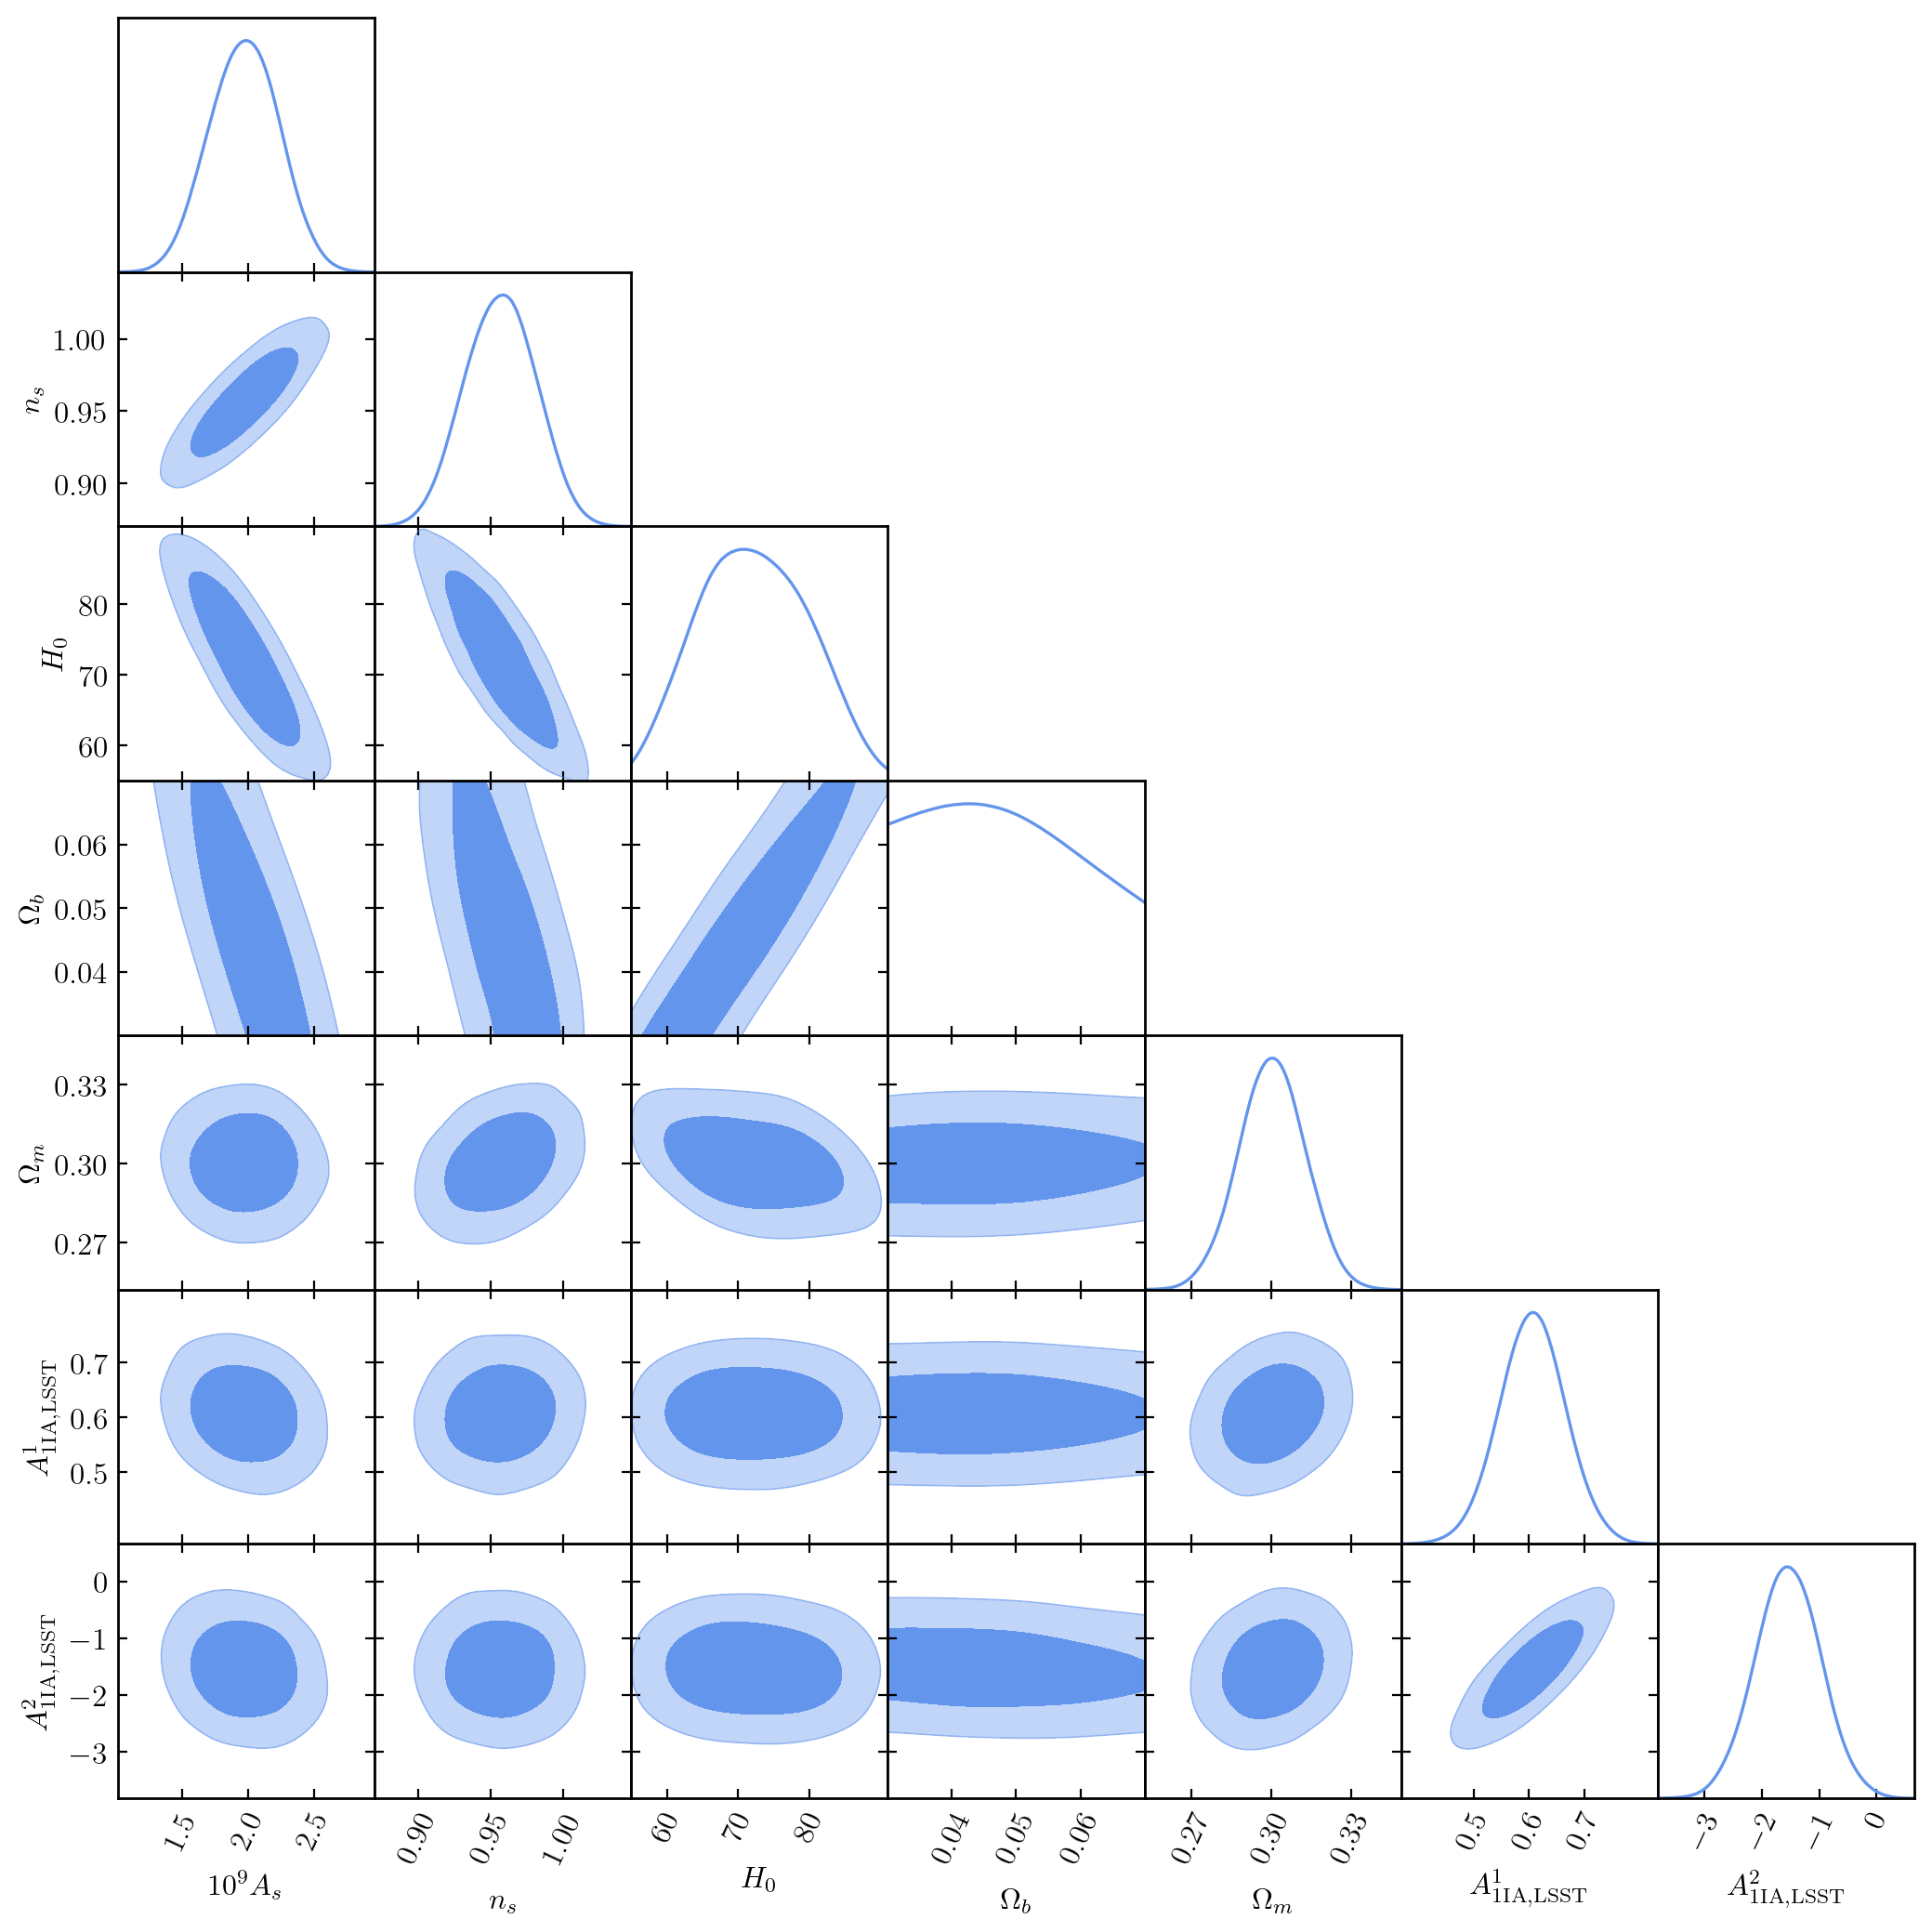

In [89]:
sel = [0, 1, 2, 3, 4, 5, 6]
g = nw.plot_Fisher(F=F,
                mu=param,
                select=sel,
                filled=True)

### Fisher based on 5-stencil rule - Test 1: Accuracy Boost

In [90]:
AB1 = np.arange(0, 5.0, 1.0)
FOM1 = []
F1 = []
for x in AB1:
    F = nw.get_Fisher(CV = param, h = 0.03, AccuracyBoost = 1 + x)
    F1.append(F)
    FOM1.append(cnu.get_FoM(0, 4, F))

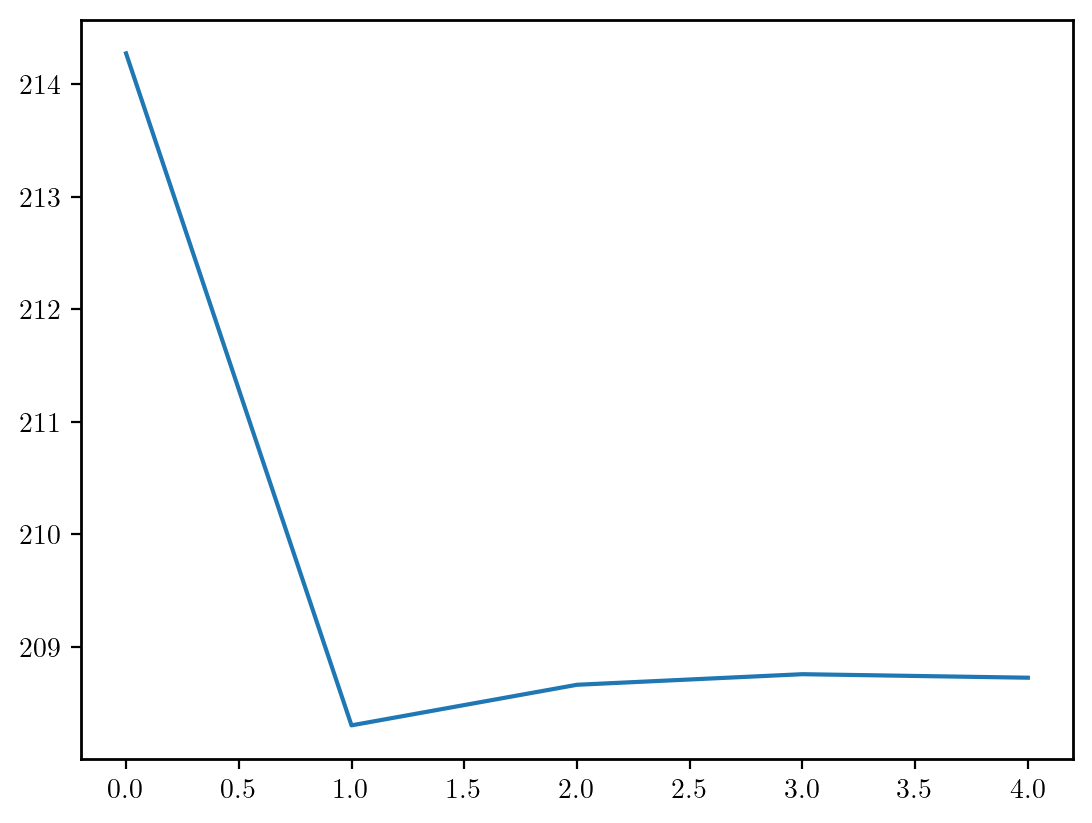

In [91]:
plt.plot(AB1, FOM1) # This show we need high accuracy boost to do Fisher

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


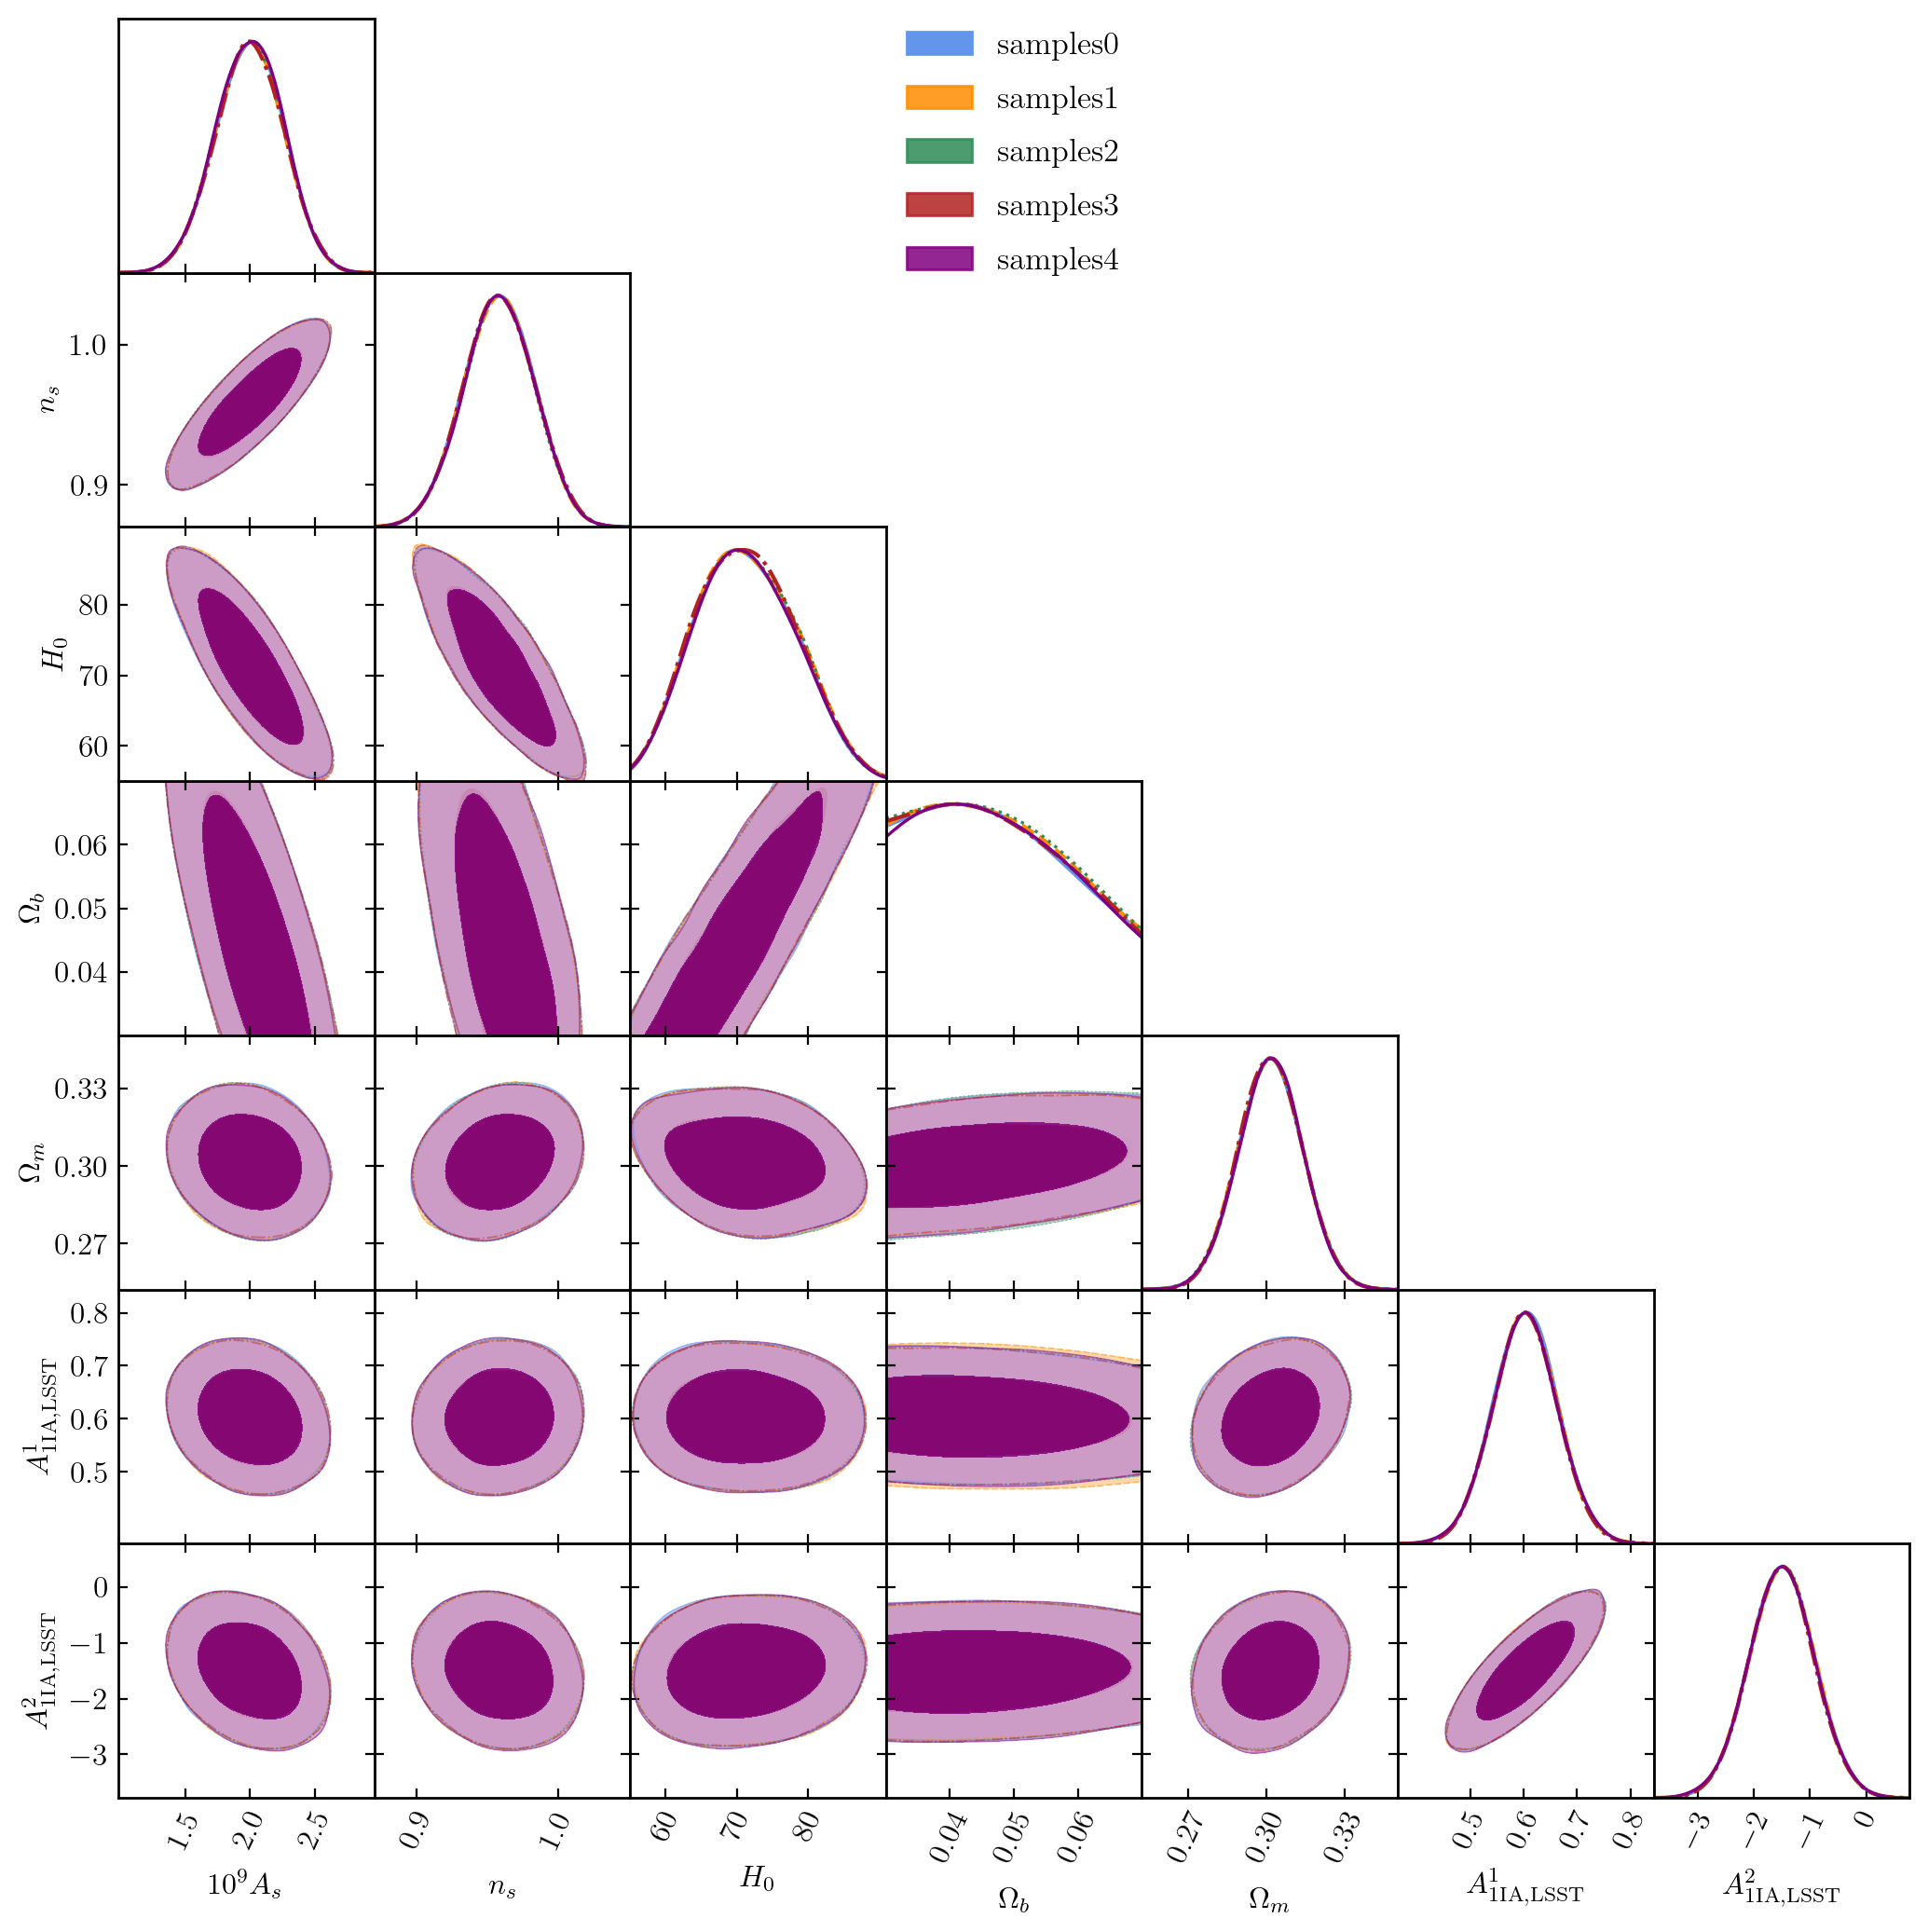

In [92]:
sel = [0, 1, 2, 3, 4, 5, 6]
g = nw.plot_Fisher(F=F1,
                mu=param,
                select=sel,
                filled=True)

### Fisher based on 5-stencil rule - Test 2: Step Size

In [96]:
hs2 = np.arange(0.02, 0.1, 0.01)
F2 = []
FOM2 = []
for x in hs2:
    F = nw.get_Fisher(CV = param, h = x, AccuracyBoost = 3.0)
    F2.append(F)
    FOM2.append(cnu.get_FoM(0, 4, F))

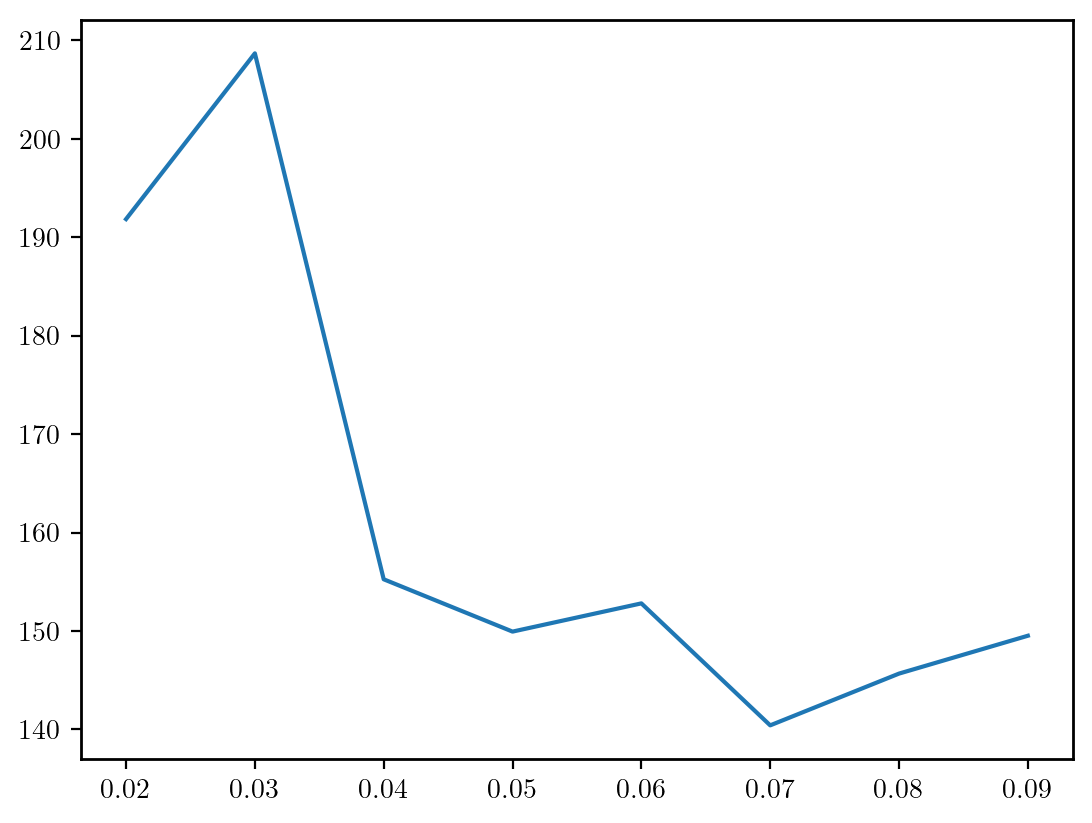

In [97]:
plt.plot(hs2, FOM2) 

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


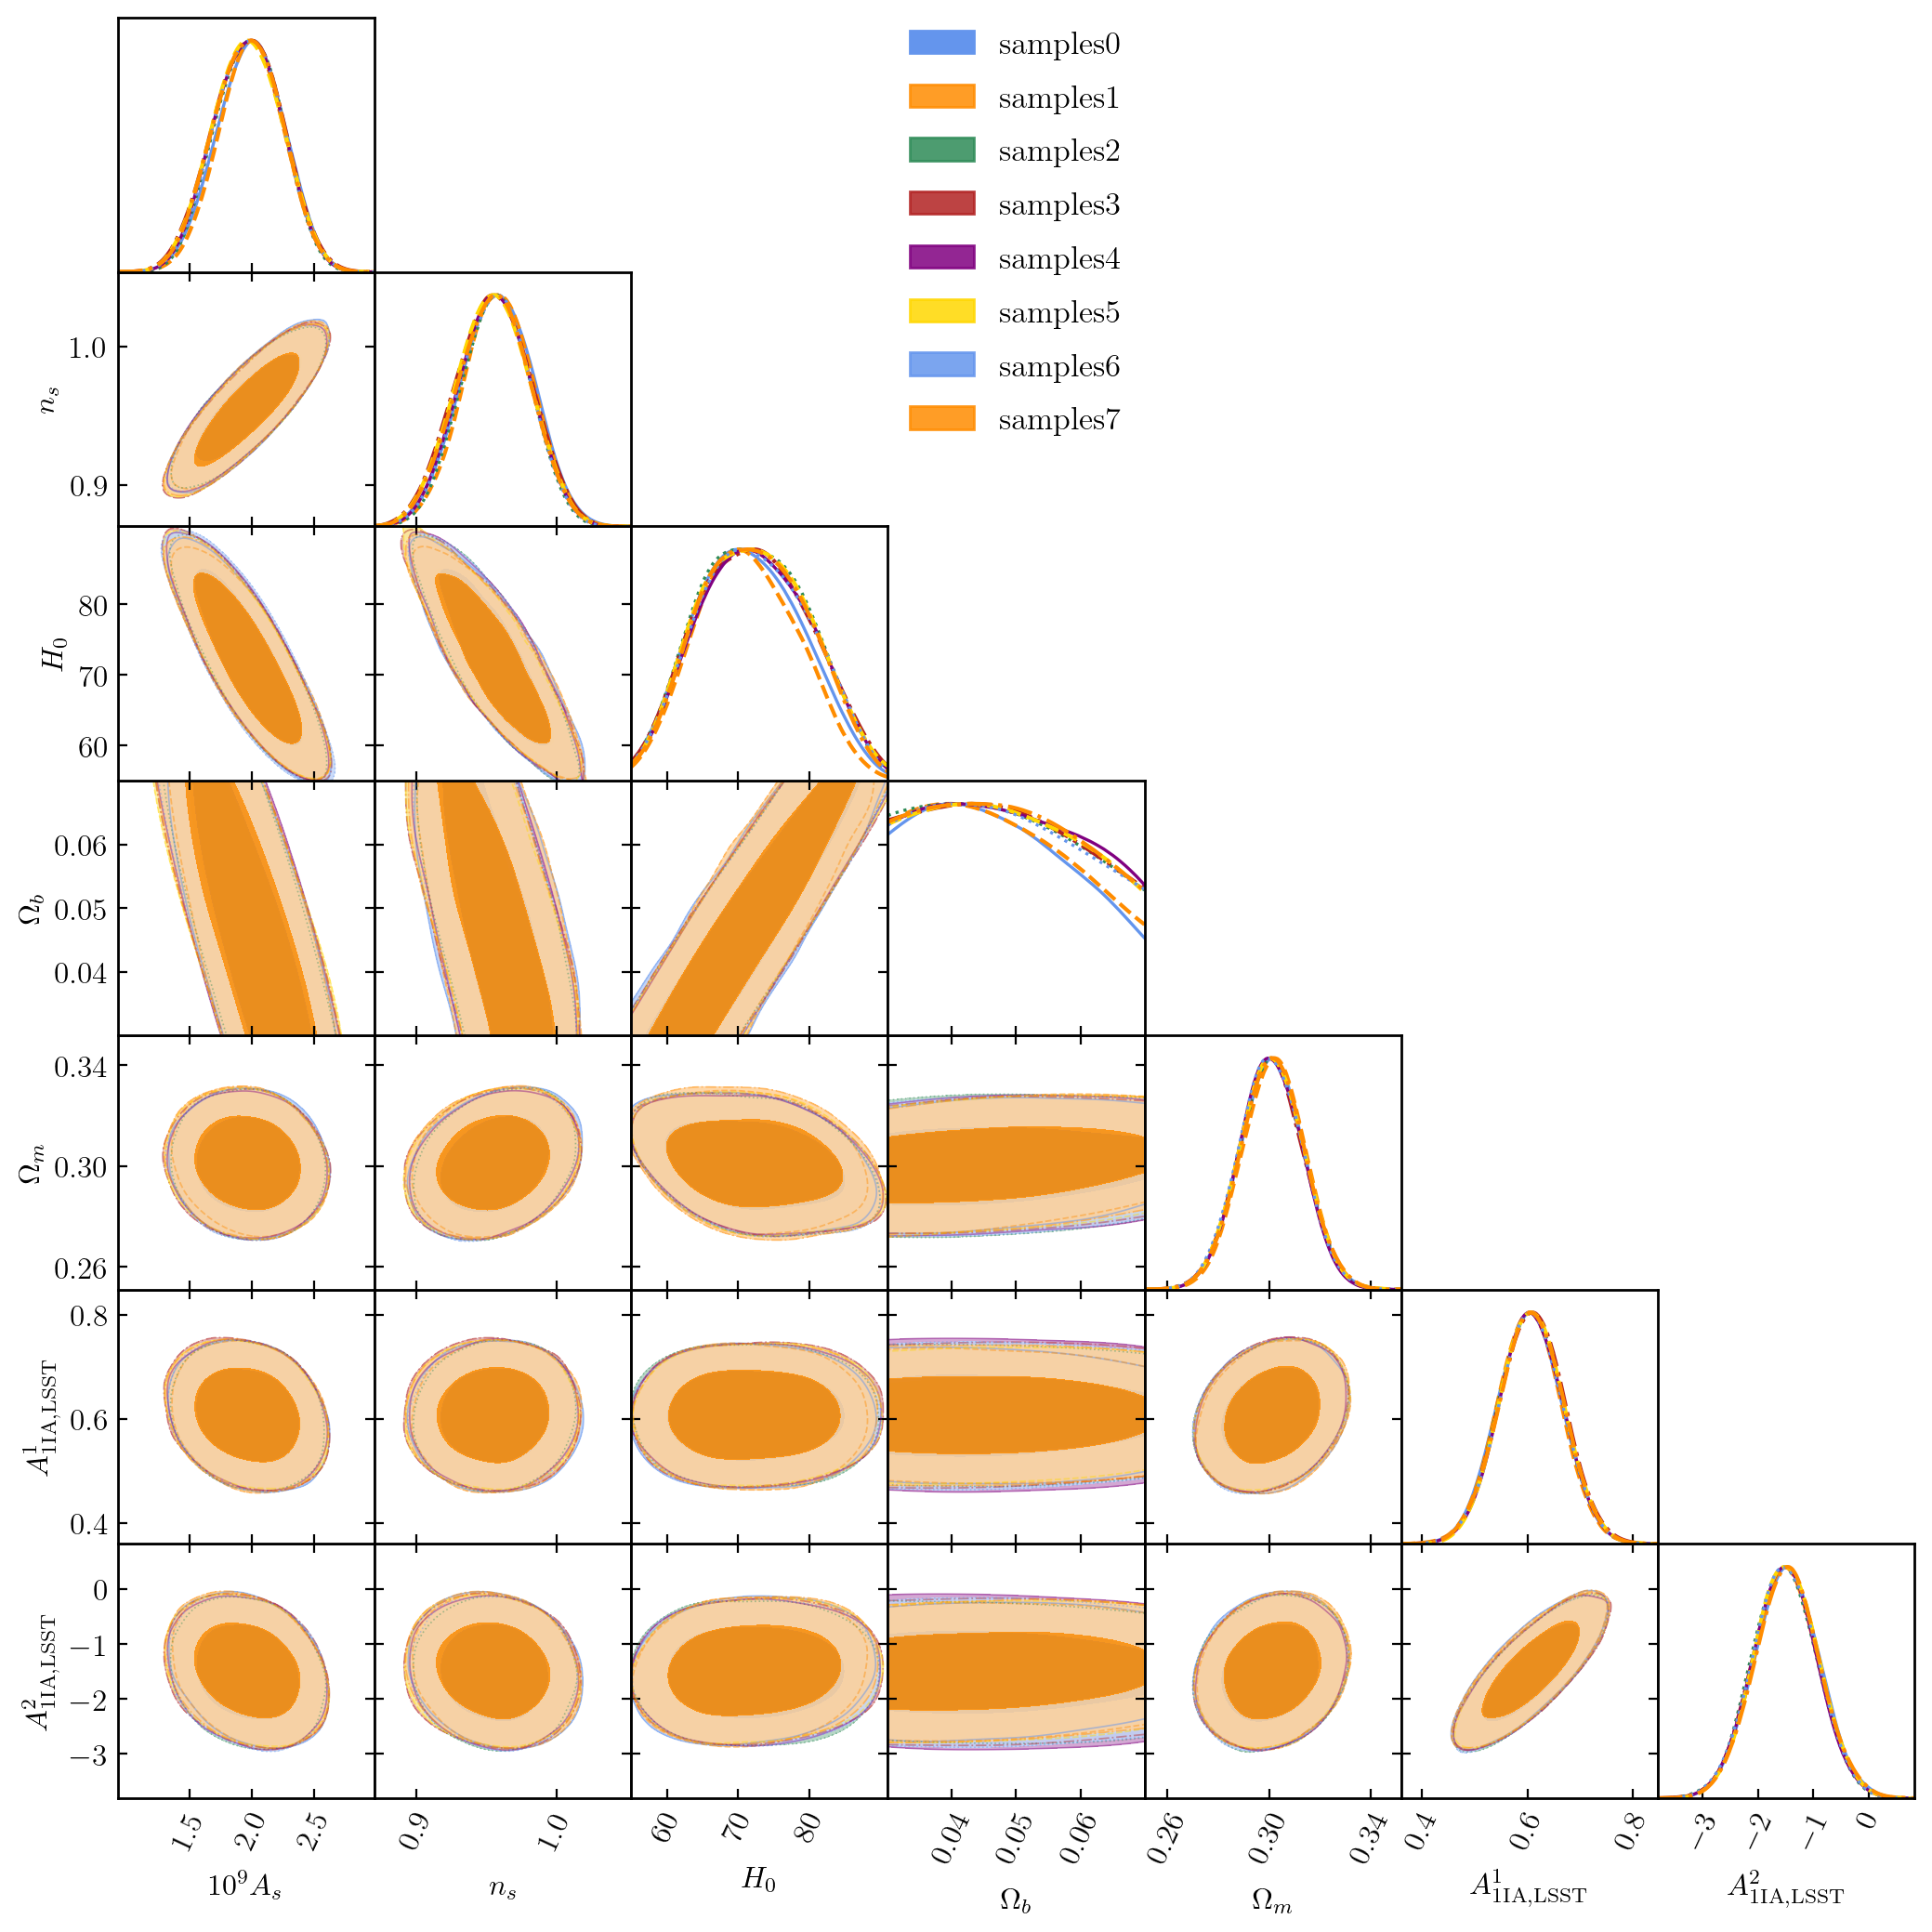

In [98]:
sel = [0, 1, 2, 3, 4, 5, 6]
g = nw.plot_Fisher(F=F2,
                mu=param,
                select=sel,
                filled=True)

## Question: 5-stencil rule vs DerivativeKit polynomial fit?

In [ ]:
# get_ddv_dkit and get_Fisher2 live in this project's interface/
# (cosmolike_lsst_y1_notebook_wrappers, imported above as nw),
# shared by every notebook of this project; call as
# nw.get_ddv_dkit, nw.get_Fisher2.

In [100]:
AB5 = np.arange(0, 5.0, 1.0)
FOM5 = []
F5 = []
for x in AB5:
    F = nw.get_Fisher2(CV = param, AccuracyBoost = 1 + x)
    F5.append(F)
    FOM5.append(cnu.get_FoM(0, 4, F))

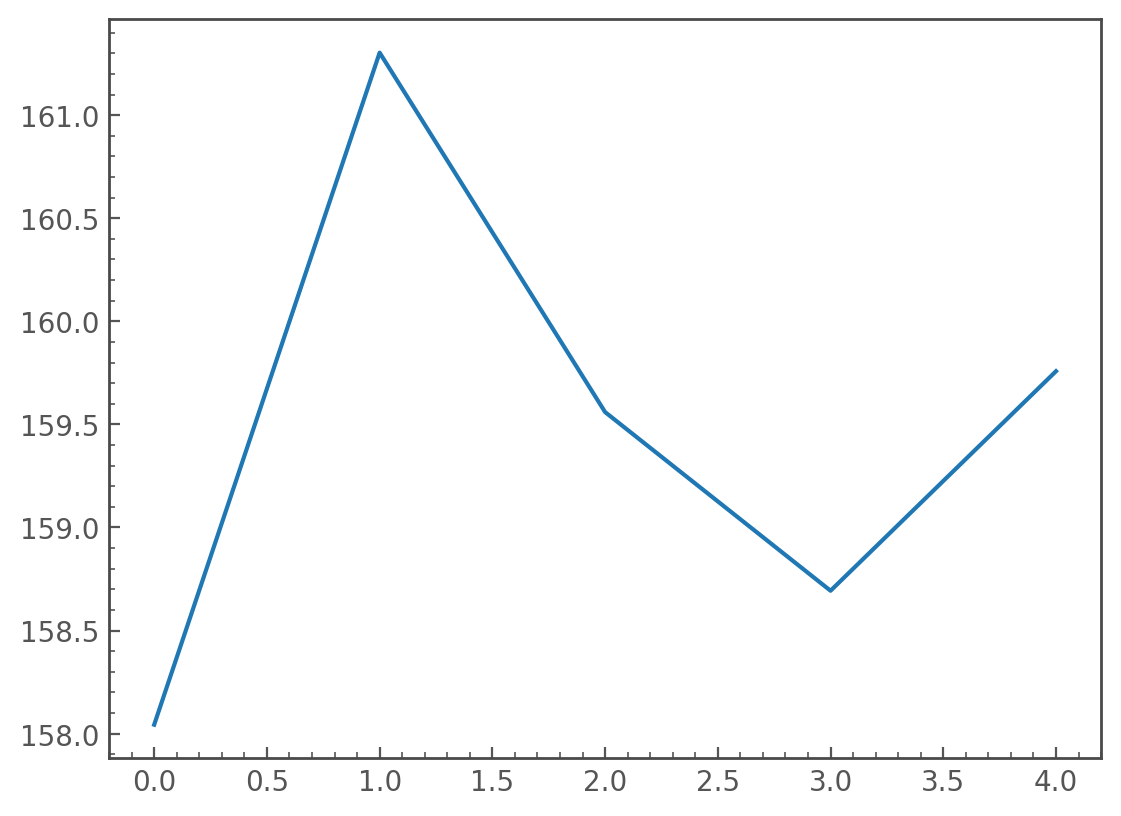

In [101]:
plt.plot(AB5, FOM5) # much more stable (in terms of precision) - it also shows AccuracyBoost = 3 (2 in the x-axis) is the safest choice

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


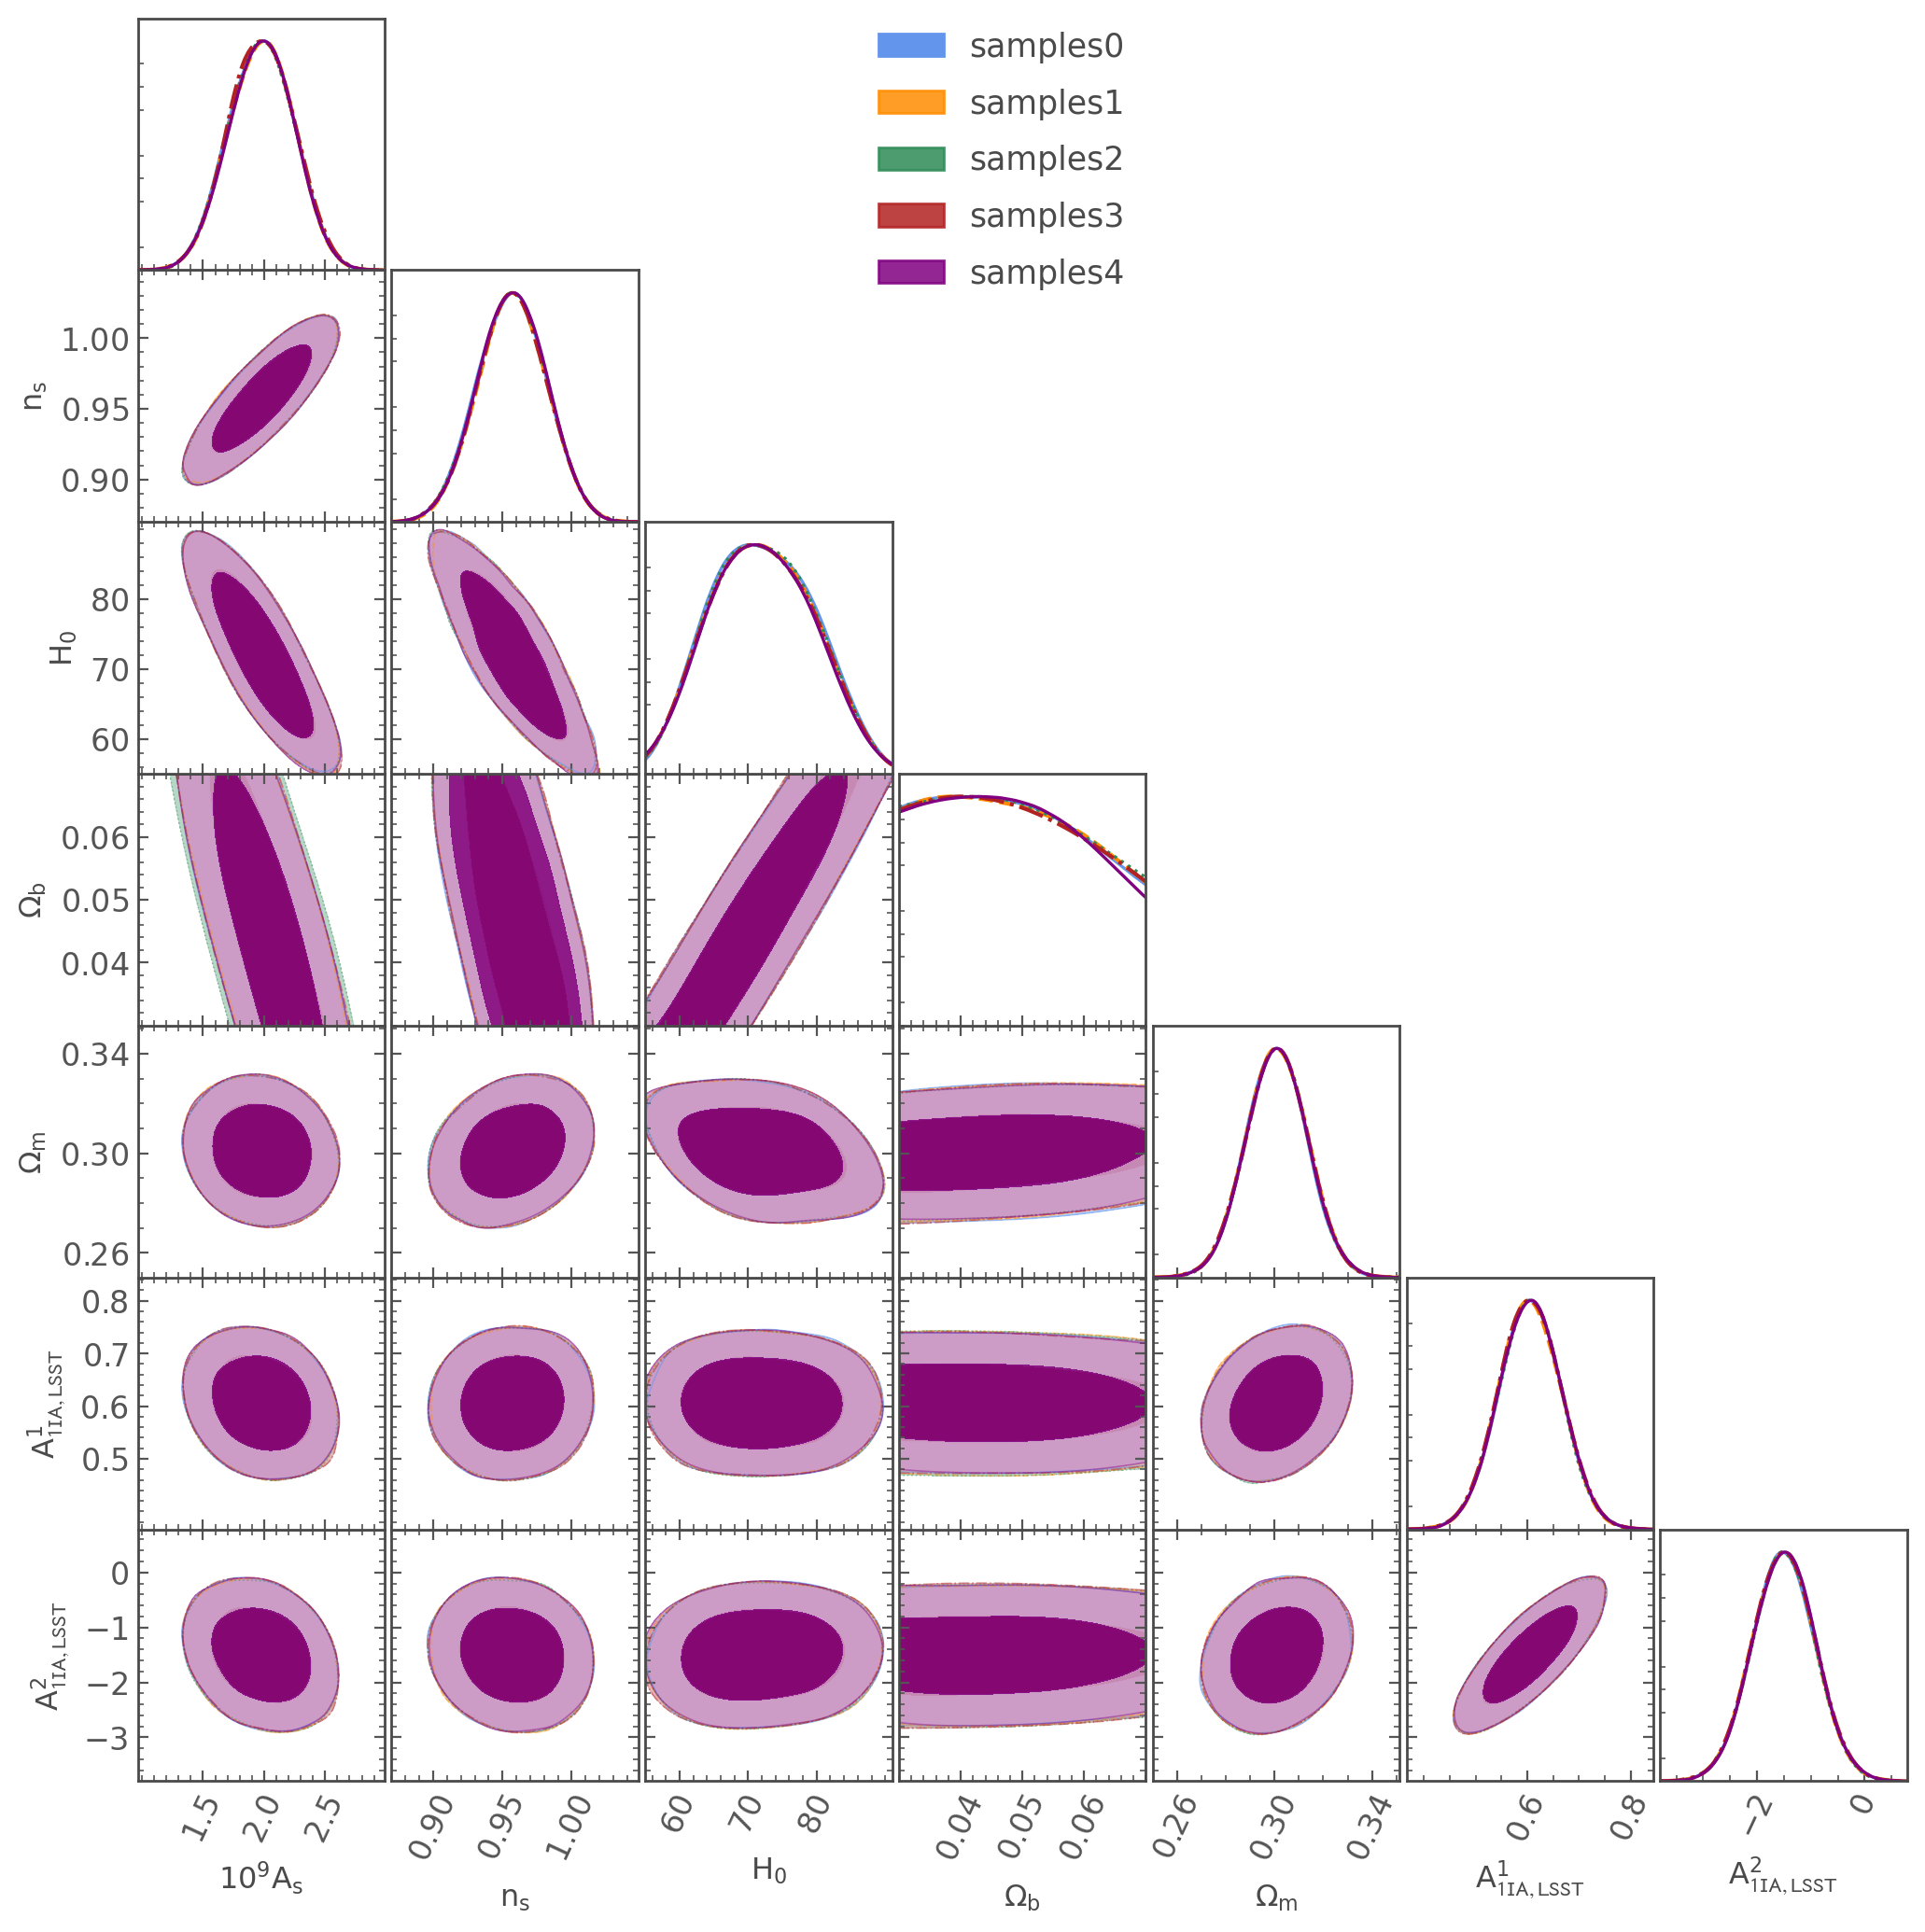

In [102]:
sel = [0, 1, 2, 3, 4, 5, 6]
g = nw.plot_Fisher(F=F5,
                mu=param,
                select=sel,
                filled=True)